# Market Sentiment Predictor

Geovanni Jones, Josh Previte, Casey Barrasso

The goal of this project is to predict the directional price movement of a specific stock using both historical price data and news information. Two separate models will predict price movements based on historical data and analyze news sentiment.

In [4]:
# This is used to generate the requirements.txt file for the project.
#!pip freeze > requirements.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
import torch
import gc
import joblib


#from pandas.errors import SettingWithCopyWarning

from collections import Counter

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

#!pip install imblearn
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression as LR
from sklearn.svm import SVC
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.utils import resample

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score

from scipy.sparse import hstack, csr_matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report as CR
#from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, f1_score

#install transformers if not already done
#!pip install transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import warnings
warnings.filterwarnings("ignore")

#!pip install shap
import shap


In [2]:
os.getcwd()

'/home/jupyter-jonesaop/market-sentiment-predictor/notebooks'

In [3]:
#suppress pesky filter warnings
#warnings.filterwarnings("ignore", category=SettingWithCopyWarning)

# Week 2 - Data Ingestion

There are two main datasets to this project. The first is a dataset containing news article content including titles, content, and sentiment scores from various news sources around the AAPL stock. The second dataset (introduced later in the notebook) contains a time series of AAPL stock prices. The final dataset will combine the two datasets on date.

## Sentiment Dataset

In [4]:
#Github didn't allow us to upload a file more than 25MB. This is combining all files into one file
def sentiment_data_creation():
    raw_data_1 = pd.read_csv('../data/apple_news_data_1.csv', encoding='latin-1')
    raw_data_2 = pd.read_csv('../data/apple_news_data_2.csv', encoding='latin-1')
    raw_data_3 = pd.read_csv('../data/apple_news_data_3.csv', encoding='latin-1')
    raw_data_4 = pd.read_csv('../data/apple_news_data_4.csv', encoding='latin-1')
    raw_data_5 = pd.read_csv('../data/apple_news_data_5.csv', encoding='latin-1')

    raw_data = pd.concat([raw_data_1, raw_data_2, raw_data_3, raw_data_4, raw_data_5])[['date', 'title', 'content', 'link', 'symbols', 'tags', 'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos']]
    return raw_data

raw_data = sentiment_data_creation()

In [5]:
#view a small subsection of the data to ensure formatting looks correct
raw_data.head(10)

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2021-04-30T21:38:00+00:00,Techâs Big Five Had Fantastic Pandemics. Her...,"Alphabet, Amazon.com, Apple, Facebook, and Mic...",https://finance.yahoo.com/m/bbe3f7c9-c7af-3c9f...,"AAPL.US, AAPL34.SA, AMZN.US, FB.US, GOOGL.US","AMAZON, APPLE, FACEBOOK, HARLEY FINKELSTEIN, M...",0.395,0,0.871,0.129
1,2021-04-30T20:41:52+00:00,Valuation Remains a Concern for Churchill Capi...,Churchill Capital IV (NYSE:CCIV) stock has gra...,https://finance.yahoo.com/news/valuation-remai...,"AAPL.US, CCIV-UN.US, CCIV.US","BUSINESS COMBINATION, CCIV, CHURCHILL CAPITAL ...",0.998,0.023,0.85,0.127
2,2021-04-30T20:18:00+00:00,Big techâs trillion-dollar pandemic year may...,This week concludes the first quarter earnings...,https://finance.yahoo.com/m/6e441d74-37c1-3642...,"AAPL.US, AAPL34.SA, AMZN.US, MSFT.US","AMAZON, APPLE INC, BIG TECH, MARKET CAPITALIZA...",0,0,1,0
3,2021-04-30T19:32:30+00:00,What Appleâs blowout earnings means for Berk...,"Krish Sankar, Managing Dir. & Cowen Senior Res...",https://finance.yahoo.com/video/apple-blowout-...,"AAPL.US, AAPL34.SA, BRK-A.US, BRK-B.US, DJI.IN...","ALEXIS CHRISTOFOROUS, BERKSHIRE HATHAWAY, COWE...",0,0,1,0
4,2021-04-30T18:49:00+00:00,EU Agrees With Spotify: Apple Is Abusing Its A...,The EU's European Commission just released pre...,https://finance.yahoo.com/m/07524444-63a7-34aa...,"AAPL.US, AAPL34.SA, SPOT.US","APP STORE, APPLE, EUROPEAN COMMISSION, MUSIC S...",-0.71,0.093,0.885,0.022
5,2021-04-30T18:30:06+00:00,ETFs to Stack as Reopening Poses No Hindrance ...,The tech-heavyÂ Nasdaq Composite Index was a s...,https://finance.yahoo.com/news/etfs-stack-reop...,"AAPL.US, AAPL34.SA, COMP.US, FB.US, GOOGL.US, ...","APPLE, CONSENSUS ESTIMATE, EARNINGS PER SHARE,...",0.999,0.027,0.826,0.148
6,2021-04-30T18:19:10+00:00,Big Tech Stocks Flash Red Flag to Regulators A...,"If âBig Techâ was a gamefish, like Faceboo...",https://finance.yahoo.com/news/big-tech-stocks...,"AAPL.US, CRM.US, FB.US, GME.US, GOOGL.US, MSFT...","BITCOIN, DIGITAL TRANSFORMATION, FACEBOOK, MIC...",0.999,0.026,0.861,0.113
7,2021-04-30T18:13:06+00:00,"Top Stock Reports for Apple, Alphabet &amp; Bl...","Friday, April 30, 2021\n\nThe Zacks Research D...",https://finance.yahoo.com/news/top-stock-repor...,"AAPL.US, AAPL34.SA, BLK.US, F.US, GOOGL.US, ZT...","ALPHABET, APPLE, APPLE WATCH, BLACKROCK, RESEA...",0.999,0.042,0.775,0.183
8,2021-04-30T17:54:31+00:00,Why Stem Stock Looks Very Attractive Following...,"Not infrequently, Wall Street focuses excessiv...",https://finance.yahoo.com/news/why-stem-stock-...,"AAPL.US, AMZN.US, BX.US, FSLR.US, GE.US, GEOO3...","CLEAN-ENERGY, STEM STOCK",0.999,0.015,0.83,0.154
9,2021-04-30T17:34:59+00:00,âTechnology is the largest single growth tre...,"Keith Fitz-Gerald, Fitz-Gerald Group Chief Inv...",https://finance.yahoo.com/video/technology-lar...,"AAPL.US, AAPL34.SA, AMZN.US, DJI.INDX, FB.US, ...","ALEXIS CHRISTOFOROUS, KEITH FITZ-GERALD, SIBIL...",0,0,1,0


In [6]:
# Sort raw_data by date column from earliest to latest
raw_data = raw_data.sort_values('date', ascending=True).reset_index(drop=True)

raw_data.head(10)
#raw_data.tail(10)

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,And I can tell you now that team presents to ...,our Board and us as a company.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,And but their objective was in a very lower f...,they had an initial spend goal which were sig...,and the results were so great that they were ...,you know,doubling came from someplace else,but I was happy to see it.,NaN,NaN,NaN,NaN
2,And by midyear,we're supposed to be fully ramped,then we'll reevaluate. We'll just see where w...,the expectation is we have what we need.,NaN,NaN,NaN,NaN,NaN,NaN
3,And like I said,the only other call-out I would give is that ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,And part of that will be growth of e-commerce...,it's a really high value demand and helps us ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,And so we can get those leading indicators an...,to the extent that we've seen international c...,we're going to look at that and invest in tha...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,And so we're just making sure that we're doin...,very closely. So we're on point.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,And so when those renewals come up,we're certainly showing the advantage of not ...,but then an Apple-led and Apple-focused ecosy...,is resonating with our customer base. So we c...,we were even just as,if not even more optimistic about it.,NaN,NaN,NaN,NaN
8,And then I guess to wrap it up would be secur...,every device can have one device management p...,that gives us a good opportunity and really a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,And then also,I also wanted to ask about retention rates,which you mentioned benefit from training you...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#check how many NA values there are. We care most about sentiment, date, and content columns
raw_data.isna().sum().sort_values(ascending=False)

tags                  17790
sentiment_pos          5853
sentiment_neu          5812
sentiment_neg          5767
sentiment_polarity     5721
symbols                5539
link                   5340
content                4901
title                  4255
date                   2808
dtype: int64

In [8]:
#Drop Clumns we won't be focusing on (link and tags)
raw_data = raw_data.drop(columns=['link', 'tags'])

In [9]:
# force sentiment scores to be a numerical value, NA if not 
for col in ['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# extract valid calendar dates only (ignore time + BST noise)
raw_data['date'] = pd.to_datetime(
    raw_data['date'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
    errors='coerce'
) #This section of the code was inputed to handle warnings from pandas that could lead to future breakage of the code.

# convert content to string
raw_data['content'] = raw_data['content'].astype('str')


In [10]:
# Setting "date" column to datetime format
raw_data['date'] = pd.to_datetime(raw_data['date'])

print(raw_data.shape)

#Data range for raw_data
print(f"Date range for raw_data: {raw_data['date'].min()} to {raw_data['date'].max()}")

(35604, 8)
Date range for raw_data: 2016-02-19 00:00:00 to 2024-11-27 00:00:00


In [11]:
#this data is messy, drop observations that have NAs in critical columns
raw_data = raw_data.dropna(subset=['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity','content','date'])

#print out the data type of each column to ensure conversions from above worked
for col in raw_data.columns:
    print(f'Column: {col} , Data Type: {raw_data[col].dtype}')

Column: date , Data Type: datetime64[ns]
Column: title , Data Type: object
Column: content , Data Type: object
Column: symbols , Data Type: object
Column: sentiment_polarity , Data Type: float64
Column: sentiment_neg , Data Type: float64
Column: sentiment_neu , Data Type: float64
Column: sentiment_pos , Data Type: float64


The "content" column will be the predictor variable in the first model, and the string will be transformed into a numerical matrix using feature engineering methods such as TF-IDF. The "snetiment polarity" variable will be the target variable. The goal of the first model will be to predict the sentiment polarity of a news article given its content.

In [12]:
print(raw_data.shape)

(29700, 8)


In [13]:
# Dropping rows before January 1, 2018 and after October 31, 2024
raw_data = raw_data[(raw_data['date'] >= '2018-01-01') & (raw_data['date'] <= '2024-10-31')]

print(raw_data.shape)

#Data range for raw_data
print(f"Date range for raw_data: {raw_data['date'].min()} to {raw_data['date'].max()}")

(29635, 8)
Date range for raw_data: 2018-01-31 00:00:00 to 2024-10-31 00:00:00


This dataset has 29,635 rows and 9 columns (plus the net sentiment score column created by us)

## Price Timeseries Dataset

In [14]:
ts_data = pd.read_csv('../data/AAPL Stock Data.csv')

In [15]:
ts_data.head(10)

,Dates,AAPL Share Price
0,Jan-03-2005,1.13
1,Jan-04-2005,1.14
2,Jan-05-2005,1.15
3,Jan-06-2005,1.15
4,Jan-07-2005,1.24
5,Jan-10-2005,1.23
6,Jan-11-2005,1.15
7,Jan-12-2005,1.17
8,Jan-13-2005,1.25
9,Jan-14-2005,1.25


In [16]:
#check how many NA values there are
ts_data.isna().sum().sort_values(ascending=False)

Dates               0
AAPL Share Price    0
dtype: int64

In [17]:
#Convert values to the expected formatting
ts_data['Dates'] = pd.to_datetime(ts_data['Dates']).dt.date
ts_data['AAPL Share Price'] = ts_data['AAPL Share Price'].astype('float')

In [18]:
for col in ts_data.columns:
    print(f'Column: {col} , Data Type: {type(ts_data[col][0])}')

Column: Dates , Data Type: <class 'datetime.date'>
Column: AAPL Share Price , Data Type: <class 'numpy.float64'>


In [19]:
print(ts_data.shape)

(5298, 2)


In [20]:
# Setting "Dates" column to datetime format
ts_data['Dates'] = pd.to_datetime(ts_data['Dates'])

# Dropping rows before January 1, 2018 and after October 31, 2024
ts_data = ts_data[(ts_data['Dates'] >= '2018-01-01') & (ts_data['Dates'] <= '2024-10-31')]

print(ts_data.shape)
print(f"Date range: {ts_data['Dates'].min()} to {ts_data['Dates'].max()}")

(1720, 2)
Date range: 2018-01-02 00:00:00 to 2024-10-31 00:00:00


There are 1,720 rows in this dataset and two columns (date and price).

# Week 3 - Split and EDA

This week, we will focus on splitting the data into a train, validation, and test set and performing exploratory data analysis (EDA).

## Split Sentiment Dataset

In [21]:

raw_data = raw_data.sort_values("date").reset_index(drop=True)

raw_train = raw_data[(raw_data["date"] >= "2018-01-01") & (raw_data["date"] <= "2022-10-31")]
raw_val   = raw_data[(raw_data["date"] >= "2022-11-01") & (raw_data["date"] <= "2023-10-31")]
raw_test  = raw_data[(raw_data["date"] >= "2023-11-01") & (raw_data["date"] <= "2024-10-31")]

print(raw_train.shape)
print(raw_val.shape)
print(raw_test.shape)

raw_train.head(10)

(15474, 8)
(7598, 8)
(6563, 8)


,date,title,content,symbols,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2018-01-31,Investor Expectations to Drive Momentum within...,"NEW YORK, Jan. 31, 2018 (GLOBE NEWSWIRE) -- ...","AAPL.US, AVHI.US, FARM.US, GM.US, SGRY.US",0.995,0.009,0.937,0.054
1,2018-03-16,Top 100 Reputable Companies Around the Globe A...,"Boston, MA, March 16, 2018 (GLOBE NEWSWIRE) ...","AAPL.US, AMZN.US, BA.US, BUD.US, CAJ.US, CAT.U...",0.991,0.011,0.917,0.072
2,2018-03-27,Universal Display Corporation Stock Is Way Und...,"Since topping out in January, shares of Univer...","AAPL.US, OLED.US",-0.244,0.134,0.764,0.101
3,2018-04-16,Detailed Research: Economic Perspectives on Ge...,"NEW YORK, April 16, 2018 (GLOBE NEWSWIRE) --...","AAPL.US, FB.US, GD.US, GRMN.US, HD.US, WBA.US",0.997,0.008,0.930,0.062
4,2018-06-22,"Apple iPhone Spared Tariffs, But Could Face Ch...",In an escalating trade war between China and t...,"AAPL.US, HNHPF.US",-0.807,0.138,0.862,0.000
5,2018-10-23,Report: Exploring Fundamental Drivers Behind T...,"NEW YORK, Oct. 23, 2018 (GLOBE NEWSWIRE) -- ...","AAPL.US, BTX.US, CTLT.US, HD.US, PDLI.US, QURE.US",0.995,0.008,0.941,0.051
6,2018-11-30,"New Research Coverage Highlights Omeros, Apple...","NEW YORK, Nov. 30, 2018 (GLOBE NEWSWIRE) -- ...","AAPL.US, BIO.US, COT.US, DAR.US, OMER.US, OR.US",0.998,0.009,0.925,0.066
7,2019-01-03,"Apple, AAPL Investment Losses Alert: Bernstein...","NEW YORK, Jan. 02, 2019 (GLOBE NEWSWIRE) -- ...",AAPL.US,0.992,0.038,0.816,0.147
8,2019-01-03,"SHAREHOLDER ALERT: Bronstein, Gewirtz & Grossm...","NEW YORK, Jan. 03, 2019 (GLOBE NEWSWIRE) -- ...",AAPL.US,0.967,0.050,0.839,0.111
9,2019-02-22,"Factors of Influence in 2019, Key Indicators a...","NEW YORK, Feb. 22, 2019 (GLOBE NEWSWIRE) -- ...","AAPL.US, CBAY.US, FTK.US, GVA.US, IMGN.US, UAL.US",0.997,0.009,0.928,0.064


## EDA Sentiment Dataset

Visual Analysis:

- Sentiment polarity distribution histogram
- Sentiment scores comparison (neg/neu/pos) boxplot
- Articles count over time (monthly trend)
- Average sentiment polarity over time with zero baseline

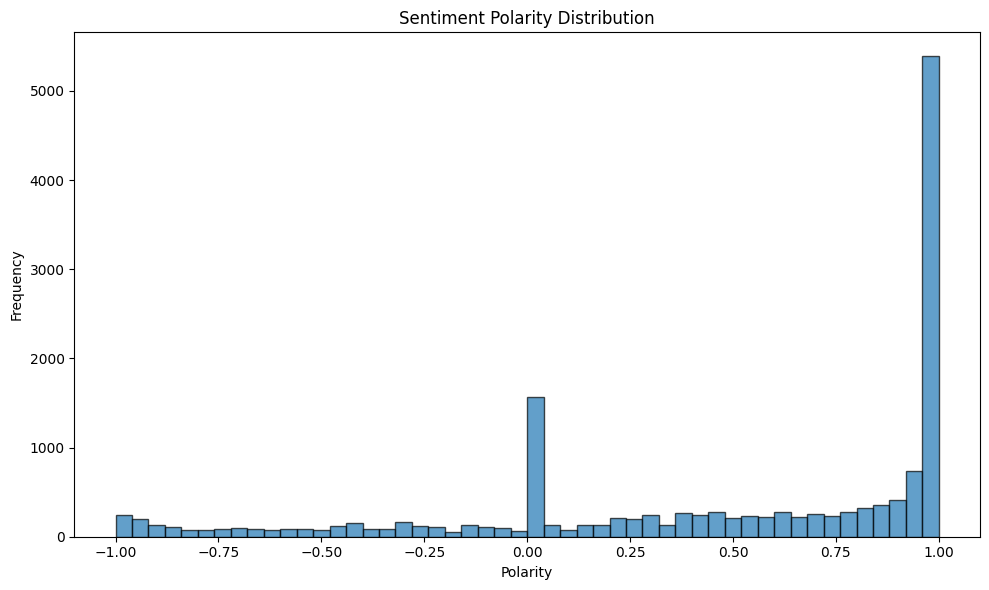

In [22]:
# Sentiment polarity distribution
plt.figure(figsize=(10, 6))
plt.hist(raw_train['sentiment_polarity'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

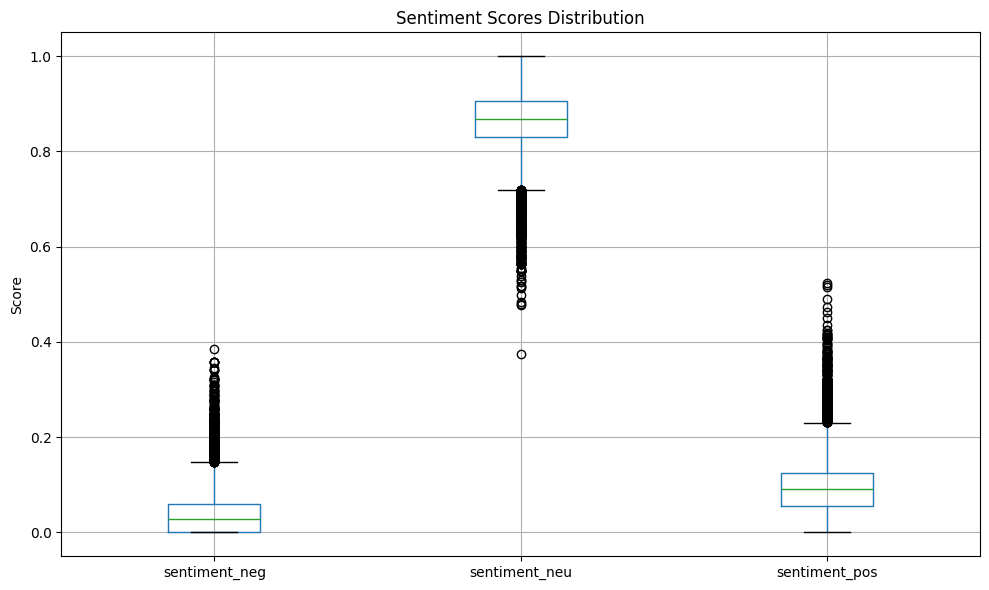

In [23]:
# Sentiment scores comparison
plt.figure(figsize=(10, 6))
sentiment_cols = ['sentiment_neg', 'sentiment_neu', 'sentiment_pos']
raw_train[sentiment_cols].boxplot()
plt.title('Sentiment Scores Distribution')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

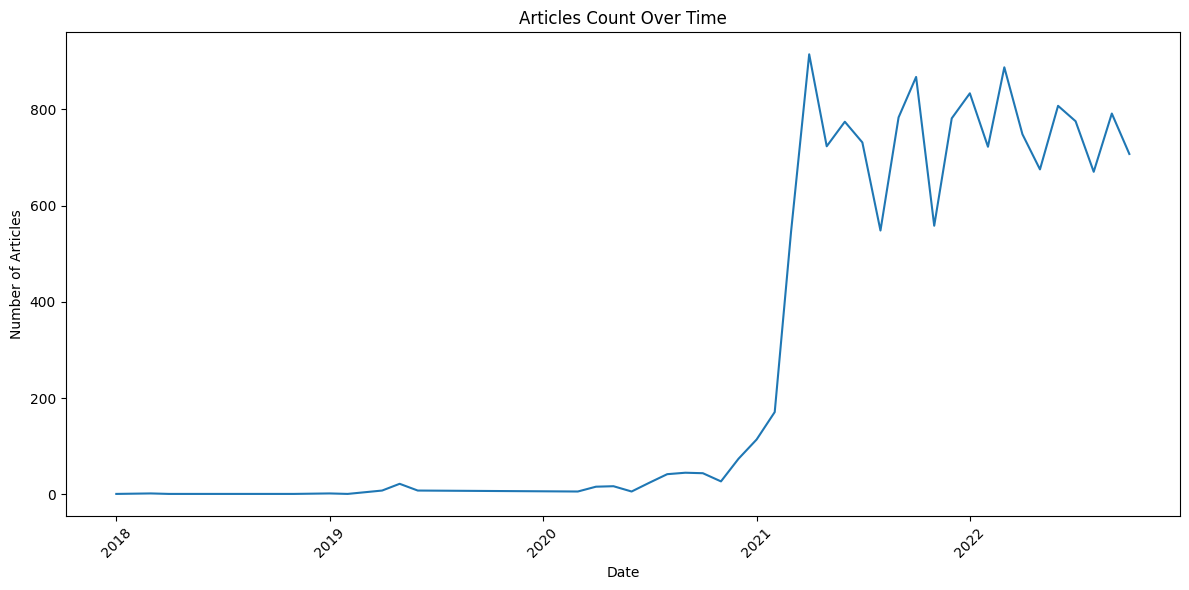

In [24]:
# Articles per date
raw_train['date'] = pd.to_datetime(raw_train['date'])
articles_per_date = raw_train.groupby(raw_train['date'].dt.to_period('M')).size()
plt.figure(figsize=(12, 6))
plt.plot(articles_per_date.index.to_timestamp(), articles_per_date.values)
plt.title('Articles Count Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

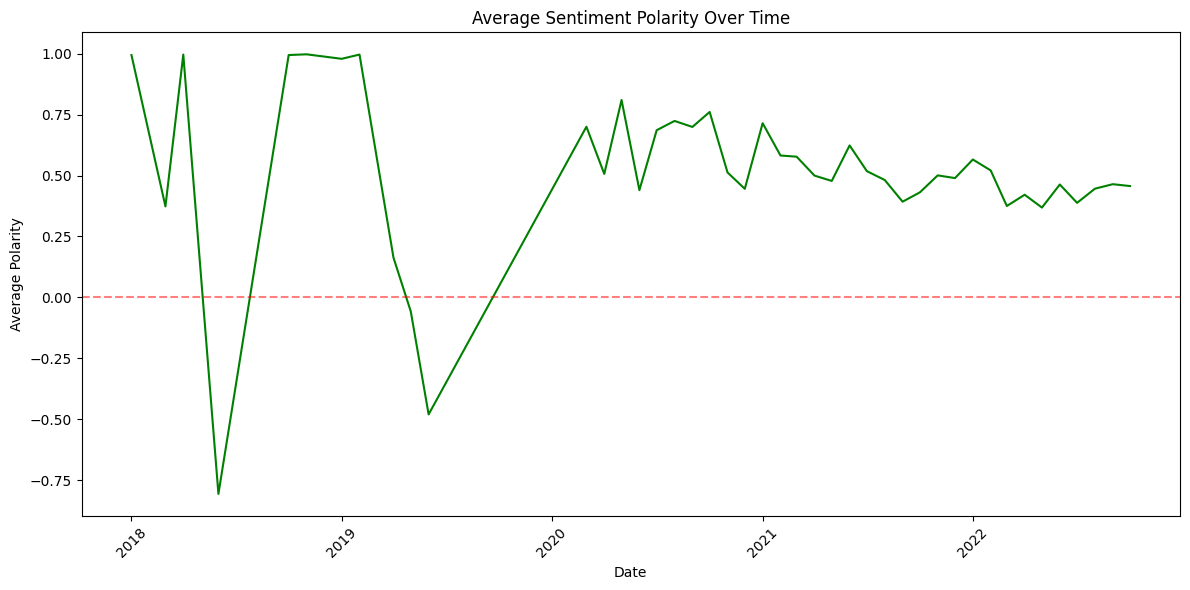

In [25]:
# Average sentiment over time
avg_sentiment = raw_train.groupby(raw_train['date'].dt.to_period('M'))['sentiment_polarity'].mean()
plt.figure(figsize=(12, 6))
plt.plot(avg_sentiment.index.to_timestamp(), avg_sentiment.values, color='green')
plt.title('Average Sentiment Polarity Over Time')
plt.xlabel('Date')
plt.ylabel('Average Polarity')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The sentiment polarity plot shows many missing values at the start of the time series. Then, there are some extreme highs and lows. Many of these are close to 1 (maximum) and -1 (minimum) and a few are exaclty 1.

There are some low outliers in 2020. These could be explained by the COVID-19 pandemic, which brought uncertainty to the stock market and the economy as a whole.

Most of the sentiment scores, especially in the latter half, are overall positive. 

Also, since we know that sentiment polarity scores in this dataset are all in the -1 to 1 range, we can confirm that there are no illogical values in the train data by looking at this plot.

Next, we can examine the extent of missing values, specifically within the sentiment polarity feature.

NLP Analysis on Title:

- Character length and word count distributions
- Average statistics

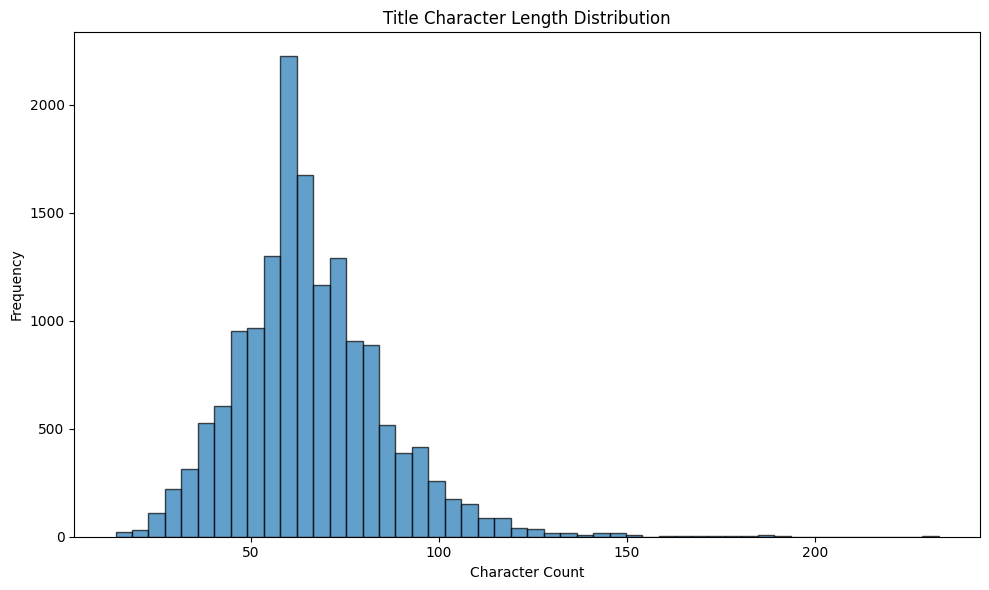


Average title length: 65.83 characters


In [26]:
# Title length distribution
raw_train['title_length'] = raw_train['title'].fillna('').str.len()                 # Title word count

# Title character length
plt.figure(figsize=(10, 6))
plt.hist(raw_train['title_length'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Title Character Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nAverage title length: {raw_train['title_length'].mean():.2f} characters")

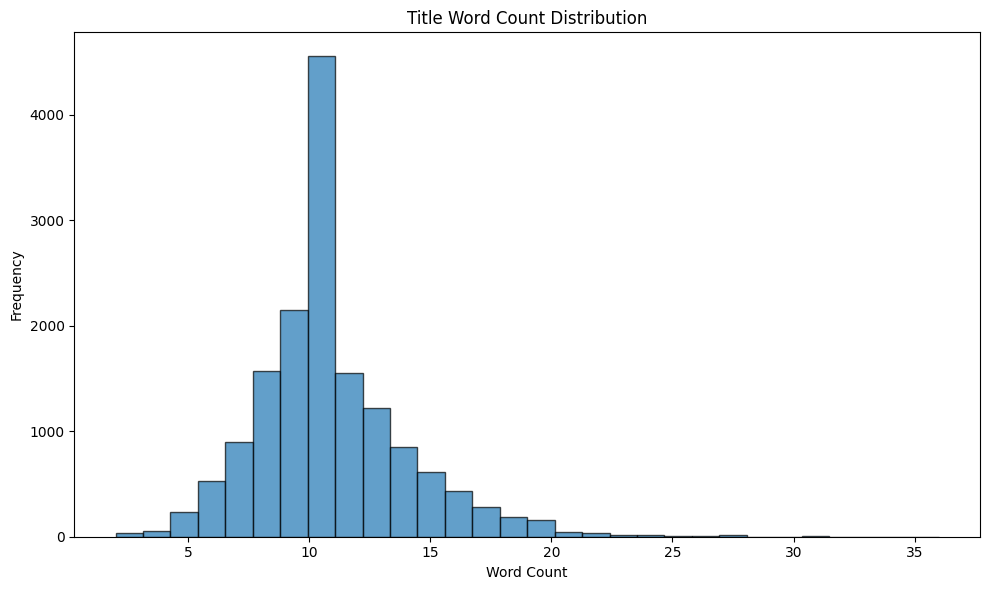

Average title word count: 10.85 words


In [27]:
# Title word count
raw_train['title_word_count'] = raw_train['title'].fillna('').str.split().str.len()

# Title word count
plt.figure(figsize=(10, 6))
plt.hist(raw_train['title_word_count'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Title Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average title word count: {raw_train['title_word_count'].mean():.2f} words")

- Top 20 most common words
- NLP Analysis on Content:

Character length and word count distributions
Average statistics and missing content count
Correlation Analysis:

Sentiment vs title/content length scatter plots

In [28]:
# Most common words in titles
all_title_words = ' '.join(
    raw_train['title']
    .fillna('')
    .astype(str)   # AI Added code to help prevent code breakage in future due to warning errors.
).lower()

words = re.findall(r'\b[a-z]+\b', all_title_words)
word_freq = Counter(words)
common_words = word_freq.most_common(20)

print("\nTop 20 most common words in titles:")
for word, count in common_words:
    print(f"  {word}: {count}")


Top 20 most common words in titles:
  apple: 5885
  to: 5033
  s: 3821
  stocks: 2929
  the: 2874
  in: 2615
  stock: 2316
  and: 1933
  on: 1873
  as: 1798
  for: 1730
  buy: 1617
  of: 1600
  a: 1587
  is: 1494
  tech: 1490
  market: 1359
  dow: 1321
  earnings: 1098
  with: 973


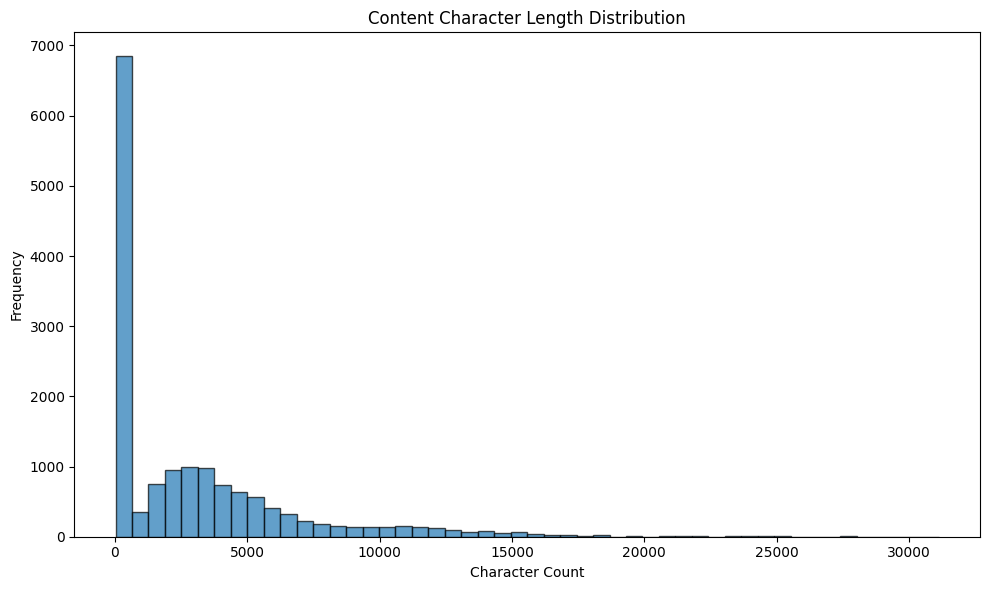


Average content length: 3020.90 characters


In [29]:
# Content length distribution
raw_train.loc[:, 'content_length'] = (
    raw_train['content']
    .fillna('')
    .astype(str)
    .str.len()
) # AI Added code to help prevent code breakage in future due to warning errors.

# Content character length
plt.figure(figsize=(10, 6))
plt.hist(raw_train['content_length'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Content Character Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nAverage content length: {raw_train['content_length'].mean():.2f} characters")

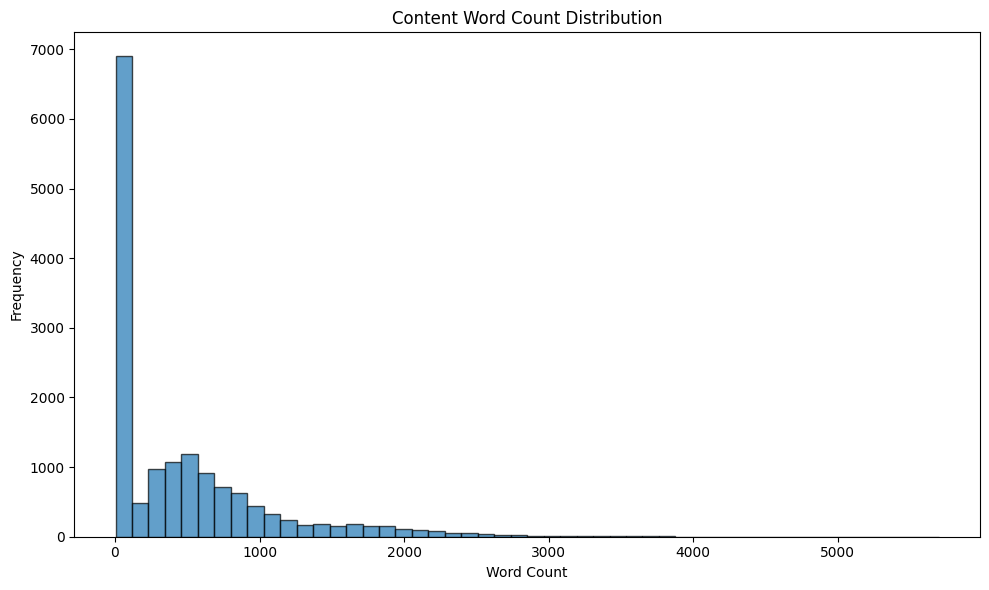

Average content word count: 481.55 words


In [30]:
# Content word count
raw_train.loc[:, 'content_word_count'] = (
    raw_train['content']
    .fillna('')
    .astype(str)
    .str.split()
    .str.len()
) # AI Added code to help prevent code breakage in future due to warning errors.

# Content word count distribution
plt.figure(figsize=(10, 6))
plt.hist(raw_train['content_word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Content Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average content word count: {raw_train['content_word_count'].mean():.2f} words")

In [31]:
print(f"Missing content: {raw_train['content'].isna().sum()} articles")

Missing content: 0 articles


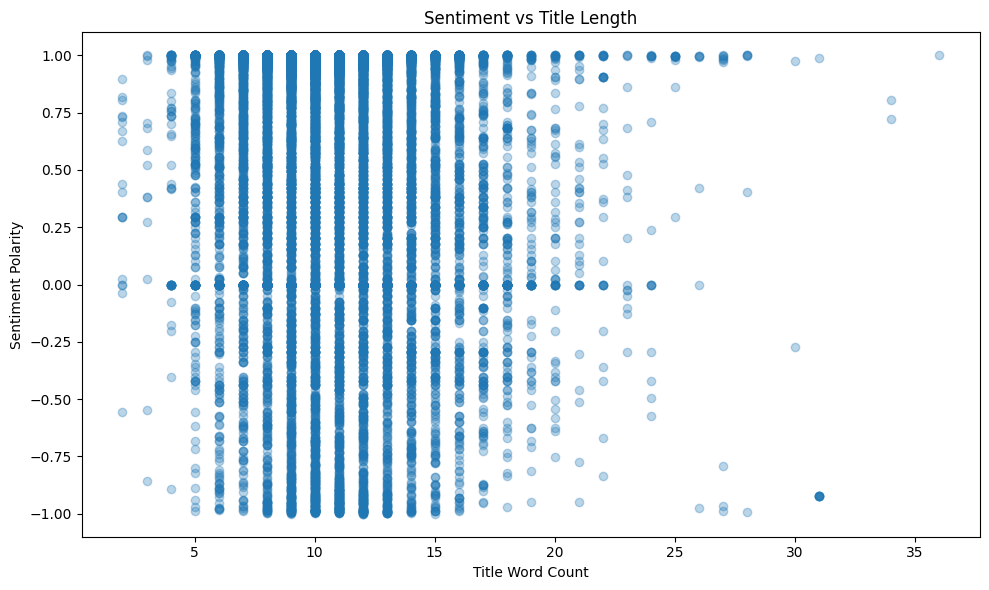

In [32]:
# Sentiment vs Title Length
plt.figure(figsize=(10, 6))
plt.scatter(raw_train['title_word_count'], raw_train['sentiment_polarity'], alpha=0.3)
plt.title('Sentiment vs Title Length')
plt.xlabel('Title Word Count')
plt.ylabel('Sentiment Polarity')
plt.tight_layout()
plt.show()

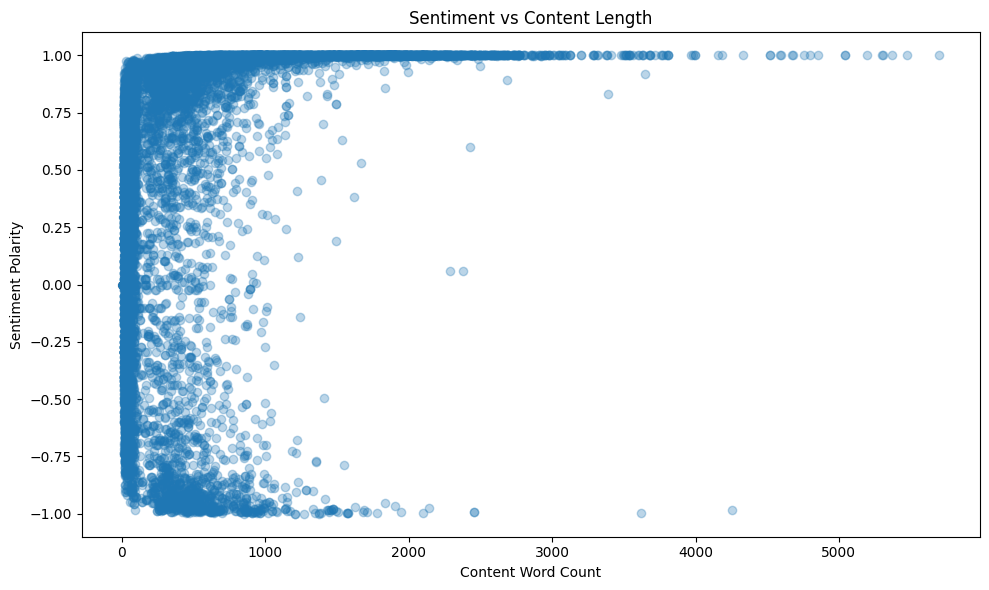

In [33]:
# Sentiment vs Content Length
plt.figure(figsize=(10, 6))
plt.scatter(raw_train['content_word_count'], raw_train['sentiment_polarity'], alpha=0.3)
plt.title('Sentiment vs Content Length')
plt.xlabel('Content Word Count')
plt.ylabel('Sentiment Polarity')
plt.tight_layout()
plt.show()

## Split Price Dataset

In [34]:
ts_data = ts_data.sort_values("Dates").reset_index(drop=True)

ts_train = ts_data[(ts_data["Dates"] >= "2018-01-01") & (ts_data["Dates"] <= "2022-10-31")]
ts_val   = ts_data[(ts_data["Dates"] >= "2022-11-01") & (ts_data["Dates"] <= "2023-10-31")]
ts_test  = ts_data[(ts_data["Dates"] >= "2023-11-01") & (ts_data["Dates"] <= "2024-10-31")]

print(ts_train.shape)
print(ts_val.shape)
print(ts_test.shape)

ts_train.head(10)

(1217, 2)
(251, 2)
(252, 2)


,Dates,AAPL Share Price
0,2018-01-02,43.07
1,2018-01-03,43.06
2,2018-01-04,43.26
3,2018-01-05,43.75
4,2018-01-08,43.59
5,2018-01-09,43.58
6,2018-01-10,43.57
7,2018-01-11,43.82
8,2018-01-12,44.27
9,2018-01-16,44.05


## EDA Price Dataset

In [35]:
ts_train.describe()

,Dates,AAPL Share Price
count,1217,1217.000000
mean,2020-06-01 17:34:15.875102720,96.583131
min,2018-01-02 00:00:00,35.550000
25%,2019-03-20 00:00:00,50.690000
50%,2020-06-03 00:00:00,81.300000
75%,2021-08-17 00:00:00,142.000000
max,2022-10-31 00:00:00,182.010000
std,NaN,46.350782


In [36]:
# Check for missing values
print("Missing values in ts_train:")
print(ts_train.isnull().sum())
print(f"\nPercentage of missing values:")
print((ts_train.isnull().sum() / len(ts_train) * 100).round(2))

Missing values in ts_train:
Dates               0
AAPL Share Price    0
dtype: int64

Percentage of missing values:
Dates               0.0
AAPL Share Price    0.0
dtype: float64


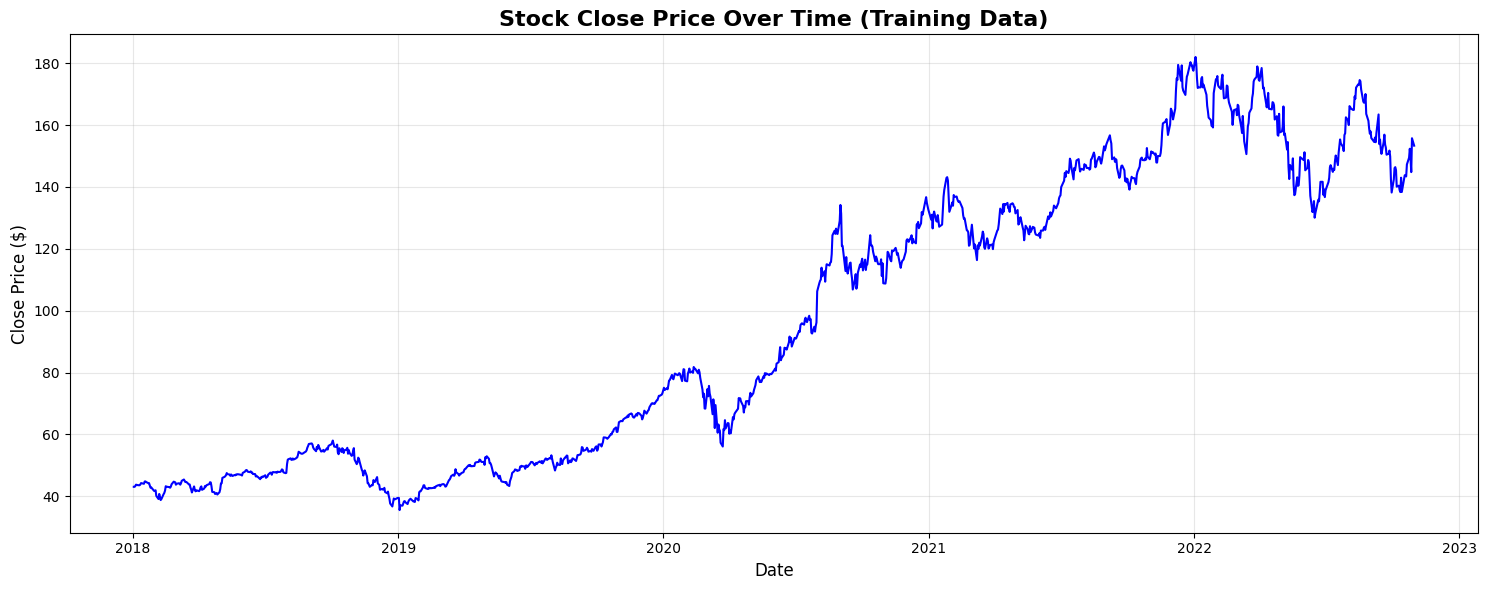

In [37]:
# Time Series Plot of Close Price
plt.figure(figsize=(15, 6))
plt.plot(ts_train['Dates'], ts_train['AAPL Share Price'], linewidth=1.5, color='blue')
plt.title('Stock Close Price Over Time (Training Data)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

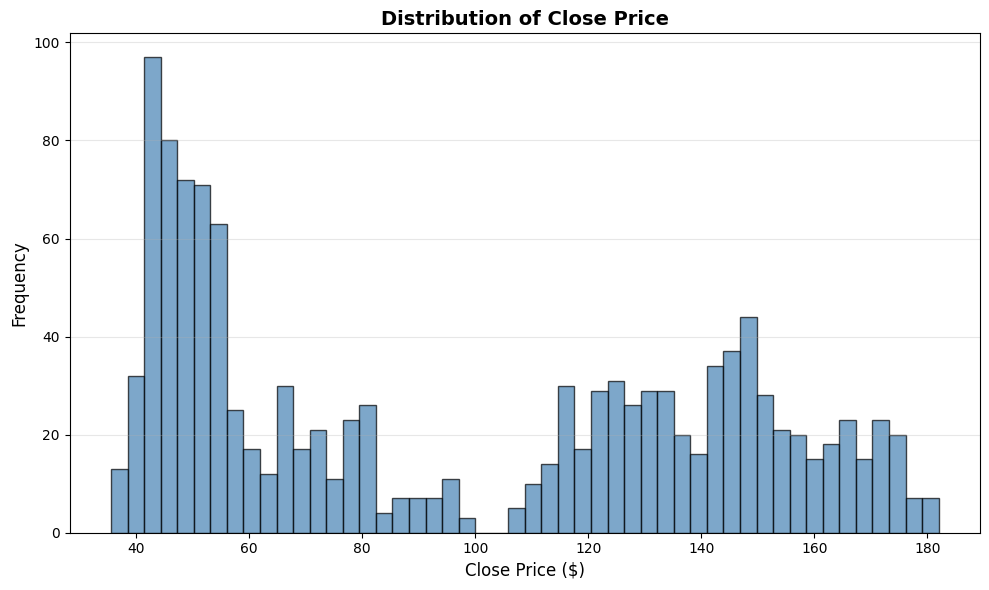

In [38]:
# Distribution of Close Price
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(ts_train['AAPL Share Price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Close Price', fontsize=14, fontweight='bold')
plt.xlabel('Close Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

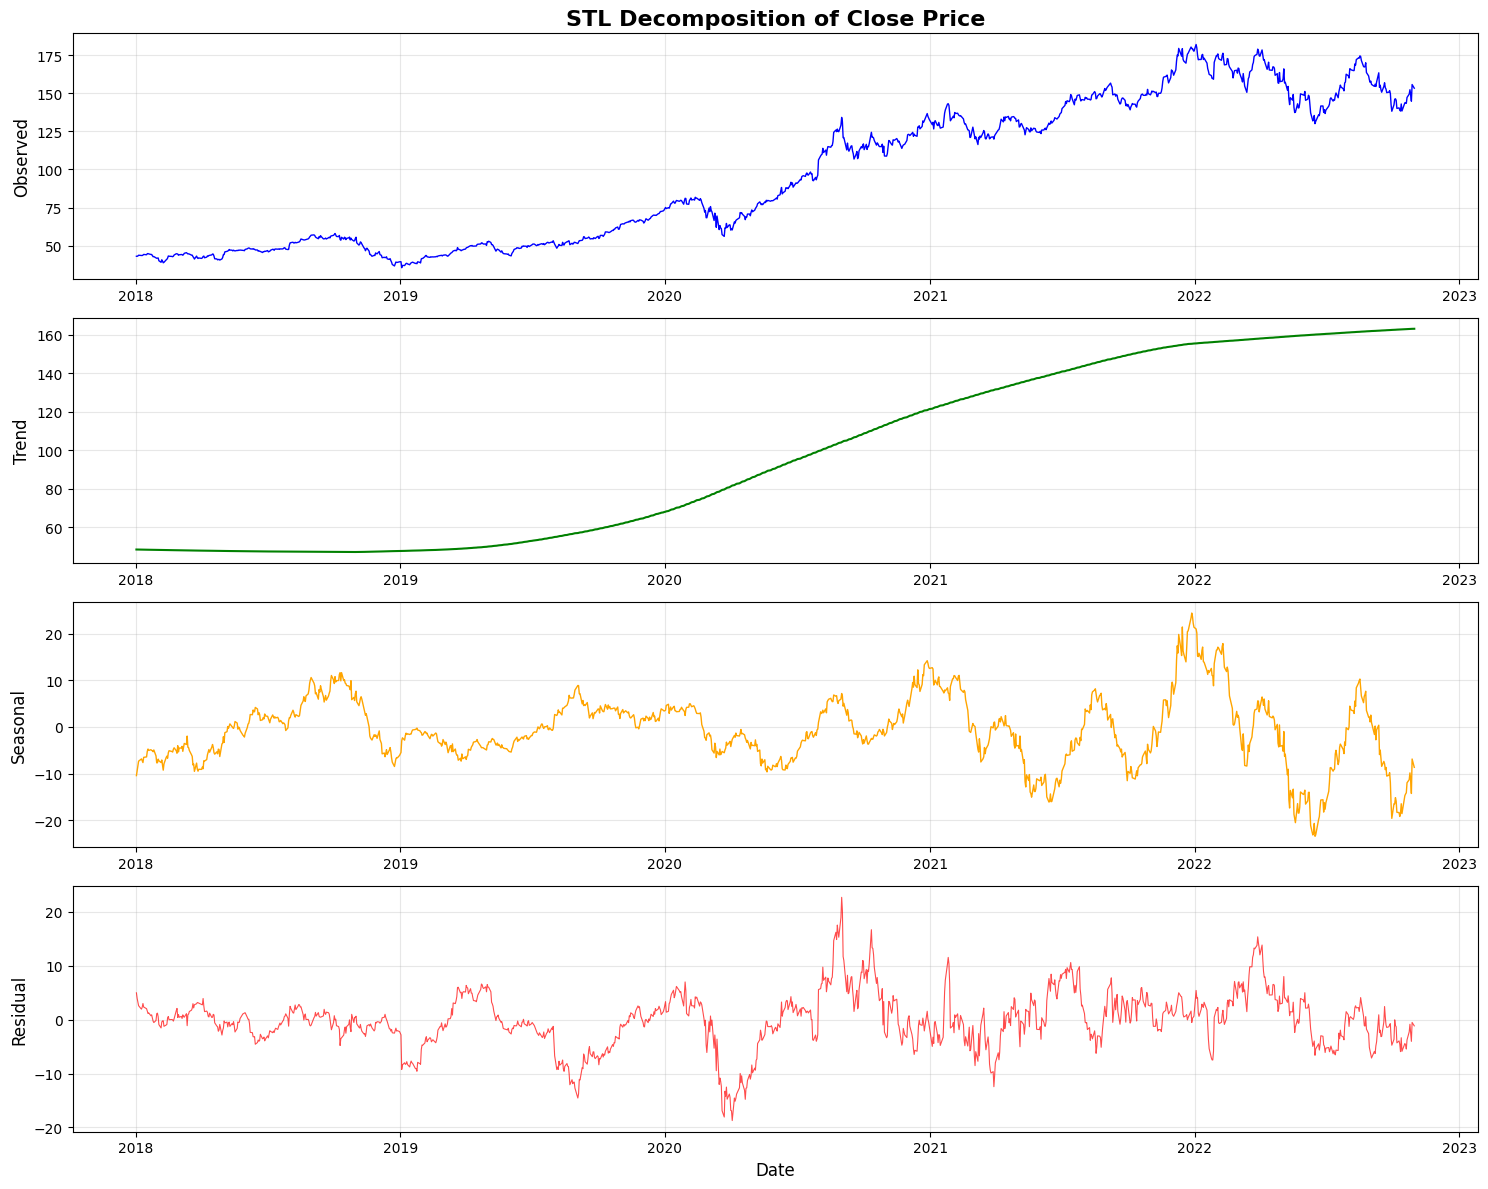

In [39]:
# STL Decomposition (Seasonal-Trend decomposition using LOESS)
# Prepare time series for STL
ts_for_stl = ts_train.set_index('Dates')['AAPL Share Price']

# Perform STL decomposition
stl = STL(ts_for_stl, seasonal=13, period=252)  # 252 trading days per year
stl_result = stl.fit()

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Original
axes[0].plot(stl_result.observed, color='blue', linewidth=1)
axes[0].set_ylabel('Observed', fontsize=12)
axes[0].set_title('STL Decomposition of Close Price', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(stl_result.trend, color='green', linewidth=1.5)
axes[1].set_ylabel('Trend', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(stl_result.seasonal, color='orange', linewidth=1)
axes[2].set_ylabel('Seasonal', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(stl_result.resid, color='red', linewidth=0.8, alpha=0.7)
axes[3].set_ylabel('Residual', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

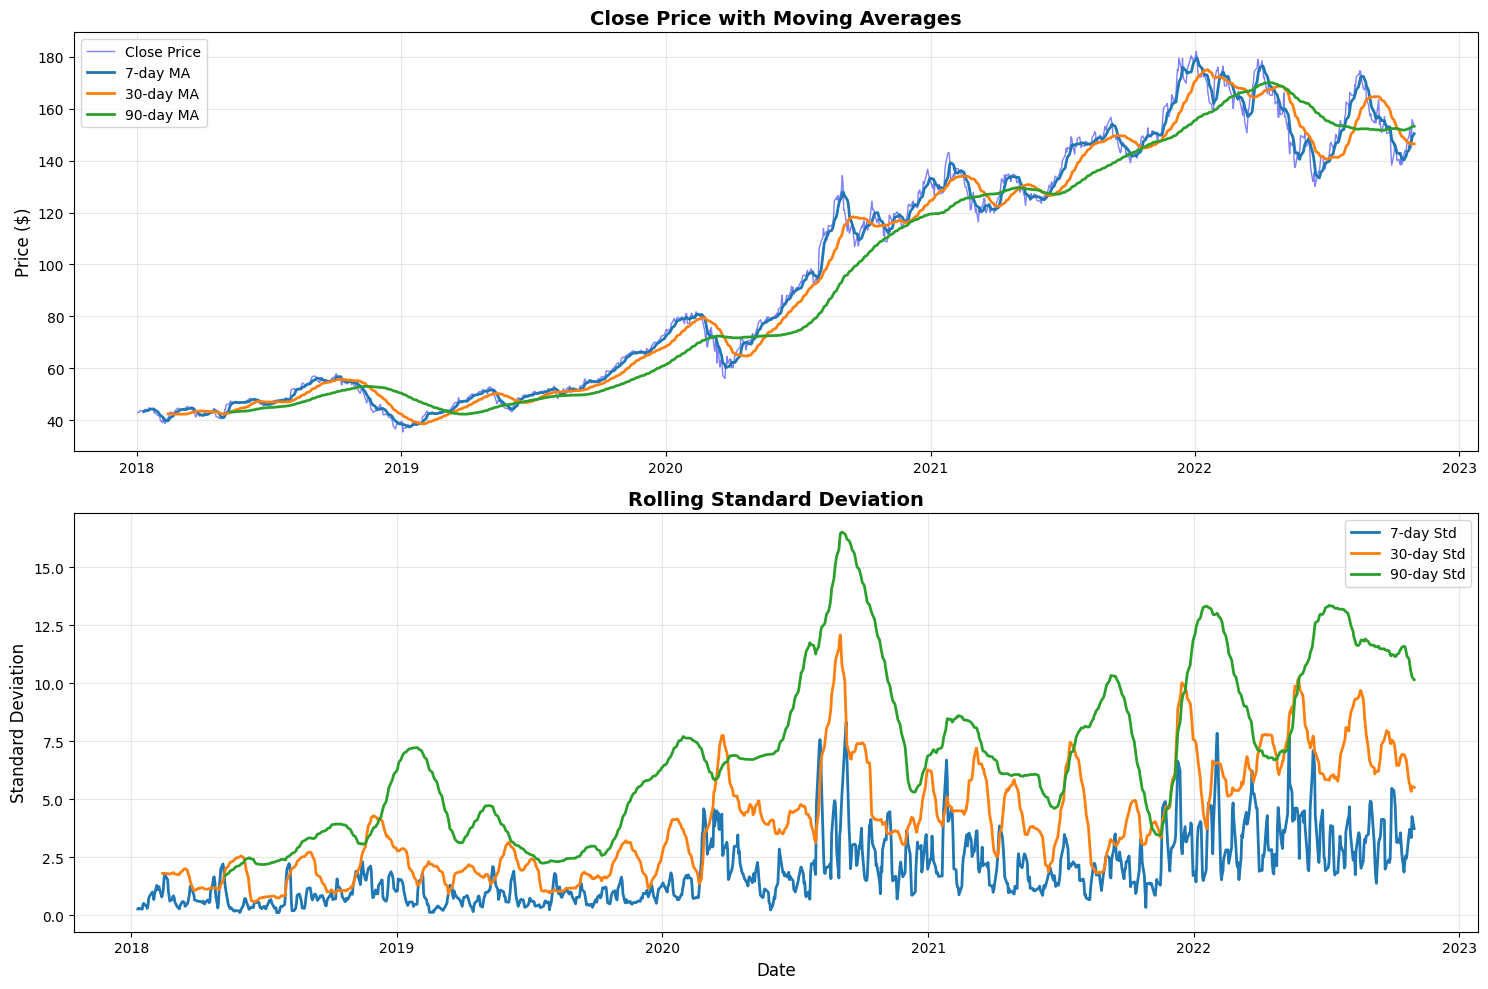

In [40]:
# Rolling Statistics (Moving Average and Standard Deviation)
window_sizes = [7, 30, 90]  # 1 week, 1 month, 3 months

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Rolling Mean
axes[0].plot(ts_train['Dates'], ts_train['AAPL Share Price'], label='Close Price', linewidth=1, alpha=0.5, color='blue')
for window in window_sizes:
    rolling_mean = ts_train['AAPL Share Price'].rolling(window=window).mean()
    axes[0].plot(ts_train['Dates'], rolling_mean, label=f'{window}-day MA', linewidth=2)
axes[0].set_title('Close Price with Moving Averages', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Rolling Standard Deviation
for window in window_sizes:
    rolling_std = ts_train['AAPL Share Price'].rolling(window=window).std()
    axes[1].plot(ts_train['Dates'], rolling_std, label=f'{window}-day Std', linewidth=2)
axes[1].set_title('Rolling Standard Deviation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

During the period of time covered by the train data, AAPL stock fluctuates, but increases overall from July, 2020 to about January 2022. Then, it continues to flucctuate but trends down until July, 2022.

We can also build a plot of the sentiment polarity over the same period of time and compare the two charts.

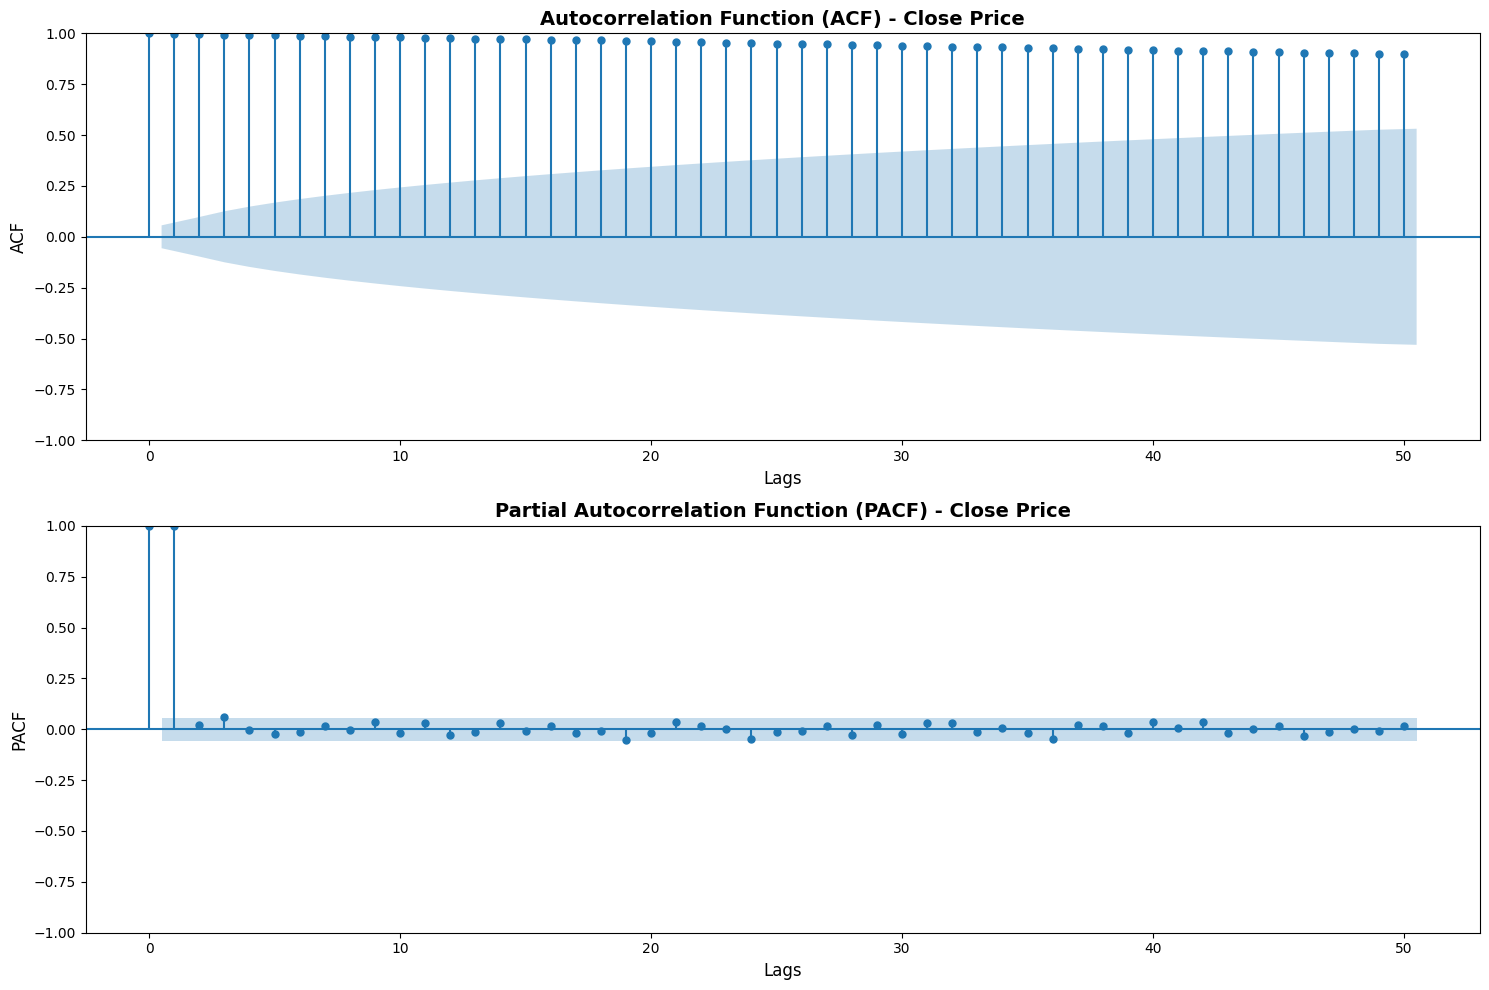

In [41]:
# ACF and PACF Plots
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ACF
plot_acf(ts_train['AAPL Share Price'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - Close Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=12)

# PACF
plot_pacf(ts_train['AAPL Share Price'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - Close Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=12)

plt.tight_layout()
plt.show()

# Week 4: Make Data Model Ready

## Sentiment Dataset Cleaning

In order to make the sentiment dataset ready for modeling we will first combine our title and content columns into one full text column. We will remove the columns (title, content, net sentiment, title_length, title_word_count, content_length, content_word_count) that will not be necessary for training our model and aggregate full_text column by date to create a daily text feature for modeling and aggregate sentiment_polarity, sentiment_neg, sentiment_neu and sentiment_pos by mean for each date. This will create a daily summary of the news articles and their sentiment scores.

Combine each dataset (train, validation and test) with the corresponding dates in timeseries dataset (ts_train, ts_val, ts_test) to create the final training datasets that contains the daily aggregated full_text, sentiment_neg, sentiment_neu, and sentiment_pos along with the AAPL Share Price for each date. We use time series dates as the main column dates so that all sentiment datasets dates are aligned with ts_train dates. This will allow us to have a complete dataset for modeling that includes both the text features and the target variable.

Finally we will fill missing data in the full_text column by replacing NaN values with a blank string to avoid putting in placeholders that would otherwise introduce noice into the model. We will forward fill sentiment values up to 7 days as news diminishes overtime and will leave the remaining values at 0.

### Data Pre-Processing

In [42]:
#Combine title and content into a single text column for NLP processing and consistency across train, val, and test sets. 
raw_train['full_text'] = raw_train['title'] + ' ' + raw_train['content']
raw_val['full_text'] = raw_val['title'] + ' ' + raw_val['content']
raw_test['full_text'] = raw_test['title'] + ' ' + raw_test['content']

In [43]:
# Remove unnecessary columns from train, val, and test sets to focus on text and sentiment features.
raw_train = raw_train.drop(columns=['title', 'content', 'title_length', 'title_word_count', 'content_length', 'content_word_count'])
raw_val = raw_val.drop(columns=['title', 'content'])
raw_test = raw_test.drop(columns=['title', 'content'])

In [44]:
# print out the columns and data types for each dataset to ensure they are consistent and correctly formatted for modeling.
print('Training set columns and data types:')
for col in raw_train.columns:
    print(f'Column: {col} , Data Type: {raw_train[col].dtype}')

print('\nValidation set columns and data types:')
for col in raw_val.columns:
    print(f'Column: {col} , Data Type: {raw_val[col].dtype}')

print('\nTest set columns and data types:')
for col in raw_test.columns:
    print(f'Column: {col} , Data Type: {raw_test[col].dtype}')

Training set columns and data types:
Column: date , Data Type: datetime64[ns]
Column: symbols , Data Type: object
Column: sentiment_polarity , Data Type: float64
Column: sentiment_neg , Data Type: float64
Column: sentiment_neu , Data Type: float64
Column: sentiment_pos , Data Type: float64
Column: full_text , Data Type: object

Validation set columns and data types:
Column: date , Data Type: datetime64[ns]
Column: symbols , Data Type: object
Column: sentiment_polarity , Data Type: float64
Column: sentiment_neg , Data Type: float64
Column: sentiment_neu , Data Type: float64
Column: sentiment_pos , Data Type: float64
Column: full_text , Data Type: object

Test set columns and data types:
Column: date , Data Type: datetime64[ns]
Column: symbols , Data Type: object
Column: sentiment_polarity , Data Type: float64
Column: sentiment_neg , Data Type: float64
Column: sentiment_neu , Data Type: float64
Column: sentiment_pos , Data Type: float64
Column: full_text , Data Type: object


In [45]:
# Aggregate columns by date to create a daily text feature for modeling
# Aggregate sentiment columns by mean for each date.
raw_train = raw_train.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),  # Combine all text for the day
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
})

raw_val = raw_val.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),  # Combine all text for the day
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
})

raw_test = raw_test.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),  # Combine all text for the day
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
})

In [46]:
raw_train.head(10)

,full_text,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_polarity
date,,,,,
2018-01-31,Investor Expectations to Drive Momentum within...,0.009,0.9370,0.054,0.9950
2018-03-16,Top 100 Reputable Companies Around the Globe A...,0.011,0.9170,0.072,0.9910
2018-03-27,Universal Display Corporation Stock Is Way Und...,0.134,0.7640,0.101,-0.2440
2018-04-16,Detailed Research: Economic Perspectives on Ge...,0.008,0.9300,0.062,0.9970
2018-06-22,"Apple iPhone Spared Tariffs, But Could Face Ch...",0.138,0.8620,0.000,-0.8070
2018-10-23,Report: Exploring Fundamental Drivers Behind T...,0.008,0.9410,0.051,0.9950
2018-11-30,"New Research Coverage Highlights Omeros, Apple...",0.009,0.9250,0.066,0.9980
2019-01-03,"Apple, AAPL Investment Losses Alert: Bernstein...",0.044,0.8275,0.129,0.9795
2019-02-22,"Factors of Influence in 2019, Key Indicators a...",0.009,0.9280,0.064,0.9970


### NLP Pre-Processing

In [47]:
# lowercase the text for consistency in NLP processing
raw_train['full_text'] = raw_train['full_text'].str.lower()
raw_val['full_text'] = raw_val['full_text'].str.lower()
raw_test['full_text'] = raw_test['full_text'].str.lower()

In [48]:
# Remove punctuation and special characters from the text
raw_train['full_text'] = raw_train['full_text'].str.replace(r'[^\w\s]', '', regex=True)
raw_val['full_text'] = raw_val['full_text'].str.replace(r'[^\w\s]', '', regex=True)
raw_test['full_text'] = raw_test['full_text'].str.replace(r'[^\w\s]', '', regex=True)

In [49]:
# Remove extra whitespace
raw_train['full_text'] = raw_train['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
raw_val['full_text'] = raw_val['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
raw_test['full_text'] = raw_test['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [50]:
# Remove stop words (common words that may not add much meaning to the text)
raw_train['full_text'] = raw_train['full_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)
raw_val['full_text'] = raw_val['full_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)
raw_test['full_text'] = raw_test['full_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)

In [51]:
# Tokensize the text data.
raw_train['tokens'] = raw_train['full_text'].str.split()
raw_val['tokens'] = raw_val['full_text'].str.split()
raw_test['tokens'] = raw_test['full_text'].str.split()

### Final Train, Val and Test sets

In [52]:
# Combine each dataset with corresponding stock price data.
Final_Raw_X_train = pd.merge(ts_train[['Dates', 'AAPL Share Price']], raw_train, left_on='Dates', right_index=True, how='left')
Final_Raw_X_val = pd.merge(ts_val[['Dates', 'AAPL Share Price']], raw_val, left_on='Dates', right_index=True, how='left')
Final_Raw_X_test = pd.merge(ts_test[['Dates', 'AAPL Share Price']], raw_test, left_on='Dates', right_index=True, how='left')

In [53]:
#For Nan values in the full_text column, fill with an empty string to allow for NLP processing without errors.
Final_Raw_X_train['full_text'] = Final_Raw_X_train['full_text'].fillna('')
Final_Raw_X_val['full_text'] = Final_Raw_X_val['full_text'].fillna('')
Final_Raw_X_test['full_text'] = Final_Raw_X_test['full_text'].fillna('')

# For Nan values in the sentiment columns, forwardfill up to 7 days ahead and replace remaining NaNs with 0.
for col in ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_polarity']:
    #Final_Raw_X_train[col] = Final_Raw_X_train[col].fillna(method='ffill', limit=7).fillna(0)
    #Final_Raw_X_val[col] = Final_Raw_X_val[col].fillna(method='ffill', limit=7).fillna(0)
    #Final_Raw_X_test[col] = Final_Raw_X_test[col].fillna(method='ffill', limit=7).fillna(0)

    Final_Raw_X_train[col] = Final_Raw_X_train[col].ffill(limit=7).fillna(0)
    Final_Raw_X_val[col] = Final_Raw_X_val[col].ffill(limit=7).fillna(0)
    Final_Raw_X_test[col] = Final_Raw_X_test[col].ffill(limit=7).fillna(0)

In [54]:
# Create stock price direction target variable: 'up' if current day's price is higher than previous day, 'down' if lower or equal.
Final_Raw_X_train['Stock Price Direction'] = (Final_Raw_X_train['AAPL Share Price'] > Final_Raw_X_train['AAPL Share Price'].shift(1)).map({True: 'up', False: 'down'})
Final_Raw_X_val['Stock Price Direction'] = (Final_Raw_X_val['AAPL Share Price'] > Final_Raw_X_val['AAPL Share Price'].shift(1)).map({True: 'up', False: 'down'})
Final_Raw_X_test['Stock Price Direction'] = (Final_Raw_X_test['AAPL Share Price'] > Final_Raw_X_test['AAPL Share Price'].shift(1)).map({True: 'up', False: 'down'})

In [55]:
Final_Raw_X_train.head(10)

,Dates,AAPL Share Price,full_text,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_polarity,tokens,Stock Price Direction
0,2018-01-02,43.07,,0.0,0.0,0.0,0.0,NaN,down
1,2018-01-03,43.06,,0.0,0.0,0.0,0.0,NaN,down
2,2018-01-04,43.26,,0.0,0.0,0.0,0.0,NaN,up
3,2018-01-05,43.75,,0.0,0.0,0.0,0.0,NaN,up
4,2018-01-08,43.59,,0.0,0.0,0.0,0.0,NaN,down
5,2018-01-09,43.58,,0.0,0.0,0.0,0.0,NaN,down
6,2018-01-10,43.57,,0.0,0.0,0.0,0.0,NaN,down
7,2018-01-11,43.82,,0.0,0.0,0.0,0.0,NaN,up
8,2018-01-12,44.27,,0.0,0.0,0.0,0.0,NaN,up
9,2018-01-16,44.05,,0.0,0.0,0.0,0.0,NaN,down


In [56]:
Final_Raw_X_train.tail(10)

,Dates,AAPL Share Price,full_text,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_polarity,tokens,Stock Price Direction
1207,2022-10-18,143.75,10 best sampp 500 stocks buy according hedge f...,0.023971,0.883971,0.092000,0.550735,"[10, best, sampp, 500, stocks, buy, according,...",up
1208,2022-10-19,143.86,apple aapl expands portfolio redesigned amp ne...,0.046526,0.850947,0.102632,0.661947,"[apple, aapl, expands, portfolio, redesigned, ...",up
1209,2022-10-20,143.39,snap stock tumbles sales growth slows advertis...,0.053167,0.834833,0.111667,0.457667,"[snap, stock, tumbles, sales, growth, slows, a...",down
1210,2022-10-21,147.27,snap stock got crushed early friday catalyst s...,0.036026,0.865795,0.098205,0.408718,"[snap, stock, got, crushed, early, friday, cat...",up
1211,2022-10-24,149.45,apple raises prices services media executives ...,0.036469,0.882906,0.080500,0.510625,"[apple, raises, prices, services, media, execu...",up
1212,2022-10-25,152.34,investors watch recession clues big tech earni...,0.038718,0.873256,0.087923,0.429282,"[investors, watch, recession, clues, big, tech...",up
1213,2022-10-26,149.35,sony gears report q2 earnings heres expect son...,0.044714,0.863750,0.091536,0.364393,"[sony, gears, report, q2, earnings, heres, exp...",down
1214,2022-10-27,144.80,tech live inside appleâs thinking privacy char...,0.037659,0.869439,0.092902,0.546146,"[tech, live, inside, appleâs, thinking, privac...",down
1215,2022-10-28,155.74,stockswall street jumps 2 upbeat apple results...,0.050182,0.854227,0.095621,0.421227,"[stockswall, street, jumps, 2, upbeat, apple, ...",up
1216,2022-10-31,153.34,chinese workers flee covid lockdown huge iphon...,0.045520,0.870900,0.083720,0.359380,"[chinese, workers, flee, covid, lockdown, huge...",down


In [57]:
# Initialize the TF-IDF Vectorizer with a maximum of 10000 features and English stop words removal.
tfidf_vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')

# Fit on training data and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(Final_Raw_X_train['full_text'])
X_val_tfidf = tfidf_vectorizer.transform(Final_Raw_X_val['full_text'])
X_test_tfidf = tfidf_vectorizer.transform(Final_Raw_X_test['full_text'])

In [58]:
# Check distribution of Stock Price Direction
print("Training Set - Stock Price Direction Distribution:")
print(Final_Raw_X_train['Stock Price Direction'].value_counts())
print(Final_Raw_X_train['Stock Price Direction'].value_counts(normalize=True).round(3))

Training Set - Stock Price Direction Distribution:
Stock Price Direction
up      643
down    574
Name: count, dtype: int64
Stock Price Direction
up      0.528
down    0.472
Name: proportion, dtype: float64


## Price Dataset Cleaning

Next, we will clean the price dataset. The price dataset only contains time series AAPL price. The main purpose of this dataset will be to predict the direction of AAPL stock using only historical price data.

Our EDA indicated that there were no noticeable outliers in the stock price data. As a result, no measures were taken to remove outliers.

There are no missing values in the training, validation, or test data, so the step  of imputing missing values can be skipped altogether.

Finally, the dataset is transformed to prepare it for a classification problem. With this dataset, we will use the directional movement of AAPL stock in previous days to predict future directional movement.

In [59]:
def price_cleaning(df_price: pd.DataFrame) -> pd.DataFrame:
    df_price = df_price.copy()
    df_price = df_price.sort_values("Dates")

    # Create price lags
    for i in range(1, 6):
        df_price.loc[:, f"aapl_price_lag{i}"] = df_price["AAPL Share Price"].shift(i)

    # Create direction lags (1 = Up, 0 = Down)
    for i in range(1, 5):
        df_price.loc[:, f"aapl_price_direction_lag{i}"] = (
            (df_price[f"aapl_price_lag{i}"] - df_price[f"aapl_price_lag{i+1}"]) > 0
        ).astype(int)

    # Create target direction variable
    df_price.loc[:, "Stock Price Direction"] = (
        (df_price["AAPL Share Price"] - df_price["aapl_price_lag1"]) > 0
    ).map({True: "Up", False: "Down"})

    # Finalize columns
    final_cols = [
        "Stock Price Direction", "Dates",
        "aapl_price_direction_lag1", "aapl_price_direction_lag2",
        "aapl_price_direction_lag3", "aapl_price_direction_lag4"
    ]
    return df_price.loc[:, final_cols].reset_index(drop=True)

The training, validation, and test sets are cleaned seperately, but in the same fashion, to prevent data leakage. 

In [60]:
# Apply to training set
cleaned_ts_train = price_cleaning(ts_train)

# Apply to validation and test sets seperately to aviod data leakage
cleaned_ts_val = price_cleaning(ts_val)
cleaned_ts_test = price_cleaning(ts_test)
cleaned_ts_train.head()

,Stock Price Direction,Dates,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
0,Down,2018-01-02,0,0,0,0
1,Down,2018-01-03,0,0,0,0
2,Up,2018-01-04,0,0,0,0
3,Up,2018-01-05,1,0,0,0
4,Down,2018-01-08,1,1,0,0


## Combined Dataset Creation and Cleaning

This section of the notebook will ensure that the combined dataset (including both the text and price series data) is cleaned and model ready. We encapsulate all cleaning and preprocessing methods in one data_cleaning() function, which will be called identically on the validation and test datasets.

The first decision is whether to remove outliers. Referencing the line graph above, there are a few outlying observations with a negative sentiment polarity that are extremely different from the preceding and following days. However, there is still some value in keeping these observations. Many of them coincide with dips in the AAPL stock price, and this could be very value information for the classification model. As a result, all outliers will remain in this dataset.

The next decision is on missing data. All missing data comes from the sentiment news dataset as there are some days where no articles on the AAPL stock were published. One basic assumption we can make is that the sentiment in media will be relatively stable until a new article is published with new sentiment. To follow this logic, we institute a forward fill function where the most recent sentiment score will fill in any missing observation. However, we put a cap of a week, insinuating that articles more than a week old are too antiquated to reflect current sentiment.

The next decision is whether to standardize the sentiment news scores. These scores are already bounded (between -1 and 1) and centered (0 is a perfectly neutral post). The current distribution is also very intuitive, a negative number means a negative sentiment, a positive number is a positive sentiment. As a result, this variable does not need to be standardized further, it can remain as is. This may be reconsidered if we use a neural network model as these models strongly prefer standardized data.

In [61]:
def data_cleaning(sentiment_data, ts_data):
    # Create a copy to avoid modifying the original DataFrame
    sentiment_data = sentiment_data.copy()

    if 'Stock Price Direction' in sentiment_data.columns:
        sentiment_data.drop(columns = 'Stock Price Direction', inplace = True)
    #join on date
    df = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'Dates', right_on = 'Dates')

# Drop 'tokens' column if present (contains lists which are unhashable)
    if 'tokens' in df.columns:
        df = df.drop(columns=['tokens'])

    for i in range(1, 6):
        #create lags for both price and sentiment polarity variables
        df[f'sentiment_polarity_lag{i}'] = df['sentiment_polarity'].shift(i)
        df[f'sentiment_pos_lag{i}'] = df['sentiment_pos'].shift(i)
        df[f'sentiment_neu_lag{i}'] = df['sentiment_neu'].shift(i)
        df[f'sentiment_neg_lag{i}'] = df['sentiment_neg'].shift(i)
    
    #drop rows that are missing lagged variables
    df.dropna(inplace = True)

    #drop duplicates, but there shouldn't be any because of the primary key date
    df.drop_duplicates(inplace = True)

    #pick the final columns for our dataset
    final_df = df[['Stock Price Direction', 'AAPL Share Price', 'Dates', 'sentiment_polarity', 'sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4']]

    return final_df

    

In [62]:
#perform data cleaning for training dataset
cleaned_com_train = data_cleaning(Final_Raw_X_train, cleaned_ts_train)
cleaned_com_train.head(10)

,Stock Price Direction,AAPL Share Price,Dates,sentiment_polarity,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,Down,43.58,2018-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
6,Down,43.57,2018-01-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1
7,Up,43.82,2018-01-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1
8,Up,44.27,2018-01-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0
9,Down,44.05,2018-01-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
10,Up,44.78,2018-01-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
11,Up,44.82,2018-01-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1
12,Down,44.62,2018-01-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,1
13,Down,44.25,2018-01-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
14,Up,44.26,2018-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1


In [63]:
for col in cleaned_com_train.columns:
    print(f'Column: {col} , Data Type: {type(cleaned_com_train[col][20])}')

Column: Stock Price Direction , Data Type: <class 'str'>
Column: AAPL Share Price , Data Type: <class 'numpy.float64'>
Column: Dates , Data Type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
Column: sentiment_polarity , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag1 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag2 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag3 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag4 , Data Type: <class 'numpy.float64'>
Column: sentiment_polarity_lag5 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag1 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag2 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag3 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag4 , Data Type: <class 'numpy.float64'>
Column: sentiment_pos_lag5 , Data Type: <class 'numpy.float64'>
Column: sentiment_neu_lag1 , Data Type: <class 'numpy.float64'>
Column: se

In [64]:
cleaned_com_train['sentiment_polarity'].describe()

count    1212.000000
mean        0.342105
std         0.443149
min        -0.993000
25%         0.000000
50%         0.358211
75%         0.654409
max         1.000000
Name: sentiment_polarity, dtype: float64

The sentiment polarity looks to be performing as expected. Scores range from -.99 to 1.00, but most are positive (which is expected due to Apple's stellar performance during this time period.

All models will use next-day stock price direction as the main target variable. There will be three possible forecasting models, the traditional model will exclusively use previous stock prices as predictor variables, the second model exclusively uses sentiment analysis as the predictor variable, while the third model will combine both.

In [65]:
cleaned_com_train['sentiment_polarity'].isna().sum()

np.int64(0)

There are no missing sentiment polarity scores. This is ideal since it will be feature in the final model.

We can also view a correlation matrix to look at how our two variables are correlated.

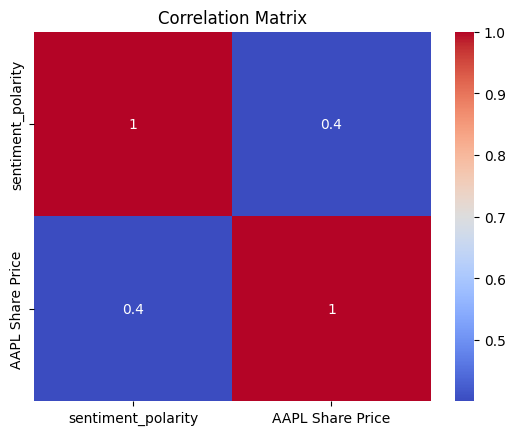

In [66]:
corr_matrix = cleaned_com_train[["sentiment_polarity", "AAPL Share Price"]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Finally, we can observe a seasonal compostion of the train data.

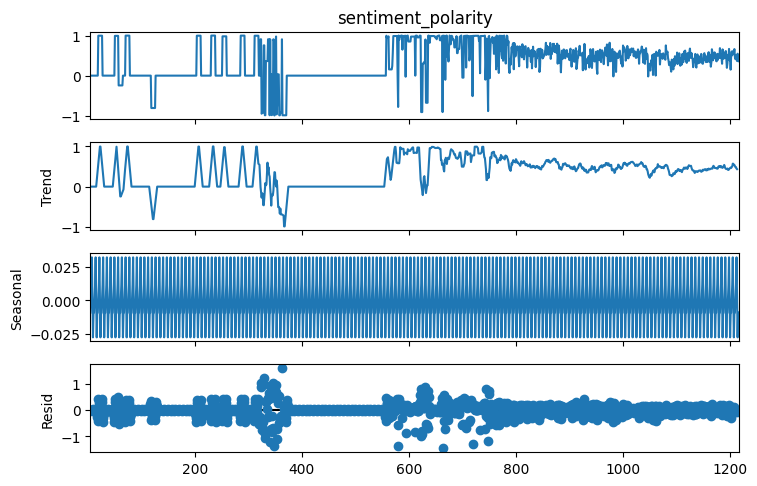

In [67]:
y = cleaned_com_train['sentiment_polarity'].dropna()

decomp = seasonal_decompose(y, model='additive', period=7)
decomp.plot()
plt.gcf().set_size_inches(8, 5)
plt.show()

In [68]:
#now that we've performed our EDA, we should drop these columns since they won't be used in the model
cleaned_com_train.drop(columns = ['sentiment_polarity', 'AAPL Share Price', 'Dates'], inplace = True)

In [69]:
#perform data cleaning for validation set
cleaned_com_val = data_cleaning(Final_Raw_X_val, cleaned_ts_val)
cleaned_com_val.drop(columns = ['sentiment_polarity', 'AAPL Share Price', 'Dates'], inplace = True)
cleaned_com_val.head(10)

,Stock Price Direction,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,sentiment_pos_lag2,sentiment_pos_lag3,sentiment_pos_lag4,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,Up,0.102262,0.444375,0.347913,0.283481,0.326217,0.055049,0.078083,0.095217,0.084000,...,0.890783,0.064508,0.039750,0.042043,0.055815,0.040957,1,0,0,0
6,Down,0.398720,0.102262,0.444375,0.347913,0.283481,0.077240,0.055049,0.078083,0.095217,...,0.860148,0.047560,0.064508,0.039750,0.042043,0.055815,1,1,0,0
7,Up,0.399429,0.398720,0.102262,0.444375,0.347913,0.084333,0.077240,0.055049,0.078083,...,0.862739,0.046905,0.047560,0.064508,0.039750,0.042043,0,1,1,0
8,Up,0.482846,0.399429,0.398720,0.102262,0.444375,0.078179,0.084333,0.077240,0.055049,...,0.882292,0.043359,0.046905,0.047560,0.064508,0.039750,1,0,1,1
9,Down,0.707300,0.482846,0.399429,0.398720,0.102262,0.128350,0.078179,0.084333,0.077240,...,0.880410,0.034300,0.043359,0.046905,0.047560,0.064508,1,1,0,1
10,Up,0.284654,0.707300,0.482846,0.399429,0.398720,0.072192,0.128350,0.078179,0.084333,...,0.875240,0.048538,0.034300,0.043359,0.046905,0.047560,0,1,1,0
11,Down,0.404769,0.284654,0.707300,0.482846,0.399429,0.088500,0.072192,0.128350,0.078179,...,0.868714,0.042423,0.048538,0.034300,0.043359,0.046905,1,0,1,1
12,Up,0.624091,0.404769,0.284654,0.707300,0.482846,0.089591,0.088500,0.072192,0.128350,...,0.878564,0.025318,0.042423,0.048538,0.034300,0.043359,0,1,0,1
13,Up,0.613143,0.624091,0.404769,0.284654,0.707300,0.088000,0.089591,0.088500,0.072192,...,0.837300,0.036357,0.025318,0.042423,0.048538,0.034300,1,0,1,0
14,Down,0.465308,0.613143,0.624091,0.404769,0.284654,0.103231,0.088000,0.089591,0.088500,...,0.879192,0.040462,0.036357,0.025318,0.042423,0.048538,1,1,0,1


In [70]:
#perform data cleaning for test dataset
cleaned_com_test = data_cleaning(Final_Raw_X_test, cleaned_ts_test)
cleaned_com_test.drop(columns = ['sentiment_polarity', 'AAPL Share Price', 'Dates'], inplace = True)
cleaned_com_test.head(10)

,Stock Price Direction,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,sentiment_pos_lag2,sentiment_pos_lag3,sentiment_pos_lag4,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,Up,0.451958,0.493862,0.410016,0.458235,0.558027,0.097333,0.115655,0.103000,0.079216,...,0.840865,0.035458,0.046103,0.055172,0.035961,0.037216,1,1,0,1
6,Down,0.413867,0.451958,0.493862,0.410016,0.458235,0.119333,0.097333,0.115655,0.103000,...,0.884745,0.044700,0.035458,0.046103,0.055172,0.035961,1,1,1,0
7,Up,0.481171,0.413867,0.451958,0.493862,0.410016,0.098257,0.119333,0.097333,0.115655,...,0.841859,0.037257,0.044700,0.035458,0.046103,0.055172,0,1,1,1
8,Down,0.556571,0.481171,0.413867,0.451958,0.493862,0.093250,0.098257,0.119333,0.097333,...,0.838103,0.023393,0.037257,0.044700,0.035458,0.046103,1,0,1,1
9,Up,0.572346,0.556571,0.481171,0.413867,0.451958,0.114115,0.093250,0.098257,0.119333,...,0.867292,0.028577,0.023393,0.037257,0.044700,0.035458,0,1,0,1
10,Up,0.652667,0.572346,0.556571,0.481171,0.413867,0.095786,0.114115,0.093250,0.098257,...,0.835967,0.028738,0.028577,0.023393,0.037257,0.044700,1,0,1,0
11,Up,0.757655,0.652667,0.572346,0.556571,0.481171,0.112310,0.095786,0.114115,0.093250,...,0.864514,0.020690,0.028738,0.028577,0.023393,0.037257,1,1,0,1
12,Down,0.732615,0.757655,0.652667,0.572346,0.556571,0.111346,0.112310,0.095786,0.114115,...,0.883286,0.026115,0.020690,0.028738,0.028577,0.023393,1,1,1,0
13,Up,0.557379,0.732615,0.757655,0.652667,0.572346,0.114448,0.111346,0.112310,0.095786,...,0.857385,0.031414,0.026115,0.020690,0.028738,0.028577,0,1,1,1
14,Down,0.130737,0.557379,0.732615,0.757655,0.652667,0.055421,0.114448,0.111346,0.112310,...,0.875571,0.021474,0.031414,0.026115,0.020690,0.028738,1,0,1,1


# Week 5

We created two new features in last week's notebook. These features are lagging, meaning they show positive, netural, negative and polarity sentiment scores from previous days. This is important because the stock price might not just depend on the previous day's sentiment scores, but other days leading up to it. 

We also created lagging variables for AAPL price direction, so that the model has some historical information in price movement while predicting the next day price movement.

Our dataset is already small in number of observations, so dimension reduction is not necessary. However, to have as a later option for a feature set, principal component analysis is completed here to capture 99% of the variance of the original dataset.

In [71]:
#standardize values according to training_dataset
my_scaler = StandardScaler()

cleaned_com_train_scaled = my_scaler.fit_transform(cleaned_com_train.drop(columns = ['Stock Price Direction']))
cleaned_com_val_scaled   = my_scaler.transform(cleaned_com_val.drop(columns = ['Stock Price Direction']))
cleaned_com_test_scaled  = my_scaler.transform(cleaned_com_test.drop(columns = ['Stock Price Direction']))

In [72]:
#use PCA, but only use training dataset to fit, preventing data leakage
pca = PCA(n_components=0.99) #keep 99% of variance

com_train_pca = pca.fit_transform(cleaned_com_train_scaled)
com_val_pca   = pca.transform(cleaned_com_val_scaled)
com_test_pca  = pca.transform(cleaned_com_test_scaled)

# Week 6 - Logistic Regression

Each of the three datasets will use a logistic regression as a baseline model. The model will be trained on the training dataset and evaluated on the validation set.

## Sentiment Dataset

In [73]:
# Prepare target variable - map 'up'/'down' to 1/0
y_train_sentiment = Final_Raw_X_train['Stock Price Direction'].map({'up': 1, 'down': 0})
y_val_sentiment = Final_Raw_X_val['Stock Price Direction'].map({'up': 1, 'down': 0})

# Drop any rows with NaN target values (first row due to shift)
train_mask = ~y_train_sentiment.isna()
X_train_tfidf = X_train_tfidf[train_mask.values]
y_train_sentiment = y_train_sentiment[train_mask]

val_mask = ~y_val_sentiment.isna()
X_val_tfidf = X_val_tfidf[val_mask.values]
y_val_sentiment = y_val_sentiment[val_mask]

In [74]:
# Extract sentiment features and combine with TF-IDF
sentiment_cols = ['sentiment_pos', 'sentiment_neu', 'sentiment_neg']
X_train_sentiment = Final_Raw_X_train.loc[train_mask, sentiment_cols].values
X_val_sentiment = Final_Raw_X_val.loc[val_mask, sentiment_cols].values

# Combine TF-IDF features with sentiment features
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_sentiment)])
X_val_combined = hstack([X_val_tfidf, csr_matrix(X_val_sentiment)])

print(f"Training set size: {X_train_combined.shape[0]}")
print(f"Validation set size: {X_val_combined.shape[0]}")
print(f"Number of TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"Number of sentiment features: {len(sentiment_cols)}")
print(f"Total combined features: {X_train_combined.shape[1]}")

Training set size: 1217
Validation set size: 251
Number of TF-IDF features: 10000
Number of sentiment features: 3
Total combined features: 10003


In [75]:
# Initialize and train the logistic regression model on TF-IDF features
lr_tfidf = LR(max_iter=500, C=1, random_state=42)
lr_tfidf.fit(X_train_combined, y_train_sentiment)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

Logistic Regression - TF-IDF Text Features Results

Accuracy: 0.5339

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.51      0.26      0.35       118
      Up (1)       0.54      0.77      0.64       133

    accuracy                           0.53       251
   macro avg       0.53      0.52      0.49       251
weighted avg       0.53      0.53      0.50       251


Confusion Matrix:


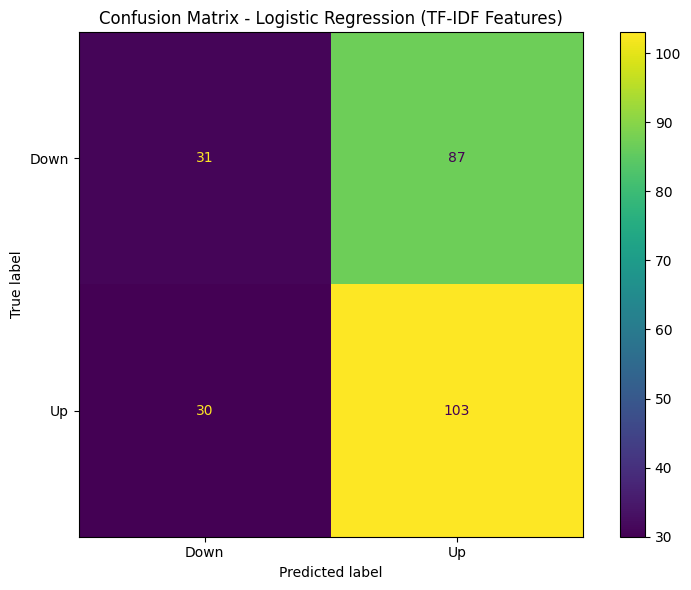

In [76]:
# Make predictions on validation set
y_pred_combined = lr_tfidf.predict(X_val_combined)

# Evaluate the model
print("Logistic Regression - TF-IDF Text Features Results")

# Accuracy
accuracy = accuracy_score(y_val_sentiment, y_pred_combined)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(CR(y_val_sentiment, y_pred_combined, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val_sentiment, y_pred_combined, labels=lr_tfidf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression (TF-IDF Features)")
plt.tight_layout()
plt.show()

In [77]:
def gridsearch_sentiment():
    # Define the hyperparameter grid to search
    param_grid_sentiment = {
        'C': [0.01, 0.1, 1, 10],           # Regularization strength
        'max_iter': [200, 500, 1000],      # Maximum iterations
        'solver': ['lbfgs', 'liblinear'],  # Optimization algorithm
        'penalty': ['l2']                   # Regularization type
    }
    
    # Initialize the logistic regression model
    lr_base = LR(random_state=42)
    
    # Set up GridSearchCV with cross-validation
    grid_search_sentiment = GridSearchCV(
        estimator=lr_base,
        param_grid=param_grid_sentiment,
        cv=5,                              # 5-fold cross-validation
        scoring='accuracy',
        verbose=1
    )
    
    # Fit grid search on training data
    print("Starting Grid Search for Logistic Regression on TF-IDF Features...")
    grid_search_sentiment.fit(X_train_combined, y_train_sentiment)
    
    # Display best parameters and score
    print("Grid Search Results - Sentiment Dataset (TF-IDF)")
    print(f"\nBest Parameters: {grid_search_sentiment.best_params_}")
    print(f"Best Cross-Validation Accuracy: {grid_search_sentiment.best_score_:.4f}")

    # Get the best estimator and CV results
    cv_results = grid_search_sentiment.cv_results_
    
    # Create a results table for each parameter combination
    results_data = []
    
    for i, params in enumerate(cv_results['params']):
        # Create a model with these parameters
        model = LR(**params, random_state=42)
        model.fit(X_train_tfidf, y_train_sentiment)
        
        # Training predictions and metrics
        y_train_pred = model.predict(X_train_tfidf)
        train_acc = accuracy_score(y_train_sentiment, y_train_pred)
        train_f1 = f1_score(y_train_sentiment, y_train_pred, average='weighted')
        
        # Validation predictions and metrics
        y_val_pred = model.predict(X_val_tfidf)
        val_acc = accuracy_score(y_val_sentiment, y_val_pred)
        val_f1 = f1_score(y_val_sentiment, y_val_pred, average='weighted')
        
        results_data.append({
            'C': f"{params['C']:g}",
            'Max Iterations': params['max_iter'],
            'Training Accuracy': f"{train_acc:.3%}",
            'Training F1': f"{train_f1:.3f}",
            'Validation Accuracy': f"{val_acc:.3%}",
            'Validation F1': f"{val_f1:.3f}"
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(results_data)
    
    # Sort by C (descending) and Max Iterations (ascending)
    results_df = results_df.sort_values(['C', 'Max Iterations'], ascending=[False, True]).reset_index(drop=True)

    best_lr_sentiment = grid_search_sentiment.best_estimator_

    #delete grid search to save memory
    del grid_search_sentiment
    gc.collect()

    return results_df, best_lr_sentiment

results_df, best_lr_sentiment = gridsearch_sentiment()

# Display styled table
results_df.style.set_caption("Logistic Regression (TF-IDF Sentiment Dataset)").set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
])

Starting Grid Search for Logistic Regression on TF-IDF Features...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Grid Search Results - Sentiment Dataset (TF-IDF)

Best Parameters: {'C': 0.01, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.5283


,C,Max Iterations,Training Accuracy,Training F1,Validation Accuracy,Validation F1
0,10,200,76.500%,0.749,56.574%,0.561
1,10,200,76.500%,0.749,56.175%,0.557
2,10,500,76.500%,0.749,56.574%,0.561
3,10,500,76.500%,0.749,56.175%,0.557
4,10,1000,76.500%,0.749,56.574%,0.561
5,10,1000,76.500%,0.749,56.175%,0.557
6,1,200,70.419%,0.678,53.785%,0.504
7,1,200,70.419%,0.678,53.386%,0.498
8,1,500,70.419%,0.678,53.785%,0.504
9,1,500,70.419%,0.678,53.386%,0.498


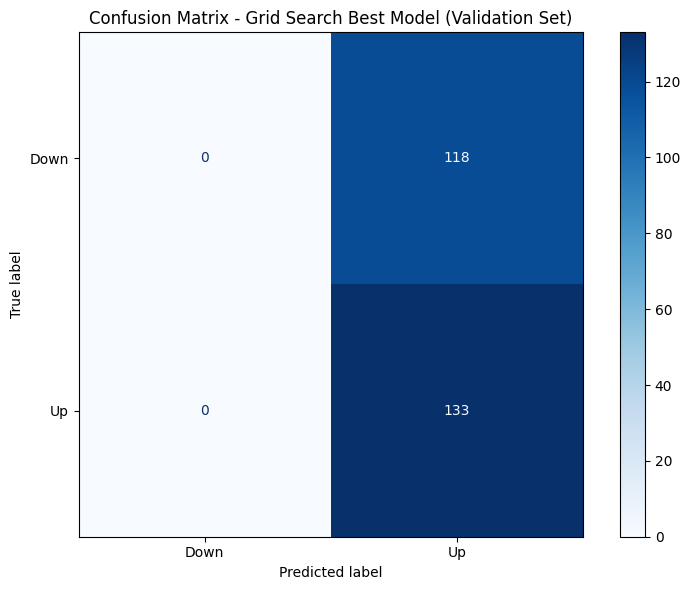

In [78]:
# Get the best model and make predictions on validation set
y_pred_val = best_lr_sentiment.predict(X_val_combined)

# Create and plot confusion matrix
cm = confusion_matrix(y_val_sentiment, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Grid Search Best Model (Validation Set)')
plt.tight_layout()
plt.show()

## Price Dataset

First, a base logistic regression built with the training data from the price dataset.

In [79]:
def fit_model_price(model, train_dataset, val_dataset,
              target_var="Stock Price Direction", print_matrix=True):
    """Fit on train, evaluate on val."""

    train_X = train_dataset.drop(columns=[target_var], errors="ignore")
    train_y = train_dataset[target_var]
    val_X   = val_dataset.drop(columns=[target_var], errors="ignore")
    val_y   = val_dataset[target_var]

    #Drop datetime cols
    dt_cols = train_X.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns
    train_X = train_X.drop(columns=dt_cols)
    val_X   = val_X.drop(columns=dt_cols, errors="ignore")

    #Fit + predict
    model.fit(train_X, train_y)
    my_pred = model.predict(val_X)

    print(f"Model: {model}")
    print(CR(my_pred, val_y))

    #Confusion matrix
    cm = confusion_matrix(val_y, my_pred, labels=model.classes_)

    if print_matrix:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        fig, ax = plt.subplots(figsize=(12, 12))
        disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)

        for row in disp.text_:
            for text in row:
                text.set_fontsize(20)

        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

Model: LogisticRegression(C=1, max_iter=500, random_state=42)
              precision    recall  f1-score   support

        Down       0.14      0.55      0.23        31
          Up       0.89      0.54      0.67       220

    accuracy                           0.54       251
   macro avg       0.52      0.54      0.45       251
weighted avg       0.80      0.54      0.62       251



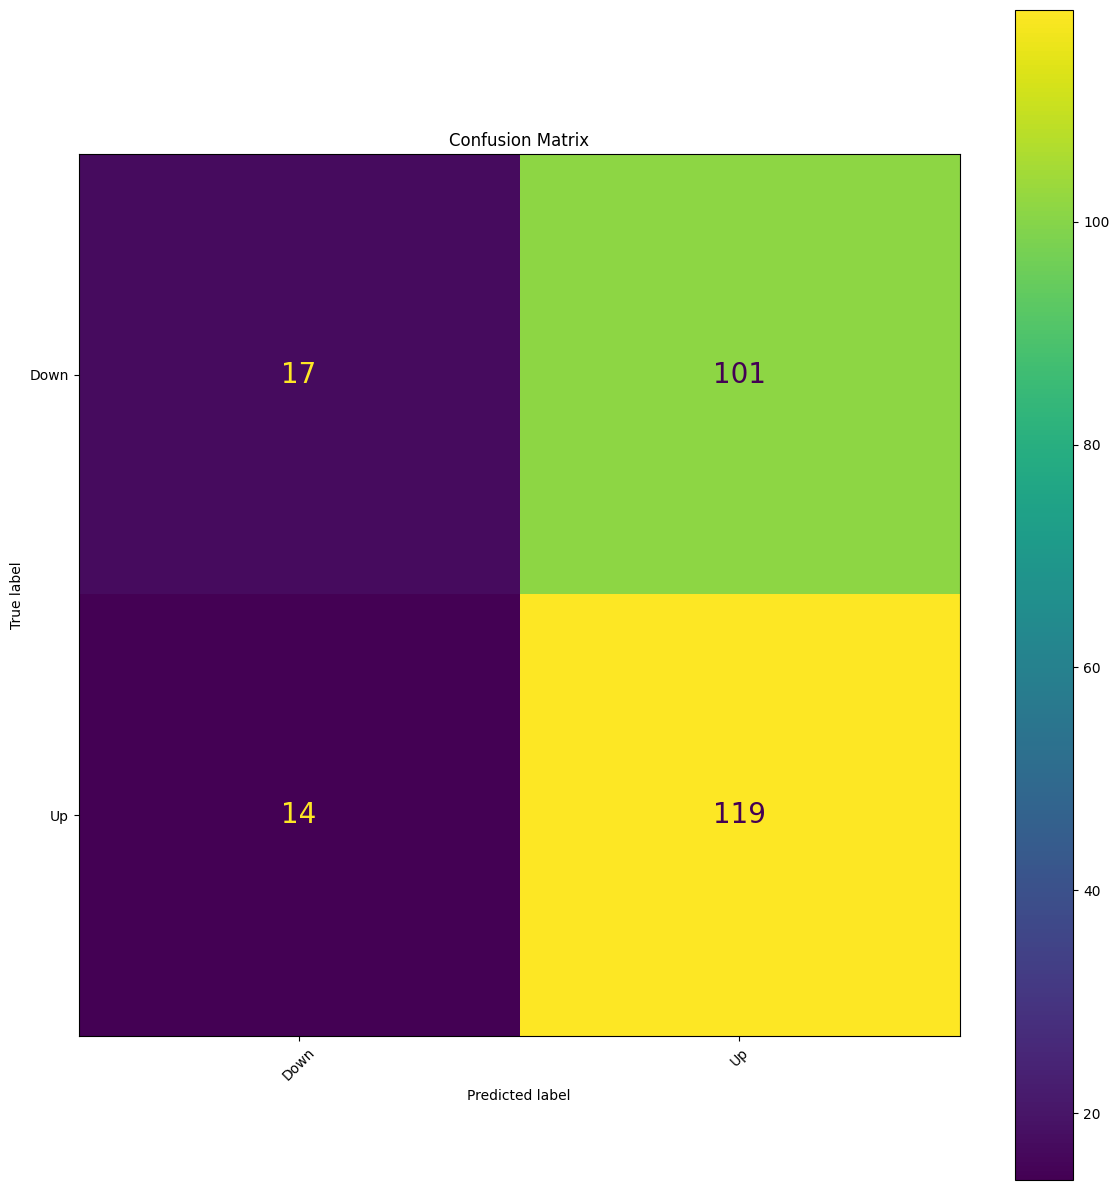

In [80]:
#Logistic Regression for the price dataset
price_lr=LR(max_iter=500, C=1, random_state=42) #Logistic Regression
fit_model_price(price_lr, cleaned_ts_train, cleaned_ts_val)

Next, hyperparameters are specified to optimize the logistic regression's model performance.

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.1s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.1s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.1s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.1s
[CV] END ...............................C=0.1, max_iter=1000; total time=   0.0s
[CV] END ...............................C=0.1, ma

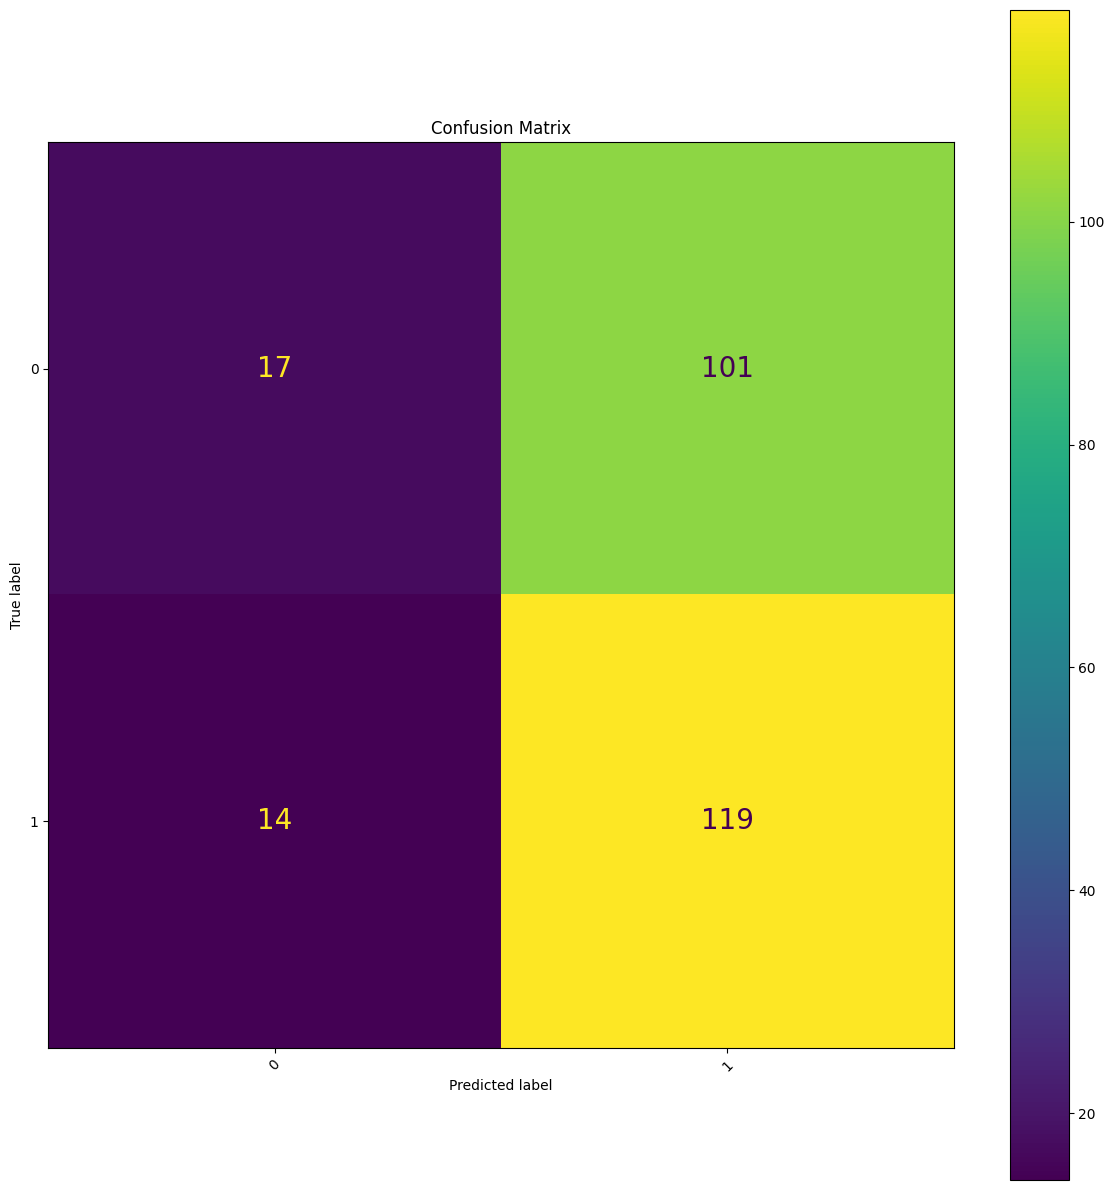

In [81]:
#need to convert categorical target variable to numerical
if (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_ts_train['Stock Price Direction'] = cleaned_ts_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_val['Stock Price Direction']   = cleaned_ts_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_test['Stock Price Direction']   = cleaned_ts_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})


# Define the hyperparameter grid to search
param_grid = {
    'max_iter':[200, 500, 1000],    # number of iterations for model
    'C': [0.1, 1, 5]                # regularization strength
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, pos_label=1)   # or pos_label=1 if encoded
}


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=price_lr, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'f1',
    return_train_score=True,
    verbose=2
)

# Fit to training data
train_X = cleaned_com_train.drop(columns = ['Stock Price Direction'])
train_y = cleaned_com_train['Stock Price Direction']
grid_search.fit(train_X, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_accuracy', ascending=False))


# Best model
best_price_lr = grid_search.best_estimator_

price_lr_tuned = LR(max_iter = grid_search.best_params_['max_iter'],
           C = grid_search.best_params_['C'], 
           random_state = 42
        )

fit_model_price(price_lr_tuned, cleaned_ts_train, cleaned_ts_val)

According to the results, tuning does very little to improve the logisitc regression's performance on the price dataset. 

## Combined Dataset

In [82]:
#Model Selection
def fit_model(model, train_dataset, val_dataset, target_var = 'Stock Price Direction', print_matrix = True):
    '''General function to fit model on training set, evaluate on validation set, and produce confusion matrix'''
    
    train_X = train_dataset.drop(columns = [target_var])
    train_y = train_dataset[target_var]
    val_X = val_dataset.drop(columns = [target_var])
    val_y = val_dataset[target_var]
    
    #Fit model on training dataset
    model.fit(train_X, train_y)

    #Generate predictions and produce accuracy metrics
    my_pred = model.predict(val_X)
    print(f'Model: {model}')
    print(CR(my_pred, val_y))

    #generate confusion matrix
    cm = confusion_matrix(val_y, my_pred, labels=model.classes_)

    #print confusion matrix
    if print_matrix:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
        fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size for readability
        disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)

        for row in disp.text_:
            for text in row:
                text.set_fontsize(20)


        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

Model: LogisticRegression(C=1, l1_ratio=0, max_iter=500, random_state=42)
              precision    recall  f1-score   support

        Down       0.30      0.46      0.36        74
          Up       0.70      0.53      0.61       172

    accuracy                           0.51       246
   macro avg       0.50      0.50      0.48       246
weighted avg       0.58      0.51      0.53       246



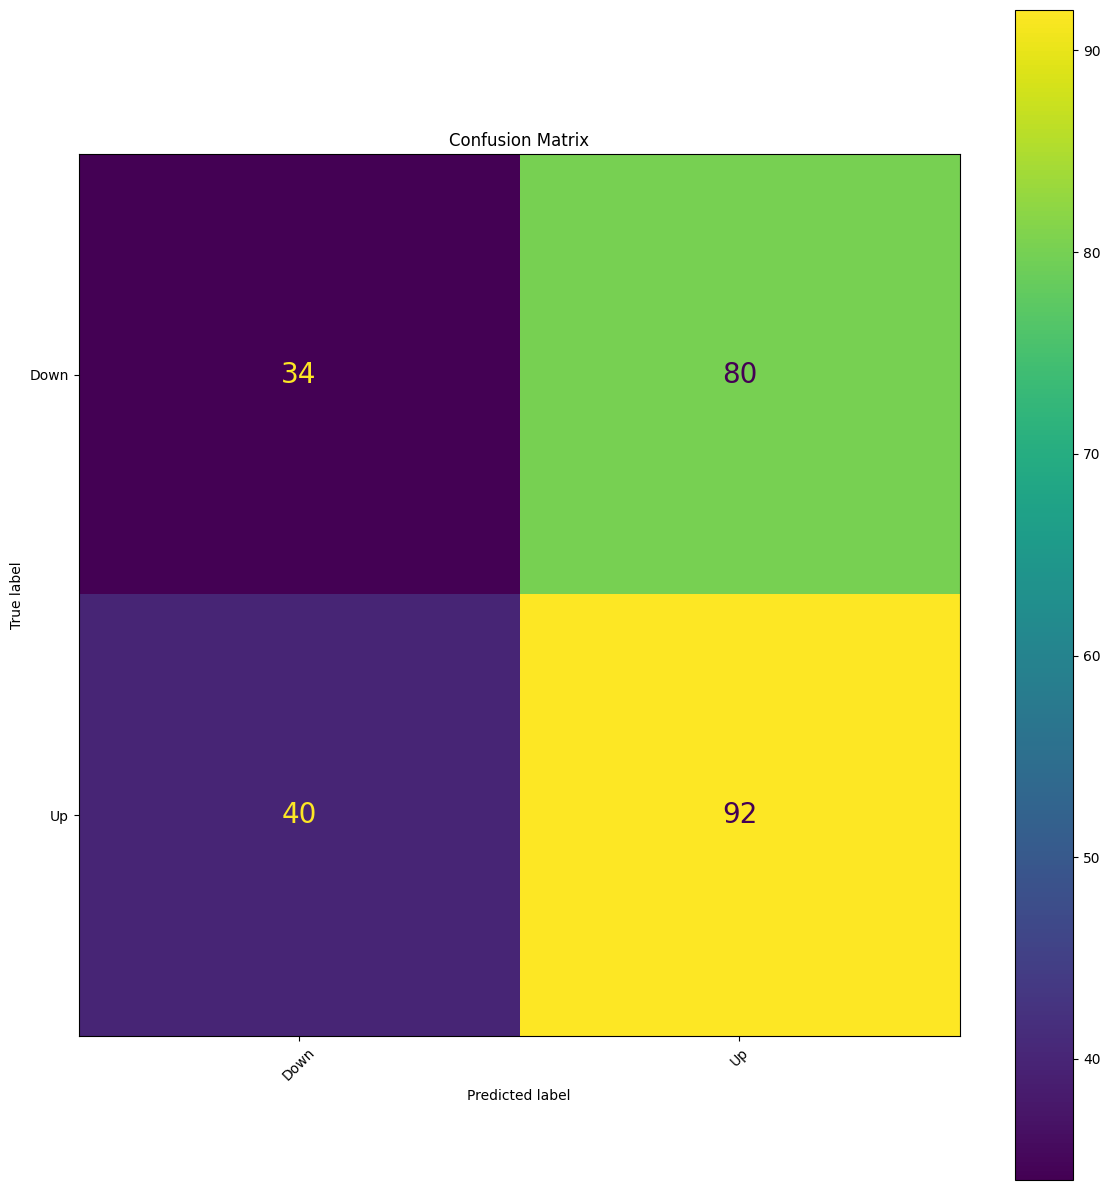

In [83]:
#Logistic Regression for the combined dataset
lr=LR(l1_ratio=0, max_iter=500, C=1, random_state=42) #Logistic Regression
fit_model(lr, cleaned_com_train, cleaned_com_val)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.1s
[CV] END ................................C=0.1, max_iter=200; total time=   0.0s
[CV] END ................................C=0.1, max_iter=200; total time=   0.1s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.1s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ................................C=0.1, max_iter=500; total time=   0.0s
[CV] END ...............................C=0.1, max_iter=1000; total time=   0.0s
[CV] END ...............................C=0.1, ma

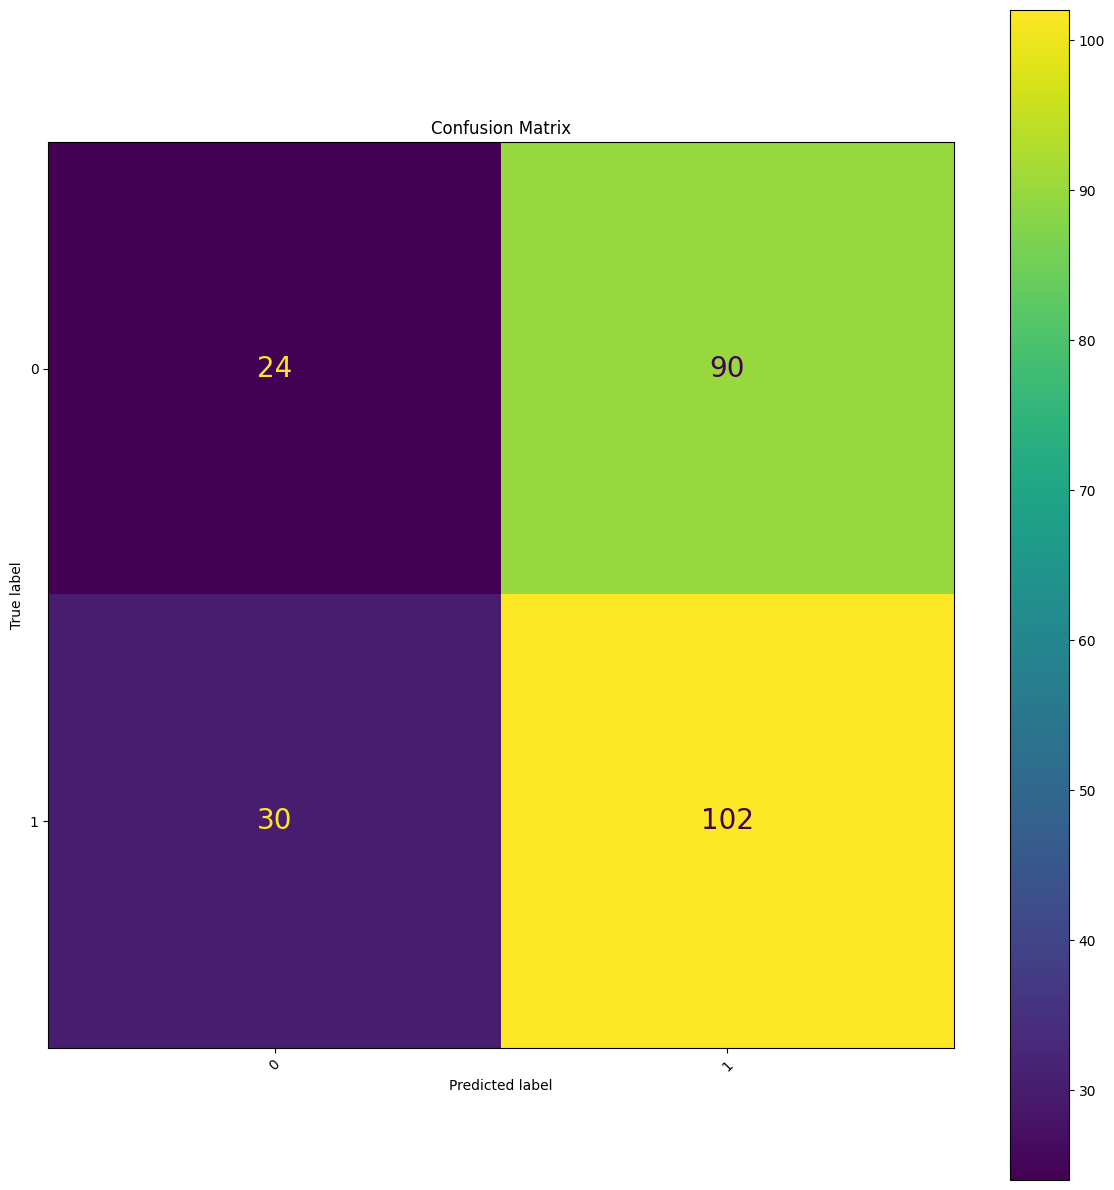

In [84]:
#need to convert categorical target variable to numerical
if (cleaned_com_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_com_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_com_train['Stock Price Direction'] = cleaned_com_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_com_val['Stock Price Direction']   = cleaned_com_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_com_test['Stock Price Direction']   = cleaned_com_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})


# Define the hyperparameter grid to search
param_grid = {
    'max_iter':[200, 500, 1000],    # number of iterations for model
    'C': [0.1, 1, 5]                # regularization strength
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, pos_label=1)   # or pos_label=1 if encoded
}


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=lr, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'f1',
    return_train_score=True,
    verbose=2
)

# Fit to training data
train_X = cleaned_com_train.drop(columns = ['Stock Price Direction'])
train_y = cleaned_com_train['Stock Price Direction']
grid_search.fit(train_X, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_accuracy', ascending=False))


# Best model
best_lr = grid_search.best_estimator_

lr2 = LR(max_iter = grid_search.best_params_['max_iter'],
           C = grid_search.best_params_['C'], 
           random_state = 42
        )

fit_model(lr2, cleaned_com_train, cleaned_com_val)

This model is performing slightly better than 50/50 with 51% accuracy. Our goal at the beginning of the project is 52% accuracy, so this is slightly below. F1 score on the "up" stock price direction is better than "down", this is likely because there were more up days in the training dataset. Precision was much better on the "up" direction than down, and recall was slightly higher for "up".

In [85]:
cleaned_com_train.head(5)

,Stock Price Direction,sentiment_polarity_lag1,sentiment_polarity_lag2,sentiment_polarity_lag3,sentiment_polarity_lag4,sentiment_polarity_lag5,sentiment_pos_lag1,sentiment_pos_lag2,sentiment_pos_lag3,sentiment_pos_lag4,...,sentiment_neu_lag5,sentiment_neg_lag1,sentiment_neg_lag2,sentiment_neg_lag3,sentiment_neg_lag4,sentiment_neg_lag5,aapl_price_direction_lag1,aapl_price_direction_lag2,aapl_price_direction_lag3,aapl_price_direction_lag4
5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1
7,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1
8,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0
9,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0


# Week 7 - Support Vector Machine (SVM)

## Sentiment Dataset


Accuracy: 0.5259

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.14      0.21       118
      Up (1)       0.53      0.87      0.66       133

    accuracy                           0.53       251
   macro avg       0.51      0.50      0.44       251
weighted avg       0.51      0.53      0.45       251


Confusion Matrix:


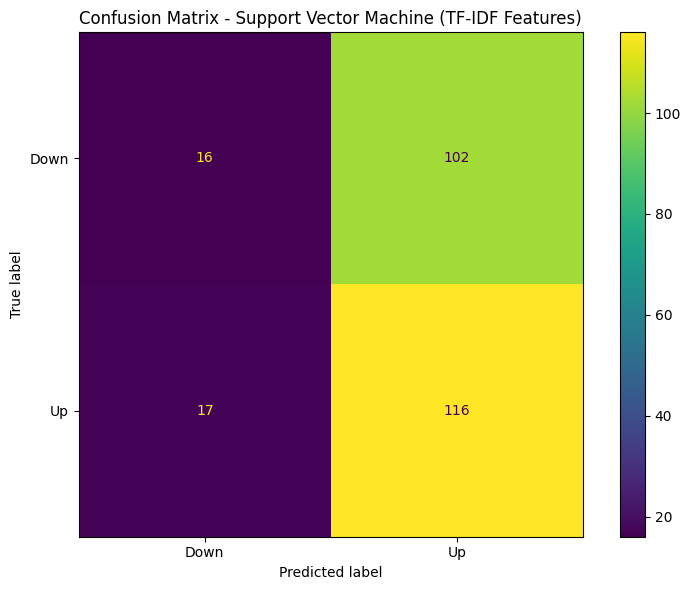

In [86]:
# Base SVM for Sentiment Dataset
svm_sentiment = SVC(kernel='linear', C=1, random_state=42)
svm_sentiment.fit(X_train_combined, y_train_sentiment)

# Make predictions on validation set
y_pred_svm = svm_sentiment.predict(X_val_combined)

# Accuracy
accuracy = accuracy_score(y_val_sentiment, y_pred_svm)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(CR(y_val_sentiment, y_pred_svm, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val_sentiment, y_pred_svm, labels=svm_sentiment.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Support Vector Machine (TF-IDF Features)")
plt.tight_layout()
plt.show()

In [87]:
# Define the hyperparameter grid for SVM
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'kernel': ['linear', 'rbf'],      # Kernel type
    'gamma': ['scale', 'auto']        # Kernel coefficient for 'rbf'
}

# Define scoring metrics for GridSearchCV
scoring_svm = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score, pos_label=1)
}

# Initialize the SVM model
svm_model = SVC(max_iter=5000,random_state=42)

# Set up GridSearchCV with cross-validation
grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,                              # 5-fold cross-validation
    scoring=scoring_svm,
    refit='f1',                       # Refit using F1 score
)

# Fit grid search on training data
print("Starting Grid Search for Support Vector Machine on Sentiment TF-IDF Features...")
grid_search_svm.fit(X_train_combined, y_train_sentiment)

Starting Grid Search for Support Vector Machine on Sentiment TF-IDF Features...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(max_iter=...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f..., pos_label=1)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

Best Hyperparameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
                                               params  mean_test_accuracy  \
0   {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}            0.528348   
1      {'C': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}            0.528348   
2    {'C': 0.01, 'gamma': 'auto', 'kernel': 'linear'}            0.528348   
3       {'C': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
4    {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}            0.528348   
5       {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}            0.528348   
6     {'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}            0.528348   
7        {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
11         {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
15        {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}            0.528348   
9         {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}            0.511064   
12  

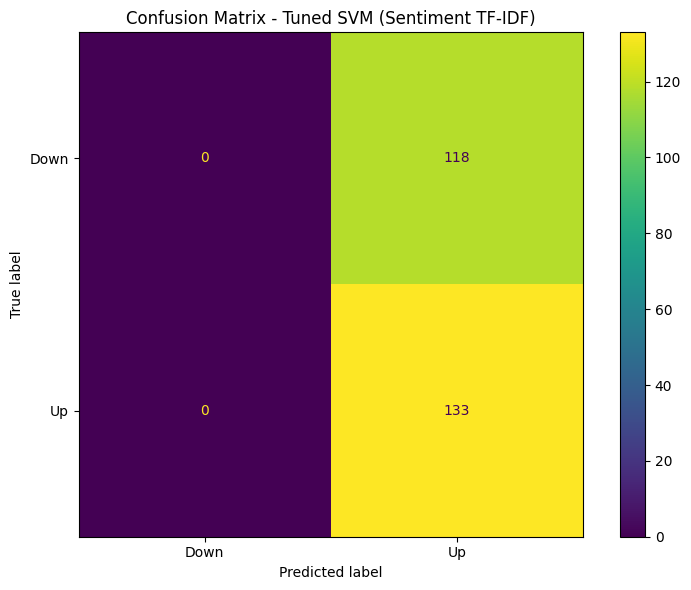

In [88]:
# Display best hyperparameters and cross-validation results
print("Best Hyperparameters:", grid_search_svm.best_params_)

# Print performance metrics for cross-fold validation
results_df = pd.DataFrame(grid_search_svm.cv_results_)
summary = results_df[['params', 'mean_test_accuracy', 'mean_test_f1']]
print(summary.sort_values(by='mean_test_f1', ascending=False))

# Get the best estimator from grid search
best_sentiment_svm = grid_search_svm.best_estimator_

# Evaluate best model on validation set
y_pred_val = best_sentiment_svm.predict(X_val_combined)

print("\n--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(y_val_sentiment, y_pred_val):.4f}")
print("\nClassification Report:")
print(CR(y_val_sentiment, y_pred_val, target_names=['Down (0)', 'Up (1)']))

# Confusion Matrix
cm = confusion_matrix(y_val_sentiment, y_pred_val, labels=best_sentiment_svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Tuned SVM (Sentiment TF-IDF)")
plt.tight_layout()
plt.show()

## Price Dataset

Baseline SVM model with RBF kernel.

Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(class_weight='balanced', random_state=42))])
              precision    recall  f1-score   support

           0       0.61      0.44      0.51       163
           1       0.32      0.48      0.38        88

    accuracy                           0.45       251
   macro avg       0.46      0.46      0.45       251
weighted avg       0.51      0.45      0.47       251



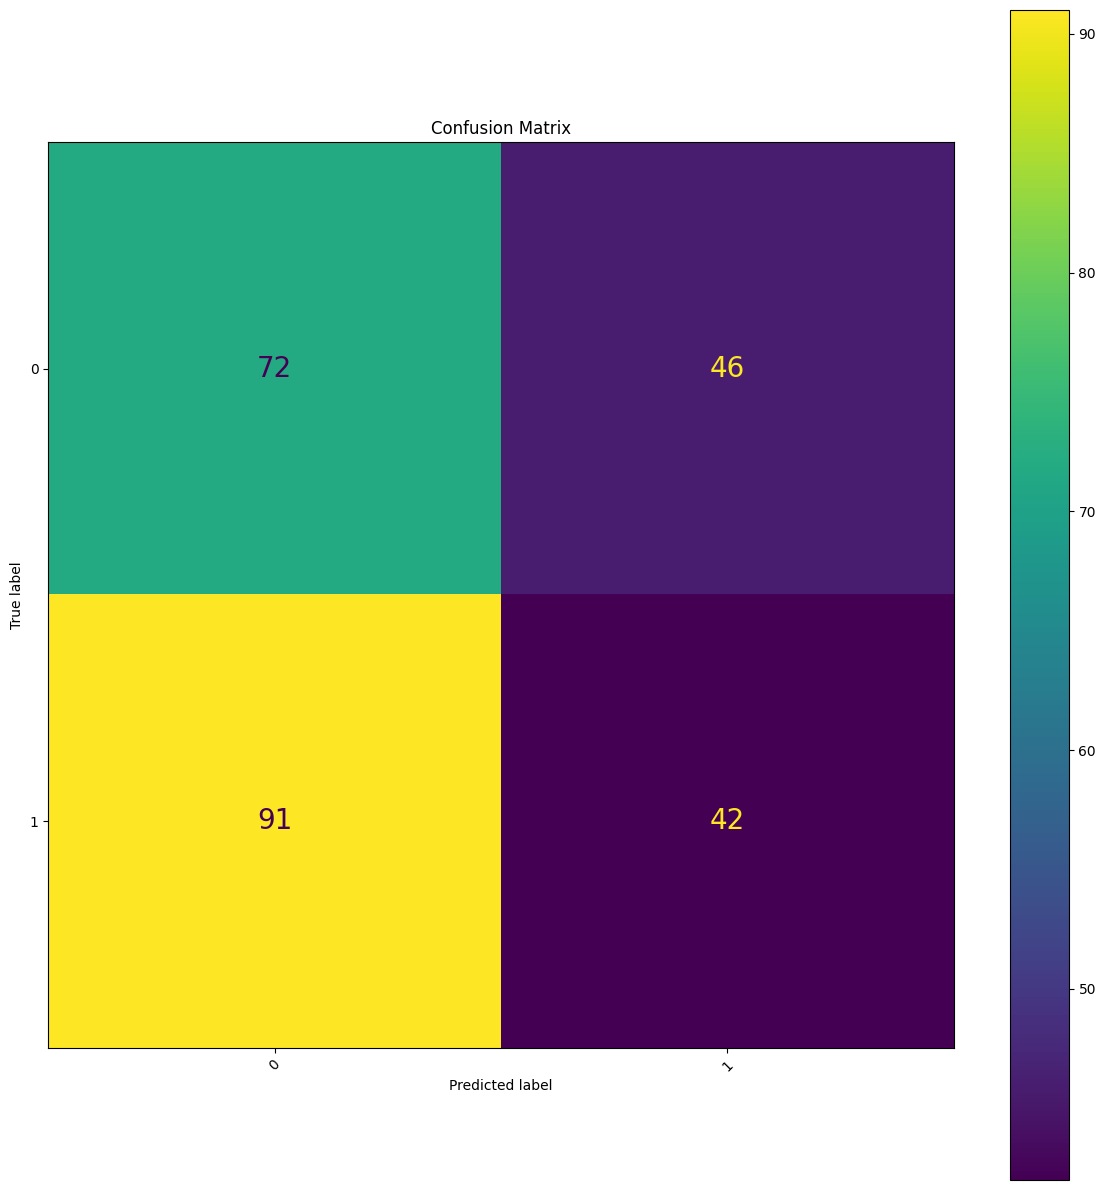

In [89]:
# Support Vector Machine for Price Prediction
price_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

fit_model_price(price_svm, cleaned_ts_train, cleaned_ts_val)

Grid search to tune hyperparameters and find optimal combination.

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   0.0s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   0.0s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   0.0s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   0.0s
[CV] END ...svm__C=0.1, svm__gamma=scale, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.1s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.1s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.1s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.1s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.1s
[CV] END ....svm__C=0.1, svm__gamma=auto, svm__kernel=linear; total time=   0.0s
[CV] END ....svm__C=0.1, svm__gamma=auto, svm__k

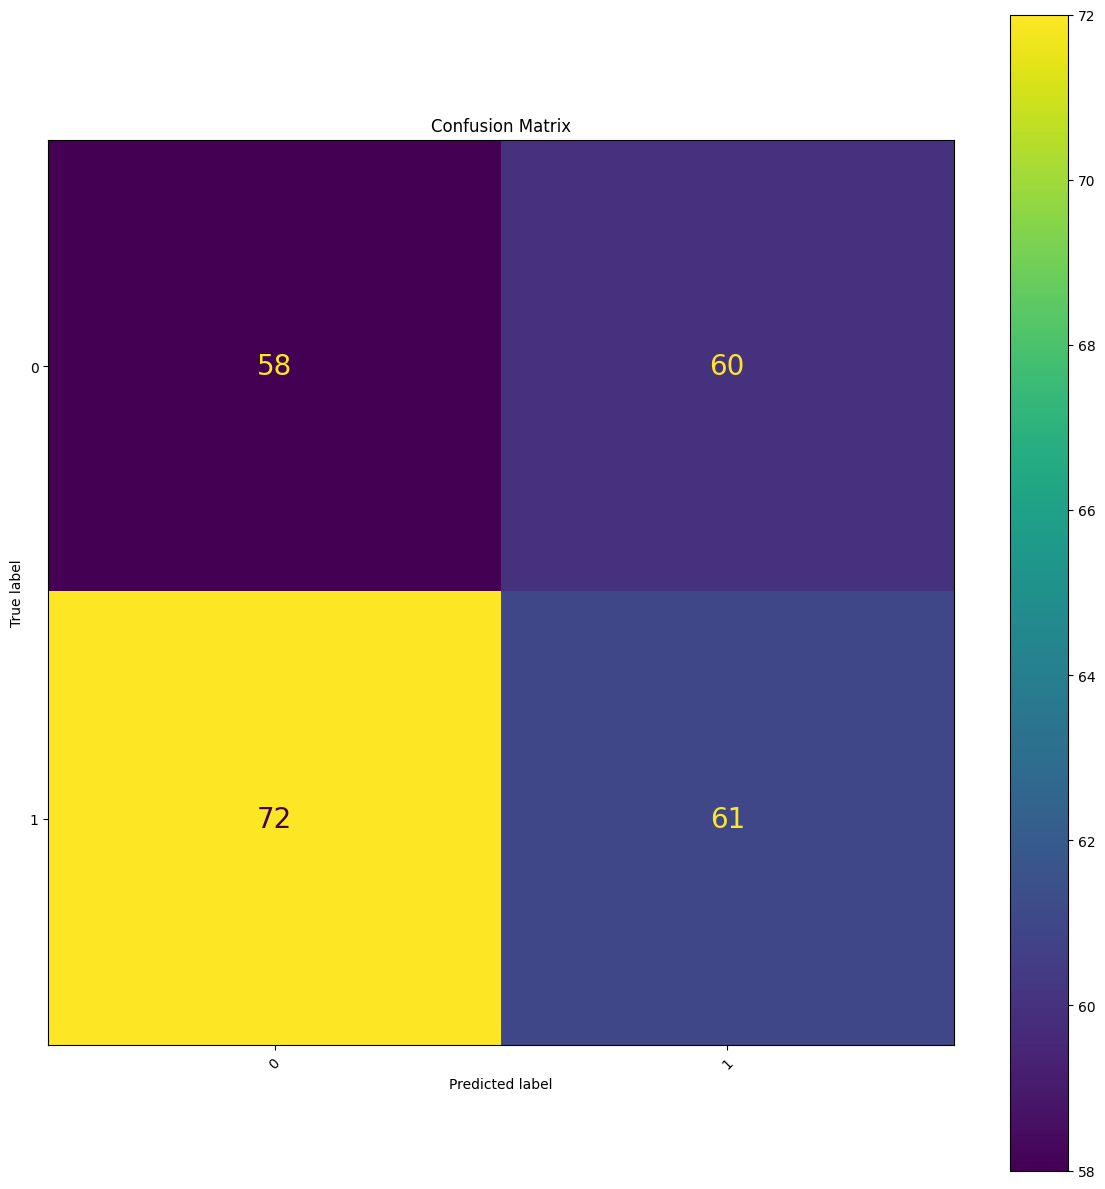

In [90]:
# Convert categorical target variable to numerical
if (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_ts_train['Stock Price Direction'] = cleaned_ts_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_val['Stock Price Direction']   = cleaned_ts_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_test['Stock Price Direction']  = cleaned_ts_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})

# Define the hyperparameter grid for SVM
param_grid = {
    'svm__C':      [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 'auto']
}

# Define scoring metrics for GridSearchCV
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score, pos_label=1)
}

# Create a pipeline for SVM with scaling
price_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

# Set up GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=price_svm,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit='f1',
    return_train_score=True,
    verbose=2
)

# Fit the grid search on the training data
price_train_X = cleaned_ts_train.drop(columns=['Stock Price Direction', 'Dates'])
price_train_y = cleaned_ts_train['Stock Price Direction']
grid_search.fit(price_train_X, price_train_y)

# Display best hyperparameters and cross-validation results
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_f1', ascending=False))

best_price_svm = grid_search.best_estimator_

price_svm_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=grid_search.best_params_['svm__C'],
        kernel=grid_search.best_params_['svm__kernel'],
        gamma=grid_search.best_params_['svm__gamma'],
        class_weight='balanced',
        random_state=42
    ))
])

fit_model_price(price_svm_tuned, cleaned_ts_train, cleaned_ts_val)

## Combined Dataset

Model: Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(random_state=42))])
              precision    recall  f1-score   support

           0       0.11      0.57      0.19        23
           1       0.92      0.55      0.69       223

    accuracy                           0.55       246
   macro avg       0.52      0.56      0.44       246
weighted avg       0.85      0.55      0.64       246



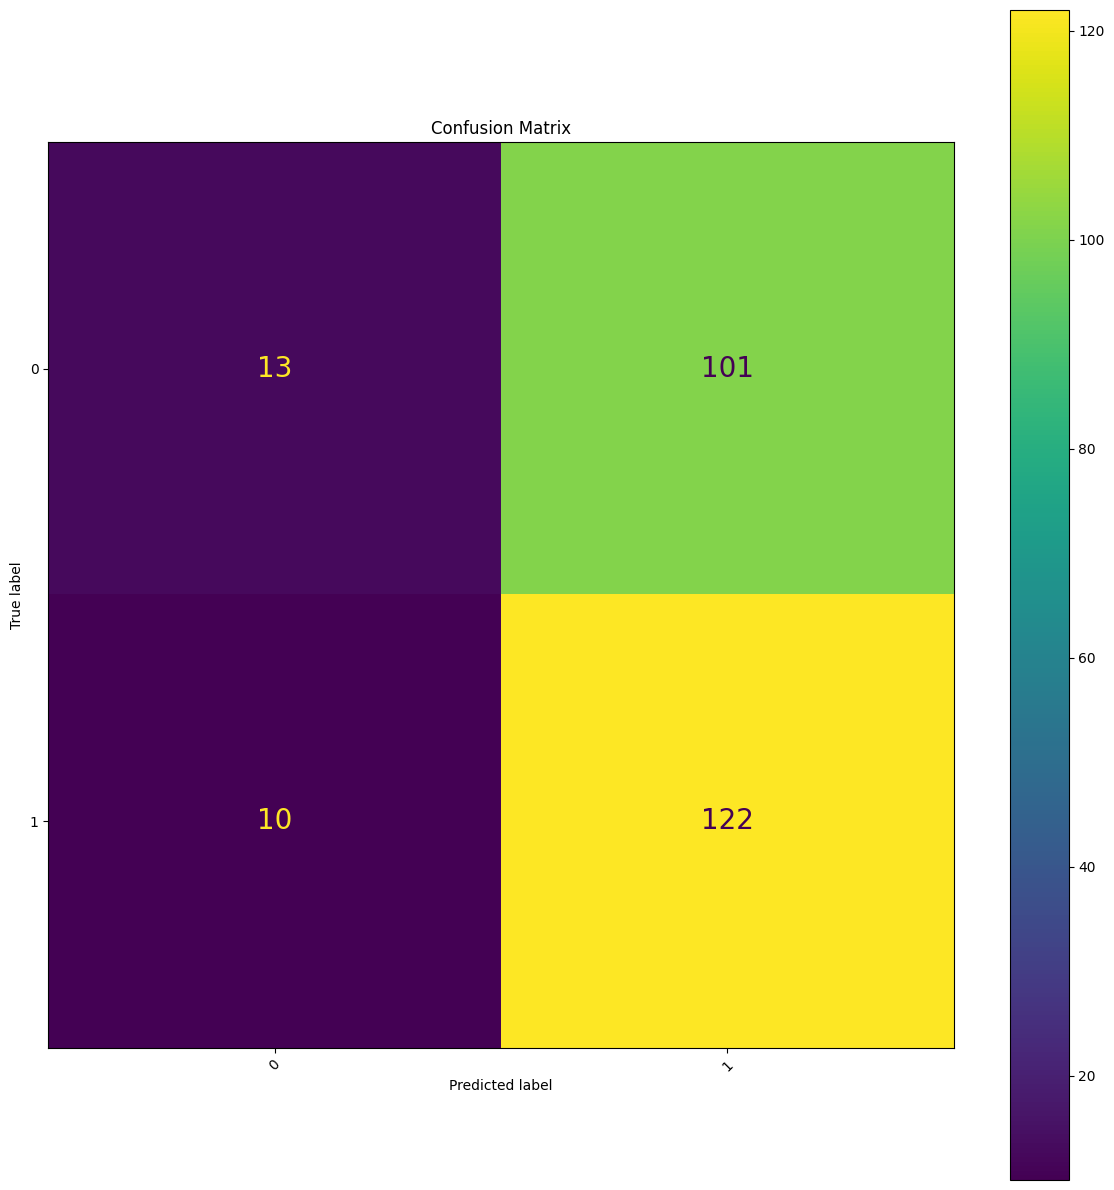

In [91]:
# Support Vector Machine for Combined Dataset
svm = SVC(random_state=42)
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

fit_model(svm, cleaned_com_train, cleaned_com_val)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=1000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=1000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=1000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=1000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=1000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=2000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=2000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=2000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linear, svc__max_iter=2000; total time=   0.0s
[CV] END svc__C=0.1, svc__gamma=scale, svc__kernel=linea

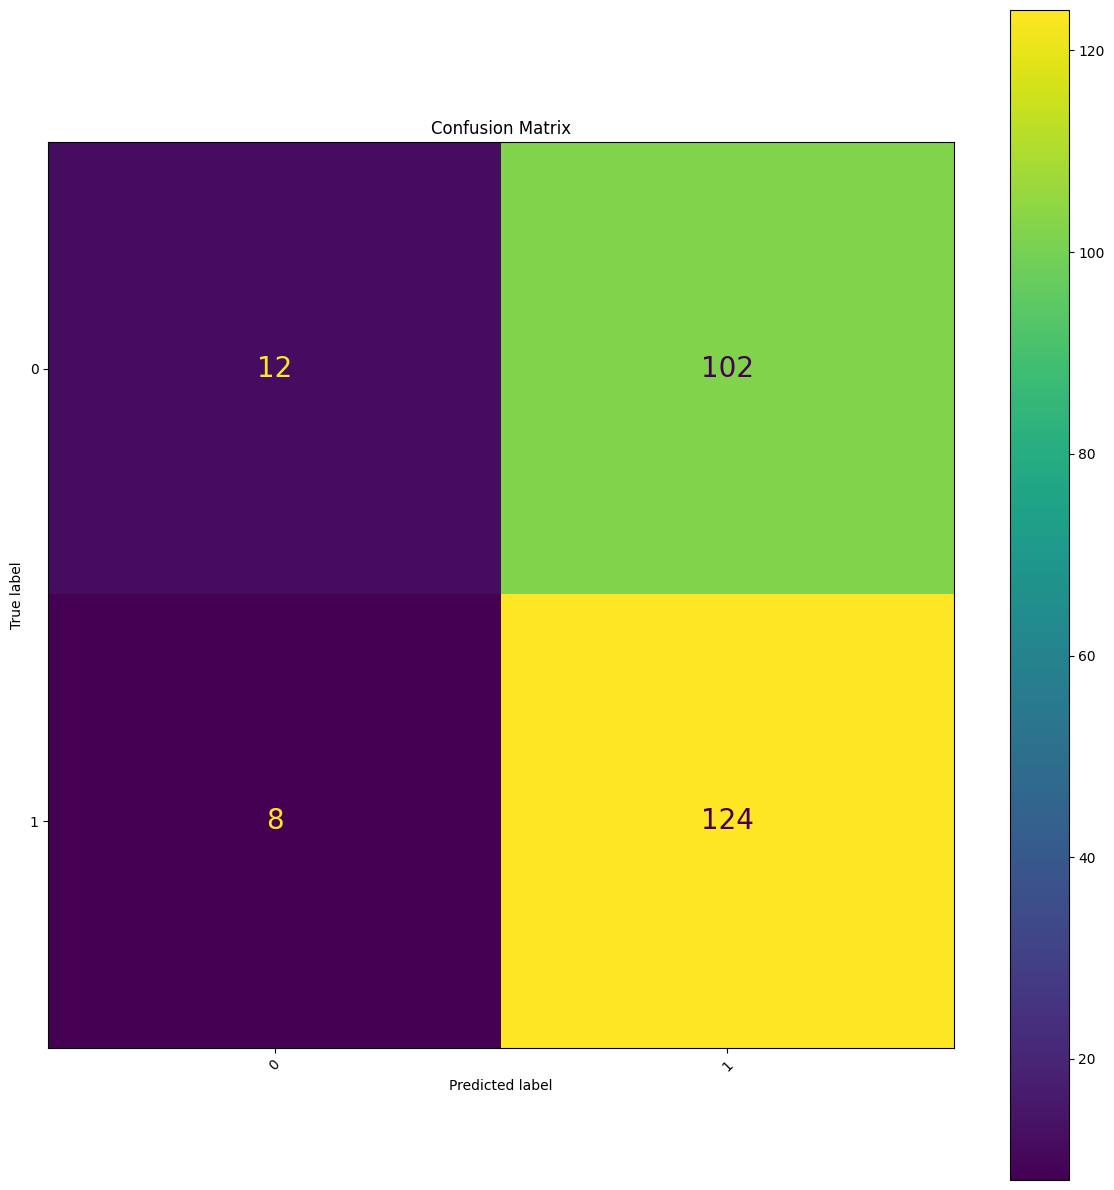

In [92]:
# Define the hyperparameter grid to search
param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'svc__C': [0.1, 1, 5],
    'svc__gamma': ['scale', 'auto'],
    'svc__max_iter': [1000, 2000]
}


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'accuracy',
    return_train_score=True,
    verbose=2
)

# Fit to training data
cleaned_com_train_df = pd.DataFrame(cleaned_com_train)
grid_search.fit(cleaned_com_train_df, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_accuracy', ascending=False))


# Best model
best_svm = grid_search.best_estimator_

fit_model(best_svm, cleaned_com_train, cleaned_com_val)

# Week 8 - Third Model

## Sentiment Dataset

In [93]:
# Define the model name for FinBERT
MODEL_NAME = "ProsusAI/finbert"

# Load the tokenizer and model from Hugging Face Transformers
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
finbert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
finbert_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [94]:
# Function to get sentiment probabilities from FinBERT for a given text input
def finbert_sentiment_probs(text, max_length=512):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    with torch.no_grad():
        outputs = finbert_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).numpy()[0]
    labels = [finbert_model.config.id2label[i] for i in range(len(probs))]
    return dict(zip(labels, probs))

In [95]:
# Apply the function to the 'full_text' column of the training dataset to get sentiment probabilities
scores = Final_Raw_X_train["full_text"].fillna("").apply(finbert_sentiment_probs)

# Convert the list of dictionaries into a DataFrame and rename columns to indicate they are from FinBERT
score_sentiment = scores.apply(pd.Series)
score_sentiment.columns = [f"finbert_{c.lower()}" for c in score_sentiment.columns]

# Combine the original training dataset with the new FinBERT sentiment scores
finbert_df = pd.concat([Final_Raw_X_train, score_sentiment], axis=1)
finbert_df["finbert_polarity"] = finbert_df["finbert_positive"] - finbert_df["finbert_negative"]
finbert_df["finbert_confidence"] = finbert_df[[
    "finbert_positive", "finbert_negative", "finbert_neutral"
]].max(axis=1)

In [96]:
finbert_df.head(10)

,Dates,AAPL Share Price,full_text,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_polarity,tokens,Stock Price Direction,finbert_positive,finbert_negative,finbert_neutral,finbert_polarity,finbert_confidence
0,2018-01-02,43.07,,0.0,0.0,0.0,0.0,NaN,down,0.359163,0.216652,0.424185,0.142512,0.424185
1,2018-01-03,43.06,,0.0,0.0,0.0,0.0,NaN,down,0.359163,0.216652,0.424185,0.142512,0.424185
2,2018-01-04,43.26,,0.0,0.0,0.0,0.0,NaN,up,0.359163,0.216652,0.424185,0.142512,0.424185
3,2018-01-05,43.75,,0.0,0.0,0.0,0.0,NaN,up,0.359163,0.216652,0.424185,0.142512,0.424185
4,2018-01-08,43.59,,0.0,0.0,0.0,0.0,NaN,down,0.359163,0.216652,0.424185,0.142512,0.424185
5,2018-01-09,43.58,,0.0,0.0,0.0,0.0,NaN,down,0.359163,0.216652,0.424185,0.142512,0.424185
6,2018-01-10,43.57,,0.0,0.0,0.0,0.0,NaN,down,0.359163,0.216652,0.424185,0.142512,0.424185
7,2018-01-11,43.82,,0.0,0.0,0.0,0.0,NaN,up,0.359163,0.216652,0.424185,0.142512,0.424185
8,2018-01-12,44.27,,0.0,0.0,0.0,0.0,NaN,up,0.359163,0.216652,0.424185,0.142512,0.424185
9,2018-01-16,44.05,,0.0,0.0,0.0,0.0,NaN,down,0.359163,0.216652,0.424185,0.142512,0.424185


In [97]:
# Repeat the same process for the validation set
# Apply the function to the 'full_text' column of the validation dataset to get sentiment probabilities
scores_val = Final_Raw_X_val["full_text"].fillna("").apply(finbert_sentiment_probs)

# Convert the list of dictionaries into a DataFrame and rename columns to indicate they are from FinBERT
score_sentiment_val = scores_val.apply(pd.Series)
score_sentiment_val.columns = [f"finbert_{c.lower()}" for c in score_sentiment_val.columns]

# Combine the original validation dataset with the new FinBERT sentiment scores
finbert_val_df = pd.concat([Final_Raw_X_val, score_sentiment_val], axis=1)
finbert_val_df["finbert_polarity"] = finbert_val_df["finbert_positive"] - finbert_val_df["finbert_negative"]
finbert_val_df["finbert_confidence"] = finbert_val_df[["finbert_positive", "finbert_negative", "finbert_neutral"]].max(axis=1)

In [98]:
# Define the list of FinBERT feature columns for later use in modeling
full_finbert_feature_cols = [
    "finbert_positive", "finbert_negative", "finbert_neutral",
    "finbert_polarity", "finbert_confidence",
    "sentiment_pos", "sentiment_neg", "sentiment_neu", "sentiment_polarity"
]

In [99]:
# Prepare the training data for modeling
X_train_finbert1 = finbert_df[full_finbert_feature_cols]
y_train_finbert1 = finbert_df["Stock Price Direction"].map({"up": 1, "down": 0})
# Prepare the validation data for modeling
X_val_finbert1 = finbert_val_df[full_finbert_feature_cols]
y_val_finbert1 = finbert_val_df["Stock Price Direction"].map({"up": 1, "down": 0})

In [100]:
# Initialize and fit the logistic regression model
finbert_lr = LR(max_iter=500, C=1, random_state=42)
finbert_lr.fit(X_train_finbert1, y_train_finbert1)

# Make predictions on the validation set
y_pred_finbert = finbert_lr.predict(X_val_finbert1)
# Evaluate the model
print("Logistic Regression - FinBERT Sentiment Features Results")
# Accuracy
finbert_accuracy = accuracy_score(y_val_finbert1, y_pred_finbert)
print(f"\nAccuracy: {finbert_accuracy:.4f}")
# Classification Report (Precision, Recall, F1-Score, Support)
print("\nClassification Report:")
print(CR(y_val_finbert1, y_pred_finbert, target_names=['Down (0)', 'Up (1)']))

Logistic Regression - FinBERT Sentiment Features Results

Accuracy: 0.5578

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.56      0.26      0.36       118
      Up (1)       0.56      0.82      0.66       133

    accuracy                           0.56       251
   macro avg       0.56      0.54      0.51       251
weighted avg       0.56      0.56      0.52       251




Confusion Matrix:


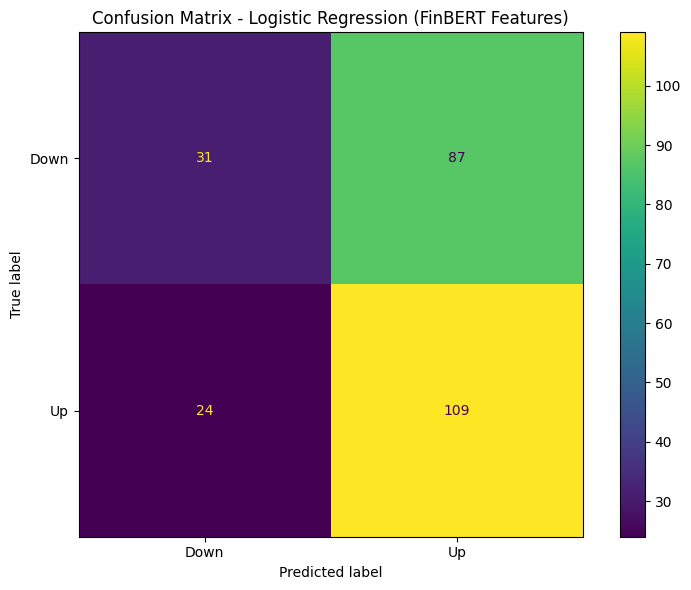

In [101]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val_finbert1, y_pred_finbert, labels=finbert_lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression (FinBERT Features)")
plt.tight_layout()
plt.show()

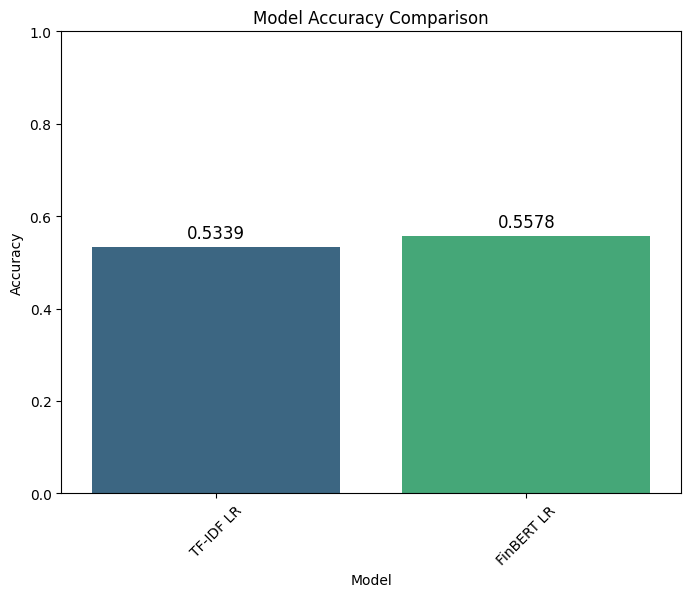

In [102]:
# Compare the performance of the FinBERT-based model to the previous models using a bar chart
model_names = ['TF-IDF LR', 'FinBERT LR']
accuracies = [accuracy_score(y_val_sentiment, y_pred_combined), accuracy_score(y_val_finbert1, y_pred_finbert)]
plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=45)
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f"{value:.4f}", ha='center', va='bottom', fontsize=12)

In [103]:
# Grid search on logistic regression for FinBERT + sentiment features

X_train_finbert_lr = X_train_finbert1.copy()
y_train_finbert_lr = y_train_finbert1.copy()
X_val_finbert_lr = X_val_finbert1.copy()
y_val_finbert_lr = y_val_finbert1.copy()

param_grid_lr = [
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'class_weight': [None, 'balanced']
    },
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1'],
        'solver': ['saga'],
        'class_weight': [None, 'balanced']
    },
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'class_weight': [None, 'balanced']
    }
]

grid_search_lr = GridSearchCV(
    LR(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1',
    return_train_score=True,
    verbose=2
)

grid_search_lr.fit(X_train_finbert_lr, y_train_finbert_lr)

print("Best Hyperparameters (Logistic Regression):", grid_search_lr.best_params_)

results_lr = pd.DataFrame(grid_search_lr.cv_results_)
summary_lr = results_lr[['params', 'mean_test_score', 'mean_train_score']]
print(summary_lr.sort_values(by='mean_test_score', ascending=False).head(10))

best_lr = grid_search_lr.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.1s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.1s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END .C=0.01, class_weight=None, penalty=l2, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, pen


Logistic Regression GridSearch Results on Validation Set
Accuracy: 0.5418
Classification Report:
               precision    recall  f1-score   support

    Down (0)       0.54      0.16      0.25       118
      Up (1)       0.54      0.88      0.67       133

    accuracy                           0.54       251
   macro avg       0.54      0.52      0.46       251
weighted avg       0.54      0.54      0.47       251



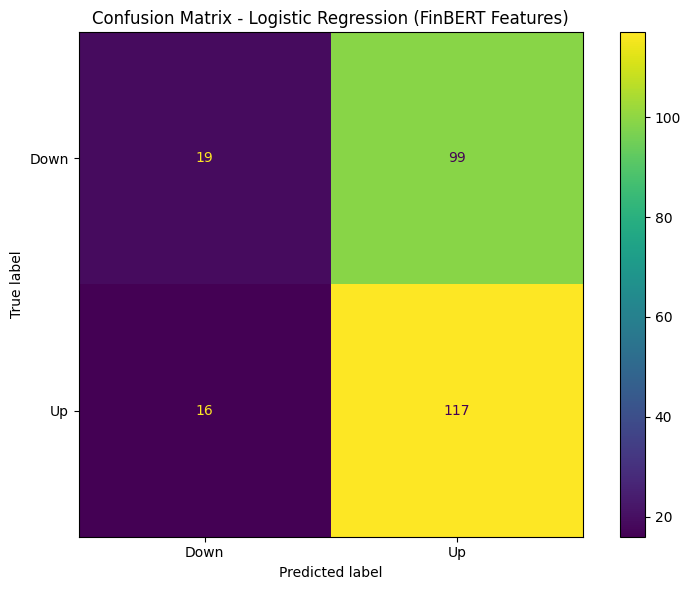

In [104]:
# Validation performance with best LR model
y_pred_val_lr = best_lr.predict(X_val_finbert_lr)

print("\nLogistic Regression GridSearch Results on Validation Set")
print(f"Accuracy: {accuracy_score(y_val_finbert_lr, y_pred_val_lr):.4f}")
print("Classification Report:\n", CR(y_val_finbert_lr, y_pred_val_lr, target_names=['Down (0)', 'Up (1)']))

cm_lr = confusion_matrix(y_val_finbert_lr, y_pred_val_lr, labels=best_lr.classes_)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Down', 'Up'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_lr.plot(ax=ax, cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression (FinBERT Features)")
plt.tight_layout()
plt.show()

## Historical Price Dataset

Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.36      0.40      0.38       107
           1       0.52      0.48      0.50       144

    accuracy                           0.45       251
   macro avg  

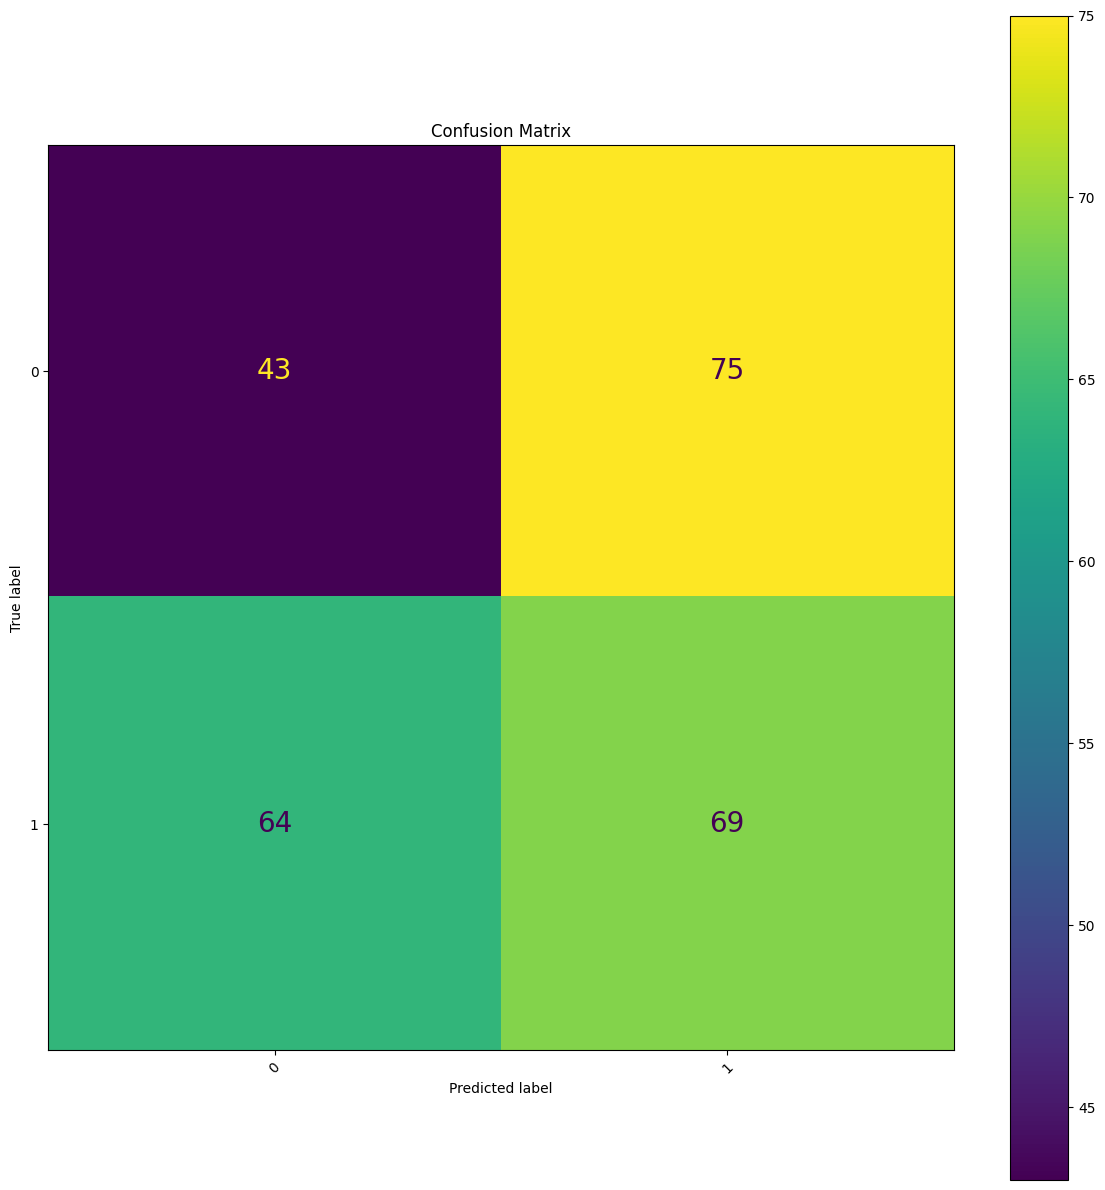

In [105]:
# Initial XGBoost model
xgb_model = XGBClassifier(random_state=42)

fit_model_price(xgb_model, cleaned_ts_train, cleaned_ts_val)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.0s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.1

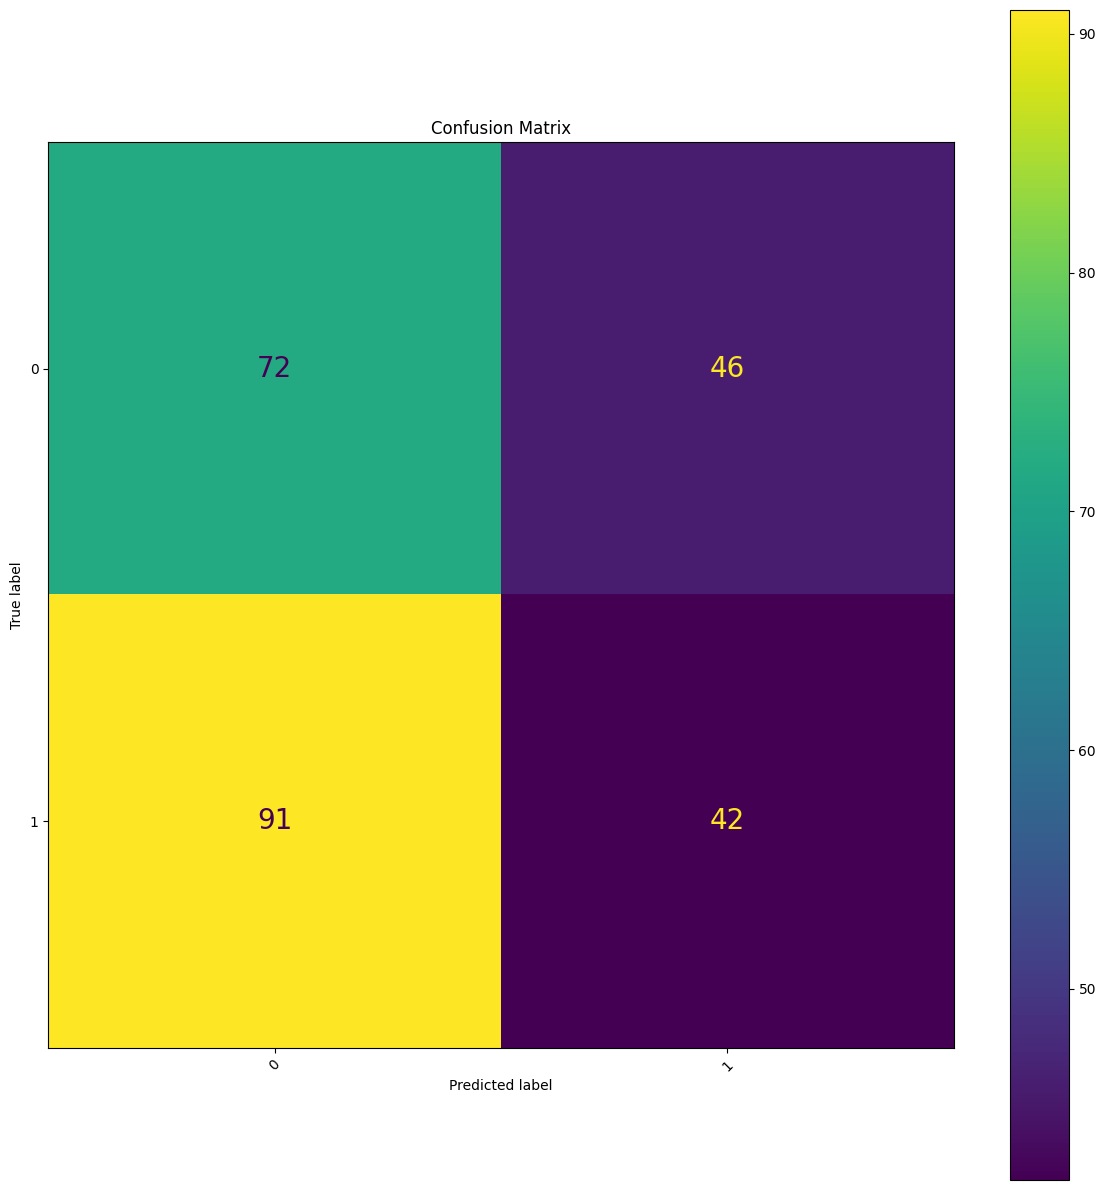

In [106]:
# Grid Search for hyperparamter tuning
if (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Down') | (cleaned_ts_train.loc[5, 'Stock Price Direction'] == 'Up'):
    cleaned_ts_train['Stock Price Direction'] = cleaned_ts_train['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_val['Stock Price Direction']   = cleaned_ts_val['Stock Price Direction'].map({'Down': 0, 'Up': 1})
    cleaned_ts_test['Stock Price Direction']  = cleaned_ts_test['Stock Price Direction'].map({'Down': 0, 'Up': 1})

param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1':       make_scorer(f1_score, pos_label=1)
}

price_xgb = Pipeline([
    ('xgb', XGBClassifier(
        scale_pos_weight=len(train_y[train_y==0]) / len(train_y[train_y==1]),  # replaces class_weight='balanced'
        eval_metric='logloss',
        random_state=42
    ))
])

grid_search = RandomizedSearchCV(
    estimator=price_xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring=scoring,
    refit='f1',
    return_train_score=True,
    random_state=42,
    verbose=2
)

price_train_X = cleaned_ts_train.drop(columns=['Stock Price Direction', 'Dates'])
price_train_y = cleaned_ts_train['Stock Price Direction']
grid_search.fit(price_train_X, price_train_y)

print("Best Hyperparameters:", grid_search.best_params_)

results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_f1', ascending=False))

price_xgb_tuned = Pipeline([
    ('xgb', XGBClassifier(
        n_estimators=grid_search.best_params_['xgb__n_estimators'],
        max_depth=grid_search.best_params_['xgb__max_depth'],
        learning_rate=grid_search.best_params_['xgb__learning_rate'],
        scale_pos_weight=len(price_train_y[price_train_y==0]) / len(price_train_y[price_train_y==1]),
        eval_metric='logloss',
        random_state=42
    ))
])

fit_model_price(price_xgb_tuned, cleaned_ts_train, cleaned_ts_val)

## Combined Dataset

Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.50      0.49      0.49       117
           1       0.55      0.56      0.55       129

    accuracy                           0.52       246
   macro avg  

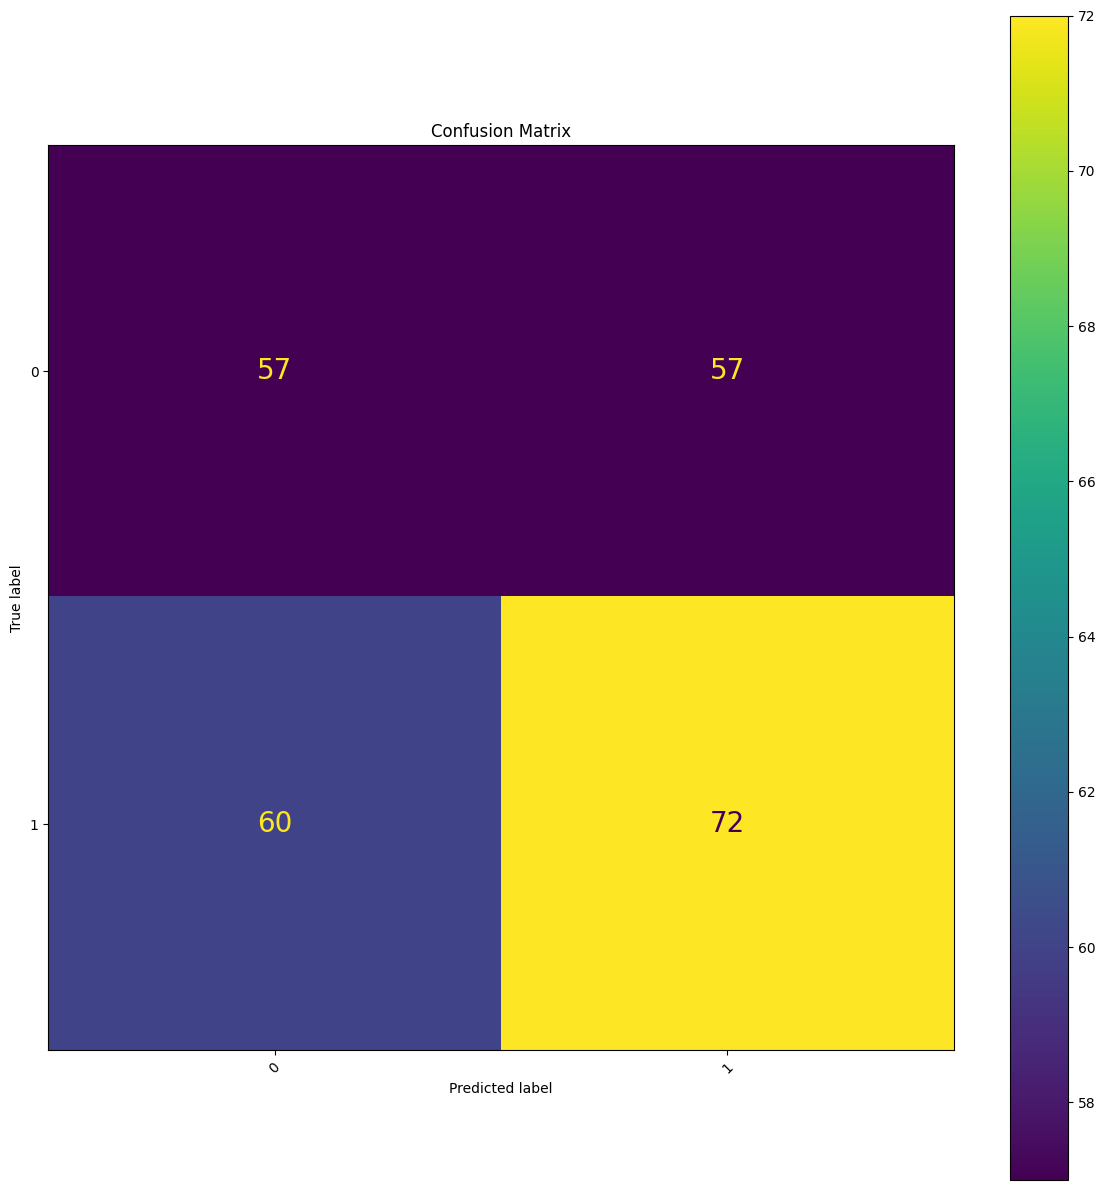

In [107]:
# XGBoost for Combined Dataset
xgb_boost = XGBClassifier(random_state=42)

fit_model(xgb_boost, cleaned_com_train, cleaned_com_val)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=100; total time=   0.1s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.2s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.2s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.2s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.2s
[CV] END xgb__learning_rate=0.01, xgb__max_depth=3, xgb__n_estimators=400; total time=   0.2

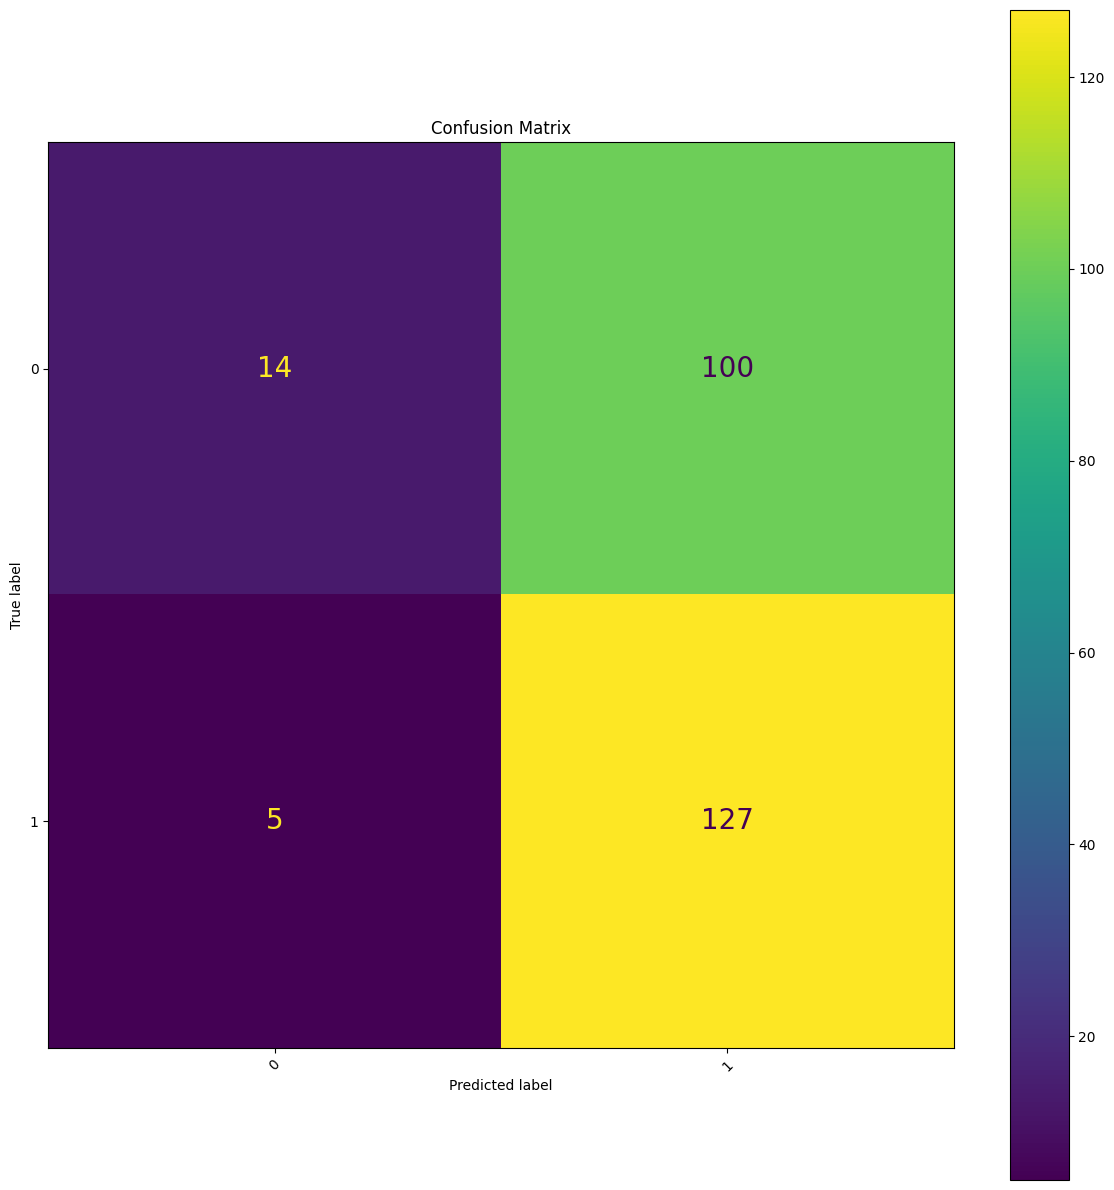

In [108]:
# Define the hyperparameter grid to search

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(eval_metric='logloss'))
])

param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, pos_label=1)   # or pos_label=1 if encoded
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=param_grid, 
    cv = cv,                 # 5-fold cross-validation 
    scoring=scoring,   # print f1 and accuracy
    refit = 'accuracy',
    return_train_score=True,
    verbose=2
)

# Fit to training data
cleaned_com_train_df = pd.DataFrame(cleaned_com_train)
grid_search.fit(cleaned_com_train_df, train_y)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Print performance metrics for cross-fold validation
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
results = pd.DataFrame(grid_search.cv_results_)
summary = results[['params', 'mean_test_accuracy', 'mean_test_f1', 'mean_train_accuracy', 'mean_train_f1']]
print(summary.sort_values(by='mean_test_accuracy', ascending=False))


# Best model
best_xgb = grid_search.best_estimator_

fit_model(best_xgb, cleaned_com_train, cleaned_com_val)

# Week 9 - Picking the Best Model

This section will loop through all the models of the past 3 weeks, and compare validation accuracy as well as F1 score. The accuracy will be compiled into a bar chart with error on the y-axis and model name on the x-axis. Finally, the model with the superior validation performance will be used to generate predictions on the test dataset, and performance will be evaludated.

In [109]:
#make sure we have training and validation datasets available on hand
ts_train_X = cleaned_ts_train.drop(columns = ['Stock Price Direction', 'Dates'])
ts_train_y = cleaned_ts_train['Stock Price Direction']
ts_val_X = cleaned_ts_val.drop(columns = ['Stock Price Direction', 'Dates'])
ts_val_y = cleaned_ts_val['Stock Price Direction']

com_train_X = cleaned_com_train.drop(columns = ['Stock Price Direction'])
com_train_y = cleaned_com_train['Stock Price Direction']
com_val_X = cleaned_com_val.drop(columns = ['Stock Price Direction'])
com_val_y = cleaned_com_val['Stock Price Direction']
com_test_X = cleaned_com_test.drop(columns = ['Stock Price Direction'])
com_test_y = cleaned_com_test['Stock Price Direction']

#to store errors for charts later
train_errors = []
val_errors = []
train_f1s = []
val_f1s = []

def get_error(model, train_X, train_y, val_X, val_y):
    '''Returns the errors of a model given training and validation sets'''
    
    # predictions
    train_pred = model.predict(train_X)
    val_pred = model.predict(val_X)

    # errors
    train_error = 1 - accuracy_score(train_y, train_pred)
    val_error = 1 - accuracy_score(val_y, val_pred)

    # Macro F1
    train_f1 = f1_score(train_y, train_pred, average='macro')
    val_f1 = f1_score(val_y, val_pred, average='macro')

    train_errors.append(train_error)
    val_errors.append(val_error)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    return train_errors, val_errors, train_f1s, val_f1s

# Price Logistic Regression: 
get_error(price_lr_tuned, ts_train_X, ts_train_y, ts_val_X, ts_val_y)

#Sentiment Logistic Regression: 
get_error(best_lr_sentiment,X_train_combined, y_train_sentiment, X_val_combined, y_val_sentiment)

#Combined Dataset Logistic Regression
get_error(lr2, com_train_X, com_train_y, com_val_X, com_val_y)

#Price Support Vector Machine
get_error(price_svm_tuned, ts_train_X, ts_train_y, ts_val_X, ts_val_y)

#Sentiment Support Vector Machine
get_error(best_sentiment_svm, X_train_combined, y_train_sentiment, X_val_combined, y_val_sentiment)

#Combined Support Vector Machine
get_error(best_svm, com_train_X, com_train_y, com_val_X, com_val_y)

#Price XGBoost 
get_error(price_xgb_tuned,  ts_train_X, ts_train_y, ts_val_X, ts_val_y)

#Combined XGBoost
get_error(best_xgb, com_train_X, com_train_y, com_val_X, com_val_y)

#Sentiment FINBERT
get_error(best_lr, X_train_finbert_lr, y_train_finbert_lr, X_val_finbert_lr, y_val_finbert_lr)

([0.485620377978636,
  0.47165160230073955,
  0.4678217821782178,
  0.4847986852917009,
  0.47165160230073955,
  0.4521452145214522,
  0.456861133935908,
  0.39191419141914197,
  0.4552177485620378],
 [0.4581673306772909,
  0.4701195219123506,
  0.4878048780487805,
  0.5258964143426295,
  0.4701195219123506,
  0.44715447154471544,
  0.545816733067729,
  0.426829268292683,
  0.4581673306772909],
 [0.43010304540574373,
  0.3456989247311828,
  0.4740255714542665,
  0.5152009873822487,
  0.3456989247311828,
  0.44094999848490457,
  0.5367427976777304,
  0.5225477390060335,
  0.41743567942709414],
 [0.4512044413179459,
  0.3463541666666667,
  0.4576719576719577,
  0.4740284480568961,
  0.3463541666666667,
  0.43592095388976904,
  0.4462730068758957,
  0.4590236035771881,
  0.4594265595445437])

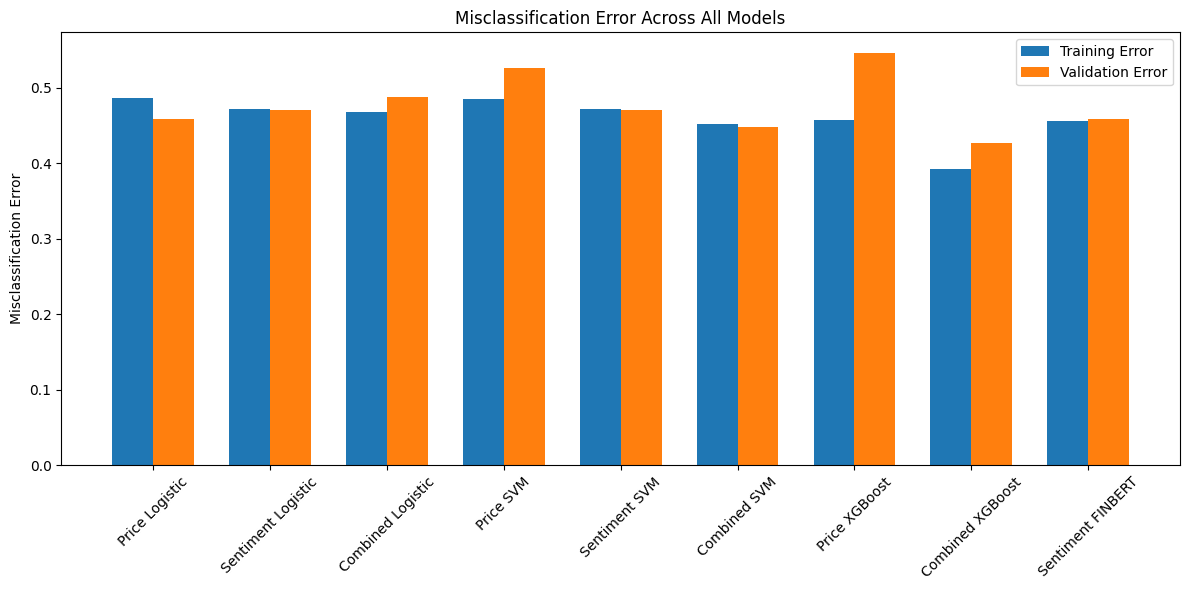

In [110]:
#create chart with error on y-axis, models on x-axis
model_names = [
    "Price Logistic", "Sentiment Logistic", "Combined Logistic", "Price SVM",
    "Sentiment SVM", "Combined SVM", "Price XGBoost", "Combined XGBoost"
    , "Sentiment FINBERT"
]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_errors, width, label='Training Error')
plt.bar(x + width/2, val_errors, width, label='Validation Error')

plt.xticks(x, model_names, rotation=45)
plt.ylabel("Misclassification Error")
plt.title("Misclassification Error Across All Models")
plt.legend()
plt.tight_layout()
plt.show()


Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                    

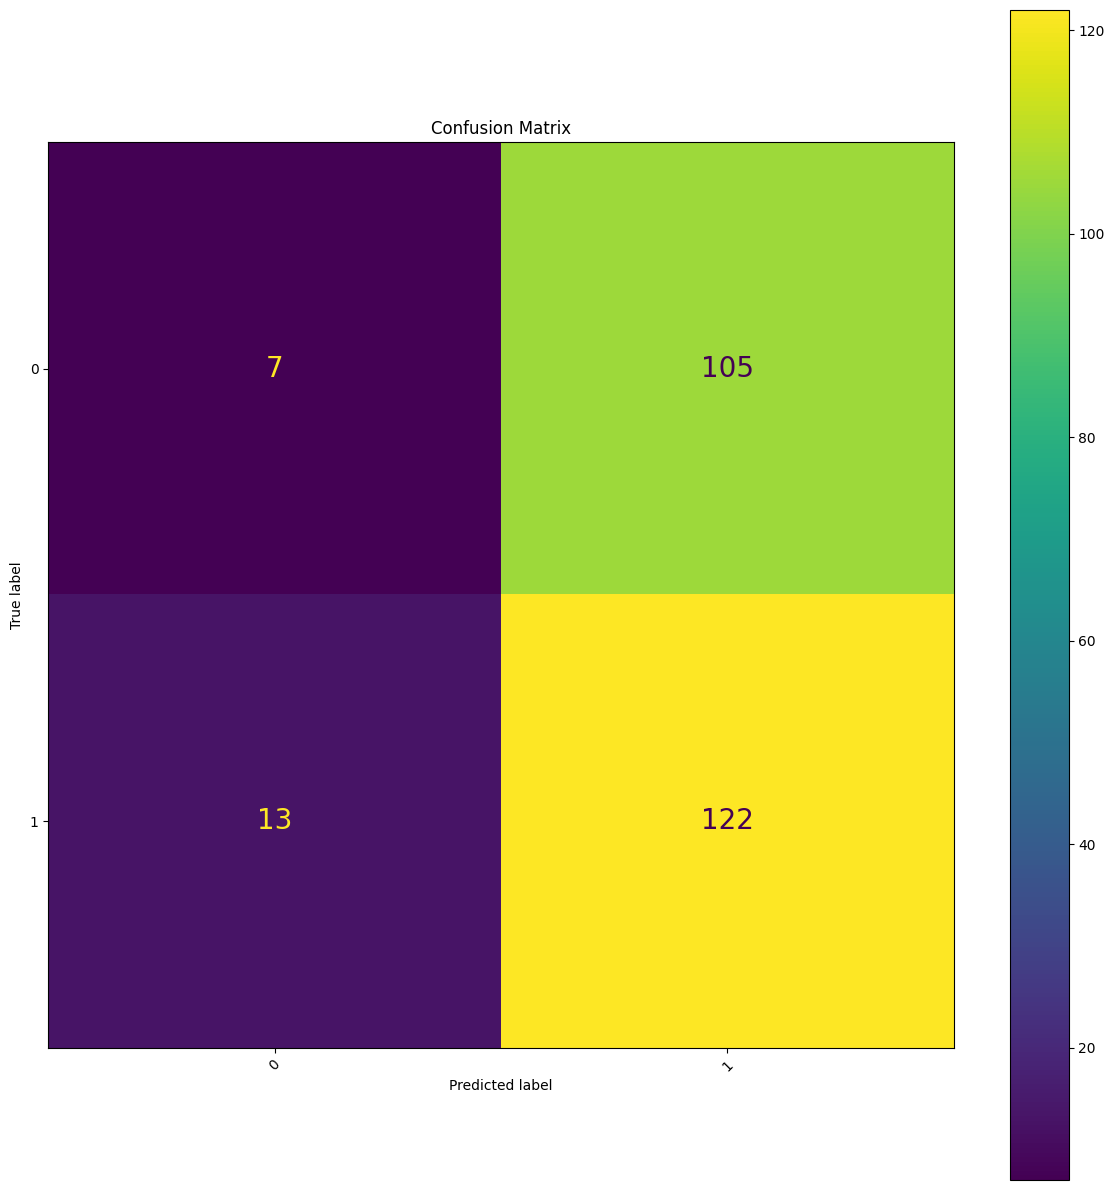

In [111]:
def test_metrics(model, val_X, val_y, print_matrix = True):
    
    #Generate predictions and produce accuracy metrics
    my_pred = model.predict(val_X)
    print(f'Model: {model}')
    print(CR(my_pred, val_y))
    
    #generate confusion matrix
    cm = confusion_matrix(val_y, my_pred, labels=model.classes_)
    
    #print confusion matrix
    if print_matrix:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    
        fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size for readability
        disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)
    
        for row in disp.text_:
            for text in row:
                text.set_fontsize(20)
    
    
        plt.title("Confusion Matrix")
        plt.tight_layout()
        plt.show()

test_metrics(best_xgb, com_test_X, com_test_y)

# Week 10 - Data Centric AI

In [112]:
# Final data cleaning function for the data-centric approach, this will be used to create the X and y datasets for the price, sentiment, and combined models.
# This function will also create lagged variables for the sentiment polarity, which will be used in the models.
def data_centric_cleaning(sentiment_data, ts_data):
    # Create a copy to avoid modifying the original DataFrame
    sentiment_data = sentiment_data.copy()

    # Drop 'Stock Price Direction' from sentiment_data if it exists, since we will be merging with ts_data which has the target variable
    if 'Stock Price Direction' in sentiment_data.columns:
        sentiment_data.drop(columns = 'Stock Price Direction', inplace = True)
    
    #join on date
    df = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'Dates', right_on = 'Dates')

    # Drop 'tokens' column if present (contains lists which are unhashable)
    if 'tokens' in df.columns:
        df = df.drop(columns=['tokens'])

    # Sort by date to ensure correct order for lag creation
    df = df.sort_values('Dates').reset_index(drop=True)

    for i in range(1, 6):
        #create lags for both price and sentiment polarity variables
        df[f'sentiment_polarity_lag{i}'] = df['sentiment_polarity'].shift(i)
        df[f'sentiment_pos_lag{i}'] = df['sentiment_pos'].shift(i)
        df[f'sentiment_neu_lag{i}'] = df['sentiment_neu'].shift(i)
        df[f'sentiment_neg_lag{i}'] = df['sentiment_neg'].shift(i)

    #Create lags for the AAPL Share Price
    for i in range(1, 6):
        df[f'aapl_price_direction_lag{i}'] = df['AAPL Share Price'].shift(i)

    #drop rows that are missing lagged variables
    df.dropna(inplace = True)

    #drop duplicates, but there shouldn't be any because of the primary key date
    df.drop_duplicates(inplace = True)

    #pick the final columns for our dataset
    final_df = df[['Stock Price Direction', 'AAPL Share Price', 'sentiment_polarity', 'sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4', 'aapl_price_direction_lag5']]

    X_data = final_df.drop(columns = ['Stock Price Direction'])
    y_data = final_df['Stock Price Direction']

    return X_data, y_data


In [113]:
X_train_centric, y_train_centric = data_centric_cleaning(Final_Raw_X_train, cleaned_ts_train)

In [114]:
#Apply SMOTE, this weights minority class heavier 
X_train_resampled, y_train_resampled = SMOTE().fit_resample(X_train_centric, y_train_centric)

#Validation creation
X_val_centric, y_val_centric = data_centric_cleaning(Final_Raw_X_val, cleaned_ts_val)

#Test creation
X_test_centric, y_test_centric = data_centric_cleaning(Final_Raw_X_test, cleaned_ts_test)

In [115]:
param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

grid_search = GridSearchCV(XGBClassifier(random_state=42), param_grid, scoring='accuracy', cv=3, n_jobs=1)
grid_search.fit(X_train_resampled, y_train_resampled)
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Best Parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}


In [116]:
# XGBoost for Combined Dataset with bootstrapping
bootstrap_models = []

for i in range(100):
    X_boot, y_boot = resample(X_train_resampled, y_train_resampled, replace=True, random_state=i)
    xgb_boot = XGBClassifier(**best_params,random_state=42)
    xgb_boot.fit(X_boot, y_boot)
    bootstrap_models.append(xgb_boot)

# Aggregate predictions on validation set
val_probas  = np.array([m.predict_proba(X_val_centric)[:, 1]  for m in bootstrap_models]).mean(axis=0)

val_preds  = (val_probas  >= 0.5).astype(int)

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.84      0.62      0.71       155
           1       0.55      0.80      0.65        91

    accuracy                           0.69       246
   macro avg       0.70      0.71      0.68       246
weighted avg       0.74      0.69      0.69       246



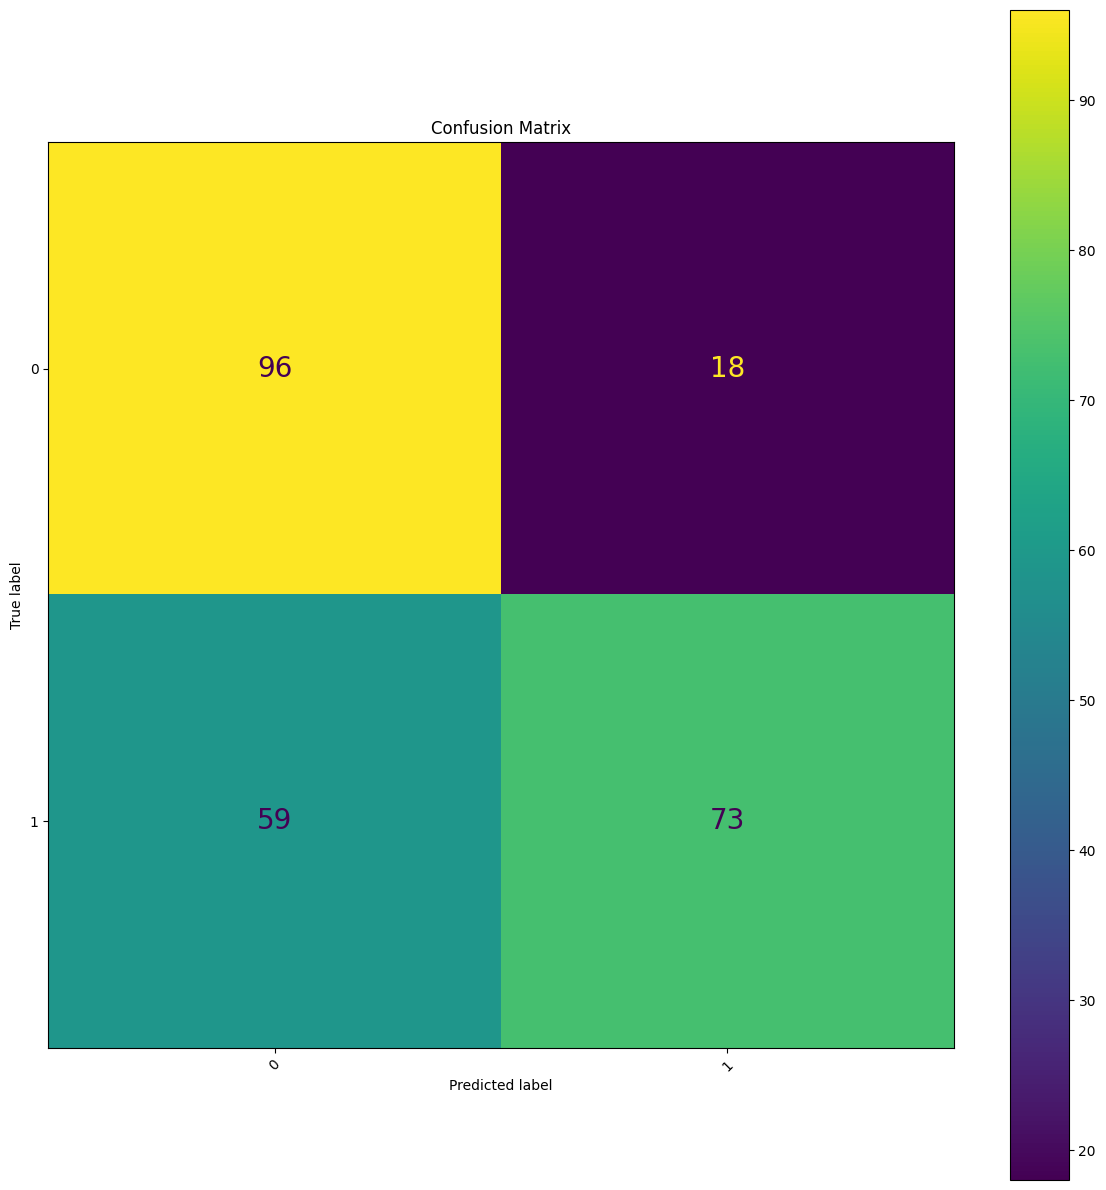

In [117]:
# Validation evaluation
print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(val_preds, y_val_centric))

cm = confusion_matrix(y_val_centric, val_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.94      0.48      0.63       219
           1       0.16      0.75      0.26        28

    accuracy                           0.51       247
   macro avg       0.55      0.61      0.45       247
weighted avg       0.85      0.51      0.59       247



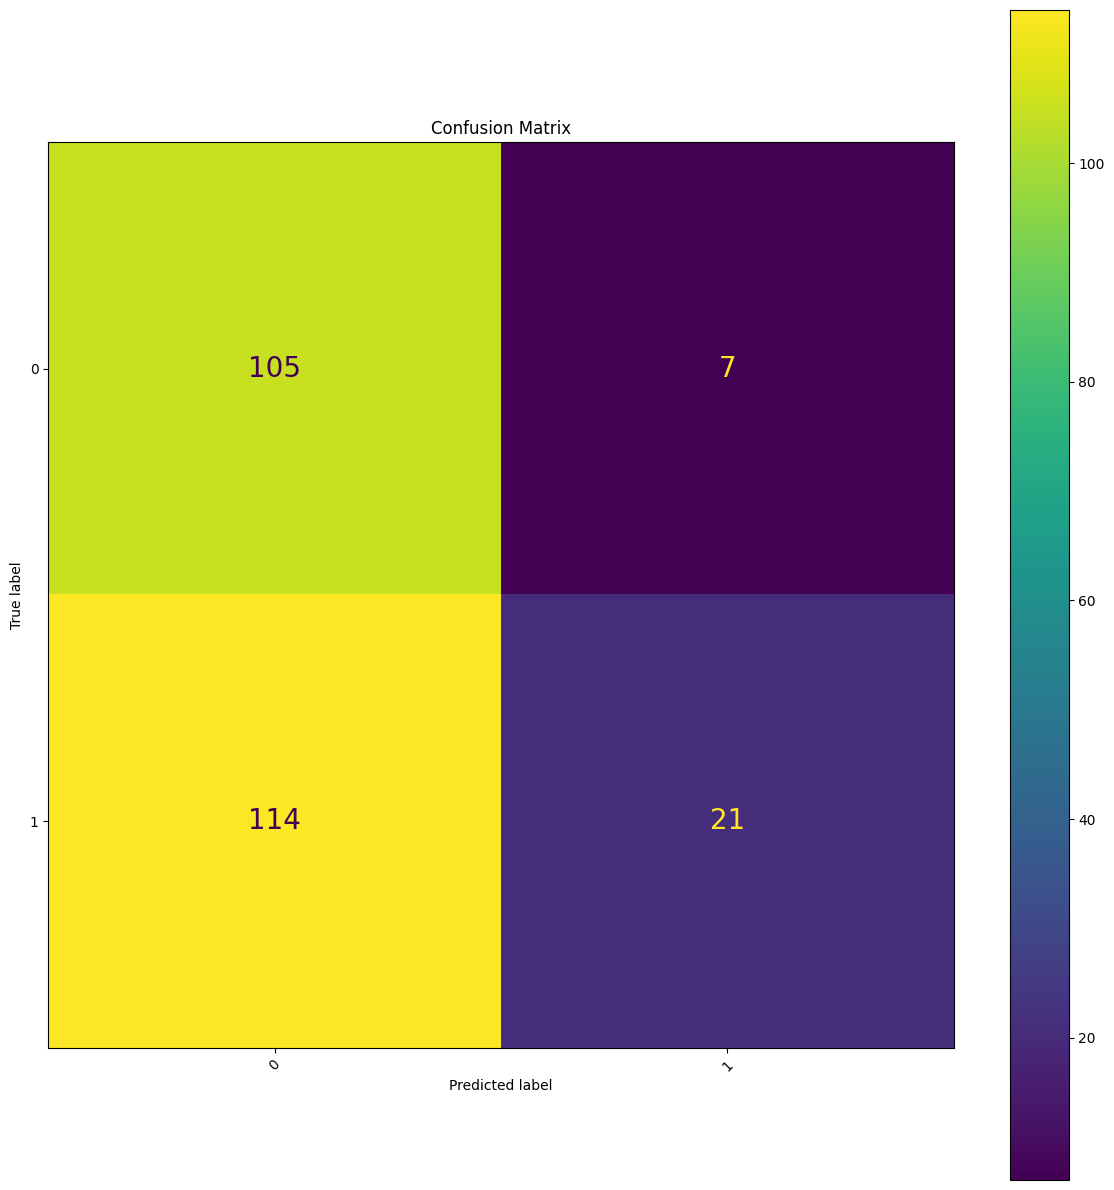

In [118]:
# Test evaluation
test_probas = np.array([m.predict_proba(X_test_centric)[:, 1] for m in bootstrap_models]).mean(axis=0)
test_preds  = (test_probas >= 0.5).astype(int)

print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(test_preds, y_test_centric))

cm = confusion_matrix(y_test_centric, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Week 11

The first part of this assigment will identify the most important features in the model, and then explain how the model generated those features.

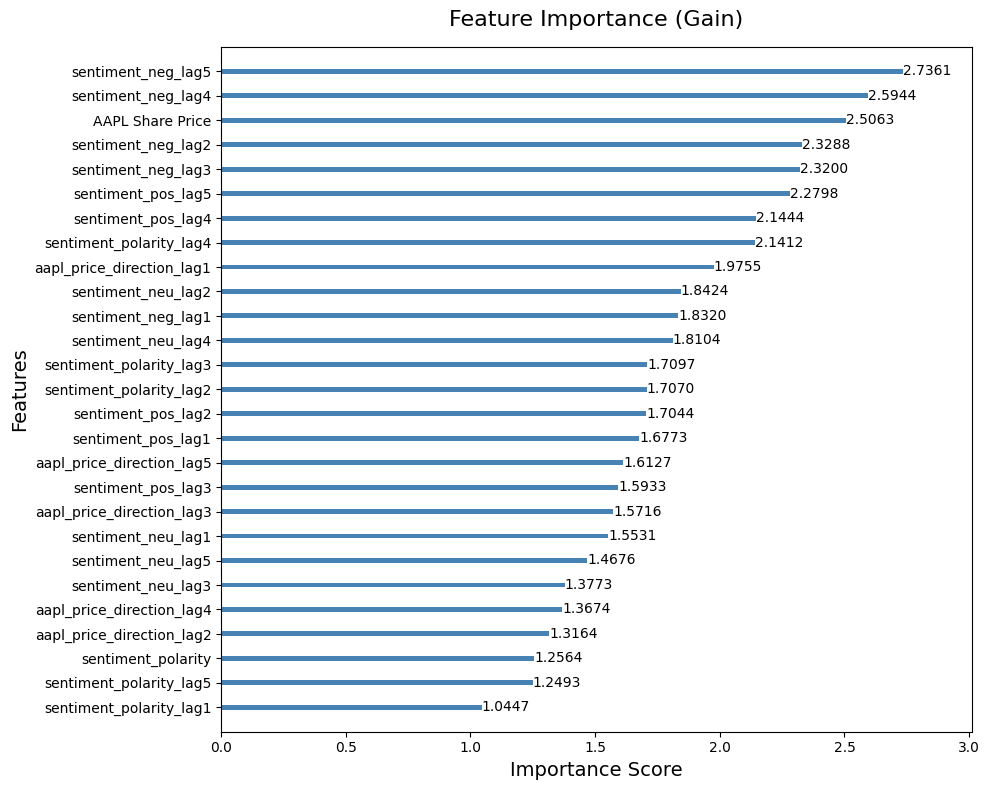

In [119]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plot_importance(
    xgb_boot,
    importance_type='gain',
    ax=ax,
    color='steelblue',
    grid=False,
)

for txt in ax.texts:
    txt.remove()

for container in ax.containers:
    # Only modify bars (not legends)
    if hasattr(container, "datavalues"):
        for bar, value in zip(container, container.datavalues):
            ax.text(
                bar.get_width() + 0.0001,   # slight offset to the right
                bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}",             # round to 4 decimals
                va='center',
                fontsize=10
            )

ax.set_title("Feature Importance (Gain)", fontsize=16, pad=15)
ax.set_xlabel("Importance Score", fontsize=14)
ax.set_ylabel("Features", fontsize=14)

plt.tight_layout()
plt.show()


This week we are focusing on a potential source of bias in the news sentiment dataset. The Apple stock price is reported on in the news individually, but also in context of its competitors. It is reported on in the context of other technology giants, and as a result, their stock price name is occassionally lumped in with other companies despite not being mentioned in the article. Here is an example below:

"S&P 500 ends at new record on stellar tech earnings, surge in U.S. economic growth recorded modest gains on Thursday after a round of upbeat earnings. reports from tech heavyweights, but saw some turbulence midday as Treasury yields rose and investors questioned how much good news was priced into the market."

As a result, the AAPL stock price news is biased by their competitors. If their competitors are doing well, sentiment will rise, and vice versa. We want to eliminate this bias by explicitly filtering to news articles which explicitly mention the Apple stock. This requires a complete re-processing of the sentiment dataset and a re-join on the historical stock price dataset. This, along with model training and evaluation, can all be found below as a part of the extra credit assignment.

In [120]:
def preprocessing_helper(df):
    '''Function for basic NLP preprocessing'''

    #Combine title and content into a single text column for NLP processing and consistency across train, val, and test sets. 
    df['full_text'] = df['title'] + ' ' + df['content']

    # Remove unnecessary columns from data set to focus on text and sentiment features.
    df = df.drop(columns=['title', 'content'])
    
     # Combine all text for the day
    df = df.groupby('date').agg({
    'full_text': lambda x: ' '.join(x),
    'sentiment_neg': 'mean',
    'sentiment_neu': 'mean',
    'sentiment_pos': 'mean',
    'sentiment_polarity': 'mean'
    })
    
    # lowercase the text for consistency
    df['full_text'] = df['full_text'].str.lower()

    # Remove punctuation and special characters from the text
    df['full_text'] = df['full_text'].str.replace(r'[^\w\s]', '', regex=True)

    # Remove extra whitespace
    df['full_text'] = df['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Remove stop words (common words that may not add much meaning to the text)
    df['full_text'] = df['full_text'].apply(
        lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
    )

    #For Nan values in the full_text column, fill with an empty string to allow for NLP processing without errors.
    df['full_text'] = df['full_text'].fillna('')

    #this is the important step. Remove articles that don't have the Apple stock price tag
    df['Apple Mention'] = df['full_text'].apply(lambda x: ('apple' in x.lower()) | ('aapl' in x.lower()))
    df = df.loc[df['Apple Mention'] == True,:]
    df.drop(columns = 'Apple Mention', inplace = True)

    # For Nan values in the sentiment columns, forwardfill up to 7 days ahead and replace remaining NaNs with 0.
    for col in ['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_polarity']:
        df[col] = df[col].ffill(limit=7).fillna(0)

    df.index.name = 'Dates'

    return df
    
def bias_removal():
    '''A bias-removal function that removes articles that aren't about AAPL stock price directly'''

    #need to read the raw data again
    raw_data = sentiment_data_creation()

    #sort by dates
    raw_data = raw_data.sort_values('date', ascending=True).reset_index(drop=True)

    #we don't need this columns anymore
    raw_data = raw_data.drop(columns=['link', 'tags'])

    # force sentiment scores to be a numerical value, NA if not 
    for col in ['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity']:
        raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

    # extract valid calendar dates only (ignore time + BST noise)
    raw_data['date'] = pd.to_datetime(
        raw_data['date'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
        errors='coerce'
    ) #This section of the code was inputed to handle warnings from pandas that could lead to future breakage of the code.
    
    # convert content to string, date to a datetime variable
    raw_data['content'] = raw_data['content'].astype('str')
    raw_data['date'] = pd.to_datetime(raw_data['date'])

    #this data is messy, drop observations that have NAs in critical columns
    raw_data = raw_data.dropna(subset=['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity','content','date'])

    # Dropping rows before January 1, 2018 and after October 31, 2024
    raw_data = raw_data[(raw_data['date'] >= '2018-01-01') & (raw_data['date'] <= '2024-10-31')]

    #sort by date
    raw_data = raw_data.sort_values("date").reset_index(drop=True)

    #recreate training, validation, and test datasets
    raw_train = raw_data[(raw_data["date"] >= "2018-01-01") & (raw_data["date"] <= "2022-10-31")]
    raw_val   = raw_data[(raw_data["date"] >= "2022-11-01") & (raw_data["date"] <= "2023-10-31")]
    raw_test  = raw_data[(raw_data["date"] >= "2023-11-01") & (raw_data["date"] <= "2024-10-31")]

    #Call preprocessing function for training, validation, test datasets
    sentiment_train = preprocessing_helper(raw_train)
    sentiment_val = preprocessing_helper(raw_val)
    sentiment_test = preprocessing_helper(raw_test)

    return sentiment_train, sentiment_val, sentiment_test

nb_train, nb_val, nb_test = bias_removal()

In [121]:
def no_bias_cleaning(sentiment_data, ts_data):
    # Create a copy to avoid modifying the original DataFrame
    sentiment_data = sentiment_data.copy()

    # Drop 'Stock Price Direction' from sentiment_data if it exists, since we will be merging with ts_data which has the target variable
    if 'Stock Price Direction' in sentiment_data.columns:
        sentiment_data.drop(columns = 'Stock Price Direction', inplace = True)
    
    #join on date
    df = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'Dates', right_on = 'Dates')

    # Drop 'tokens' column if present (contains lists which are unhashable)
    if 'tokens' in df.columns:
        df = df.drop(columns=['tokens'])

    # Sort by date to ensure correct order for lag creation
    df = df.sort_values('Dates').reset_index(drop=True)

    for i in range(1, 6):
        #create lags for both price and sentiment polarity variables
        df[f'sentiment_polarity_lag{i}'] = df['sentiment_polarity'].shift(i)
        df[f'sentiment_pos_lag{i}'] = df['sentiment_pos'].shift(i)
        df[f'sentiment_neu_lag{i}'] = df['sentiment_neu'].shift(i)
        df[f'sentiment_neg_lag{i}'] = df['sentiment_neg'].shift(i)

    #drop rows that are missing lagged variables
    df.dropna(inplace = True)

    #drop duplicates, but there shouldn't be any because of the primary key date
    df.drop_duplicates(inplace = True)

    #pick the final columns for our dataset
    final_df = df[['Stock Price Direction', 'sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4']]

    X_data = final_df.drop(columns = ['Stock Price Direction'])
    y_data = final_df['Stock Price Direction']

    return X_data, y_data

In [122]:
X_train_nb, y_train_nb = no_bias_cleaning(nb_train, cleaned_ts_train)

#Apply SMOTE, this weights minority class heavier 
X_train_resampled_nb, y_train_resampled_nb = SMOTE().fit_resample(X_train_nb, y_train_nb)

#Validation creation
X_val_nb, y_val_nb = no_bias_cleaning(nb_val, cleaned_ts_val)

#Test creation
X_test_nb, y_test_nb = no_bias_cleaning(nb_test, cleaned_ts_test)

In [123]:
param_grid = {
    'xgb__n_estimators': [100, 400, 750],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.02, 0.05, 0.10]
}

grid_search = GridSearchCV(XGBClassifier(random_state=42), param_grid, scoring='accuracy', cv=5, n_jobs=1)
grid_search.fit(X_train_resampled_nb, y_train_resampled_nb)
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Best Parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}


In [124]:
# XGBoost for Combined Dataset with bootstrapping
bootstrap_models = []

for i in range(100):
    X_boot, y_boot = resample(X_train_resampled_nb, y_train_resampled_nb, replace=True, random_state=i)
    xgb_boot = XGBClassifier(**best_params,random_state=42)
    xgb_boot.fit(X_boot, y_boot)
    bootstrap_models.append(xgb_boot)

# Aggregate predictions on validation set
val_probas  = np.array([m.predict_proba(X_val_nb)[:, 1]  for m in bootstrap_models]).mean(axis=0)

val_preds  = (val_probas  >= 0.5).astype(int)

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.59      0.51      0.54       132
           1       0.51      0.59      0.54       114

    accuracy                           0.54       246
   macro avg       0.55      0.55      0.54       246
weighted avg       0.55      0.54      0.54       246



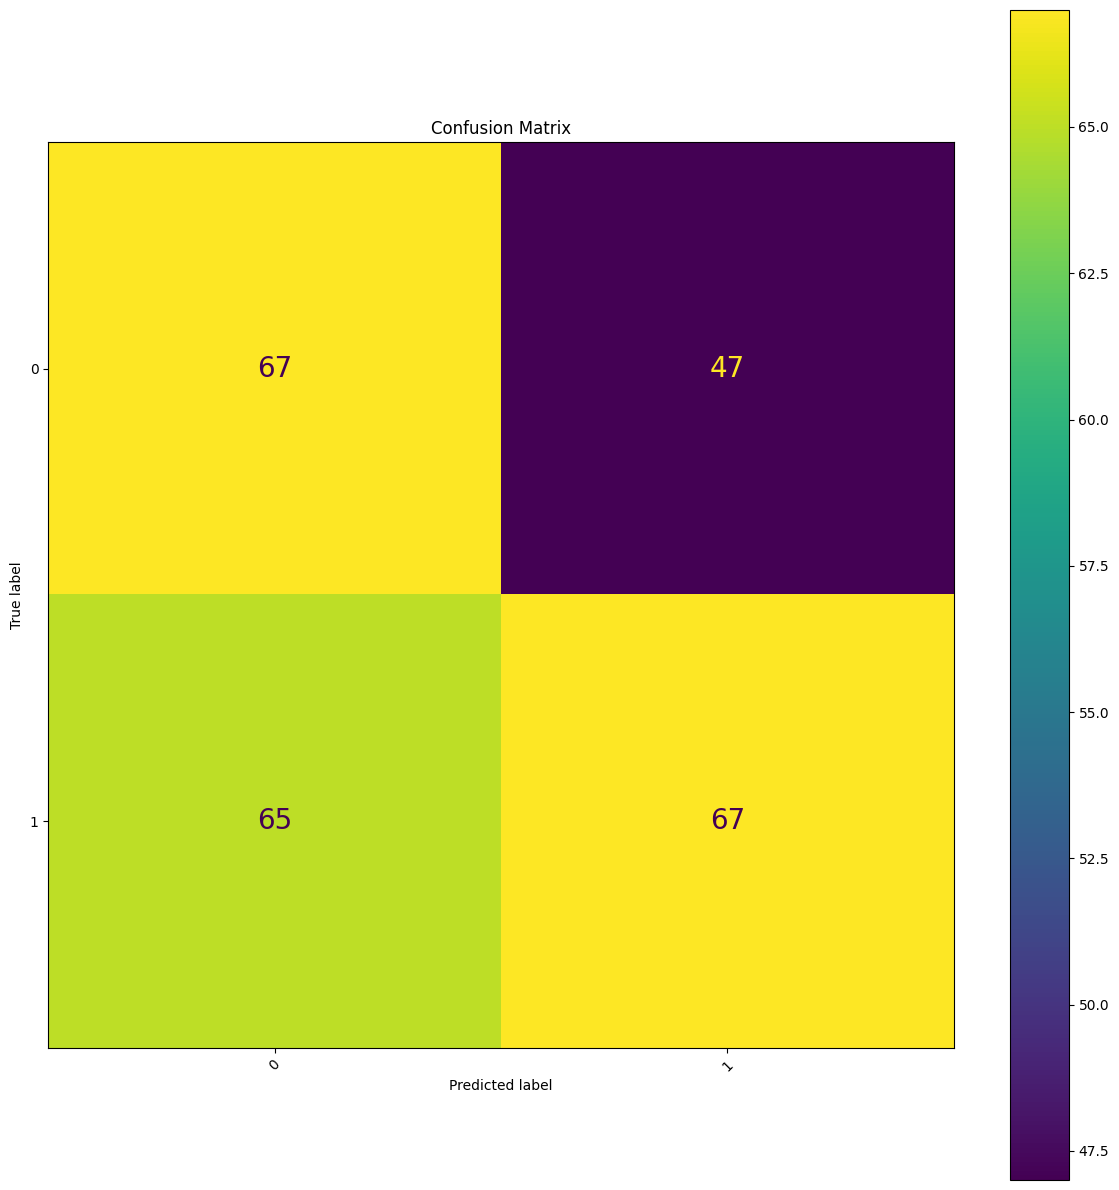

In [125]:
# Validation evaluation
print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(val_preds, y_val_nb))

cm = confusion_matrix(y_val_nb, val_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Model: XGBClassifier (bootstrapped, n=100)
              precision    recall  f1-score   support

           0       0.63      0.50      0.56       138
           1       0.48      0.61      0.54       105

    accuracy                           0.55       243
   macro avg       0.55      0.55      0.55       243
weighted avg       0.56      0.55      0.55       243



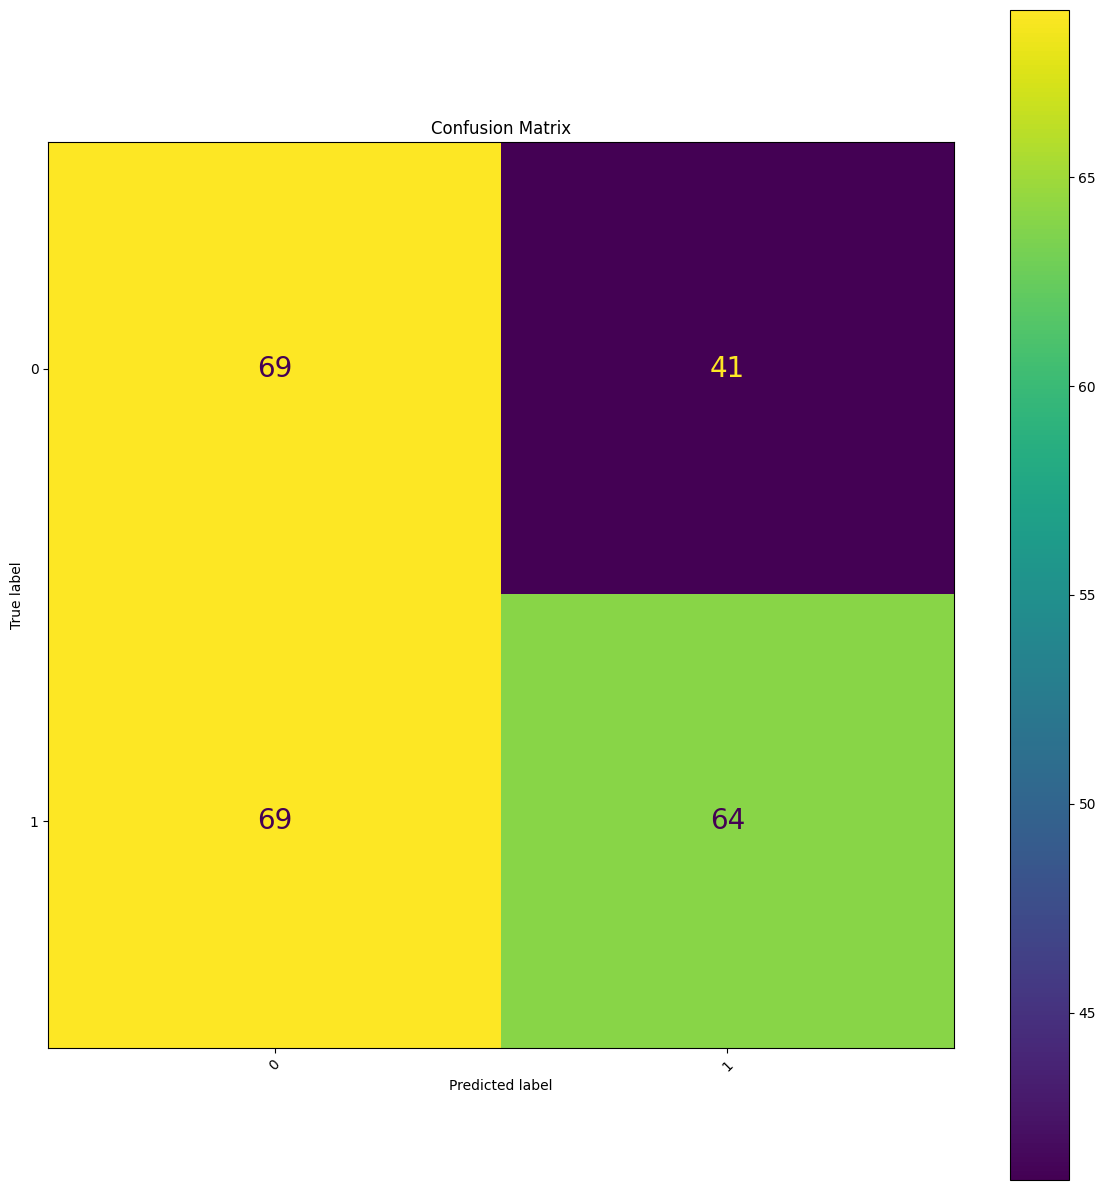

In [126]:
# Test evaluation
test_probas = np.array([m.predict_proba(X_test_nb)[:, 1] for m in bootstrap_models]).mean(axis=0)
test_preds  = (test_probas >= 0.5).astype(int)

print(f"Model: XGBClassifier (bootstrapped, n=100)")
print(CR(test_preds, y_test_nb))

cm = confusion_matrix(y_test_nb, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap='viridis', xticks_rotation=45)

for row in disp.text_:
    for text in row:
        text.set_fontsize(20)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Model Prediction Interpretation & Feature Contribution Analysis

This section explains individual predictions using SHAP values and counterfactual analysis to show what changes would be needed to flip predictions.

The SHAP (SHapley Additive exPlanations) package is a popular Python library used to explain the output of any machine learning model. It is based on Shapley values from cooperative game theory, which provide a mathematically grounded way to fairly distribute "credit" among the features that contributed to a model's prediction. 

In [127]:
# Select a background sample for SHAP (use a subset of training data for efficiency)
# This helps SHAP understand feature distributions
background_sample = X_train_resampled_nb.sample(min(100, len(X_train_resampled_nb)), random_state=42)

# Use the first bootstrapped model for explanation (they all have similar logic)
base_model = bootstrap_models[0]

# Create SHAP explainer
# Note: TreeExplainer is efficient for tree-based models like XGBoost
explainer = shap.TreeExplainer(base_model)

print("SHAP explainer initialized successfully")
print(f"Feature names: {X_test_nb.columns.tolist()}")
print(f"Number of test samples: {len(X_test_nb)}")

SHAP explainer initialized successfully
Feature names: ['sentiment_polarity_lag1', 'sentiment_polarity_lag2', 'sentiment_polarity_lag3', 'sentiment_polarity_lag4', 'sentiment_polarity_lag5', 'sentiment_pos_lag1', 'sentiment_pos_lag2', 'sentiment_pos_lag3', 'sentiment_pos_lag4', 'sentiment_pos_lag5', 'sentiment_neu_lag1', 'sentiment_neu_lag2', 'sentiment_neu_lag3', 'sentiment_neu_lag4', 'sentiment_neu_lag5', 'sentiment_neg_lag1', 'sentiment_neg_lag2', 'sentiment_neg_lag3', 'sentiment_neg_lag4', 'sentiment_neg_lag5', 'aapl_price_direction_lag1', 'aapl_price_direction_lag2', 'aapl_price_direction_lag3', 'aapl_price_direction_lag4']
Number of test samples: 243


In [128]:
# Select 5 random test predictions for explanation
np.random.seed(42)
selected_indices = np.random.choice(len(X_test_nb), size=5, replace=False)

print(f"EXPLAINING 5 RANDOMLY SELECTED PREDICTIONS")
print(f"Selected test indices: {sorted(selected_indices)}\n")

# Compute SHAP values for these specific samples
selected_X = X_test_nb.iloc[selected_indices]
shap_values = explainer.shap_values(selected_X)

# Store for later use
explained_samples = {
    'indices': selected_indices,
    'X': selected_X,
    'shap_values': shap_values,
    'base_value': explainer.expected_value
}

print(f"SHAP base value (model's average prediction): {explained_samples['base_value']:.4f}")
print(f"SHAP values computed for {len(selected_indices)} samples\n")

EXPLAINING 5 RANDOMLY SELECTED PREDICTIONS
Selected test indices: [np.int64(6), np.int64(24), np.int64(152), np.int64(232), np.int64(238)]

SHAP base value (model's average prediction): 0.0466
SHAP values computed for 5 samples



In [129]:
# Detailed explanation of each prediction with feature contributions
print("DETAILED PREDICTION EXPLANATIONS")

for sample_num, idx in enumerate(selected_indices, 1):
    print(f"PREDICTION #{sample_num} (Test Index: {idx})")
    
    # Get the actual prediction and probability
    pred = test_preds[idx]
    prob = test_probas[idx]
    actual = y_test_nb.iloc[idx]
    
    print(f"\nPrediction Result:")
    print(f"  - Predicted Class: {pred} ({'UP' if pred == 1 else 'DOWN'})")
    print(f"  - Prediction Probability: {prob:.4f}")
    print(f"  - Actual Class: {actual} ({'UP' if actual == 1 else 'DOWN'})")
    print(f"  - Correct: {'✓' if pred == actual else '✗'}")
    
    # Get SHAP values for this prediction
    sample_shap = shap_values[sample_num - 1]
    
    # Feature values for this prediction
    feature_values = selected_X.iloc[sample_num - 1]
    
    # Create a dataframe of features, values, and SHAP contributions
    feature_contrib = pd.DataFrame({
        'Feature': selected_X.columns,
        'Value': feature_values.values,
        'SHAP_Value': sample_shap,
        'Abs_SHAP': np.abs(sample_shap)
    }).sort_values('Abs_SHAP', ascending=False)
    
    print(f"\nTop 10 Features Contributing to This Prediction:")
    print(f"(SHAP > 0 means contribution towards Class 1 'UP', SHAP < 0 means towards Class 0 'DOWN')")
    print()
    
    for i, row in feature_contrib.head(10).iterrows():
        direction = "↑ UP" if row['SHAP_Value'] > 0 else "↓ DOWN"
        print(f"  {row['Feature']:30s} | Value: {row['Value']:10.4f} | "
              f"SHAP: {row['SHAP_Value']:8.4f} | {direction}")
    
    print(f"\nTop Features Pushing Towards Predicted Class ({pred}):")
    if pred == 1:
        top_positive = feature_contrib[feature_contrib['SHAP_Value'] > 0].head(5)
    else:
        top_positive = feature_contrib[feature_contrib['SHAP_Value'] < 0].head(5)
    
    for i, row in top_positive.iterrows():
        print(f"  • {row['Feature']:30s}: {row['Value']:10.4f} (impact: {row['SHAP_Value']:+.4f})")

DETAILED PREDICTION EXPLANATIONS
PREDICTION #1 (Test Index: 24)

Prediction Result:
  - Predicted Class: 0 (DOWN)
  - Prediction Probability: 0.4379
  - Actual Class: 1 (UP)
  - Correct: ✗

Top 10 Features Contributing to This Prediction:
(SHAP > 0 means contribution towards Class 1 'UP', SHAP < 0 means towards Class 0 'DOWN')

  sentiment_pos_lag1             | Value:     0.1089 | SHAP:   0.8433 | ↑ UP
  sentiment_polarity_lag5        | Value:     0.4991 | SHAP:  -0.5329 | ↓ DOWN
  sentiment_neg_lag5             | Value:     0.0386 | SHAP:  -0.4562 | ↓ DOWN
  sentiment_polarity_lag3        | Value:     0.4438 | SHAP:  -0.4484 | ↓ DOWN
  sentiment_neu_lag3             | Value:     0.8935 | SHAP:  -0.4014 | ↓ DOWN
  sentiment_neu_lag2             | Value:     0.8543 | SHAP:   0.2923 | ↑ UP
  sentiment_neg_lag3             | Value:     0.0285 | SHAP:  -0.2817 | ↓ DOWN
  sentiment_polarity_lag4        | Value:     0.5488 | SHAP:   0.2738 | ↑ UP
  sentiment_polarity_lag2        | Value:   

In [130]:
# Counterfactual Analysis: What needs to change to flip predictions?
print("COUNTERFACTUAL ANALYSIS: WHAT WOULD FLIP THE PREDICTION?")

def analyze_counterfactual(model, X_data, original_idx, feature_stats):
    """
    Analyze what feature changes would be needed to flip a prediction.
    Uses empirical percentile changes based on the training data distribution.
    """
    pred_original = model.predict_proba(X_data.iloc[[original_idx]])[0][1]
    target_prob = 0.5 - pred_original * 0.02  # Target: flip with small margin
    
    sample = X_data.iloc[original_idx].copy()
    sample_tuple = tuple(sample.values)
    
    changes = {}
    
    # For each feature, estimate change needed
    for feature in X_data.columns:
        original_value = sample[feature]
        
        # Get feature statistics from training set
        col_values = X_train_resampled_nb[feature].values
        col_mean = col_values.mean()
        col_std = col_values.std()
        col_max = col_values.max()
        col_min = col_values.min()
        
        # Calculate percentiles
        p25 = np.percentile(col_values, 25)
        p75 = np.percentile(col_values, 75)
        
        # Estimate a reasonable change (increase or decrease)
        if original_value < col_mean:
            # Try increasing to upper quartile
            change_magnitude = max(p75 - original_value, col_std * 0.5)
        else:
            # Try decreasing to lower quartile
            change_magnitude = max(original_value - p25, col_std * 0.5)
        
        changes[feature] = {
            'original': original_value,
            'p25': p25,
            'mean': col_mean,
            'p75': p75,
            'change_magnitude': change_magnitude
        }
    
    return changes

# Analyze each selected prediction
for sample_num, idx in enumerate(selected_indices, 1):
    print(f"\n{'─' * 80}")
    print(f"PREDICTION #{sample_num} (Test Index: {idx})")
    print(f"Current Prediction: {test_preds[idx]} ({'UP' if test_preds[idx] == 1 else 'DOWN'}) "
          f"with probability {test_probas[idx]:.4f}")
    print(f"Target: FLIP to {1 - test_preds[idx]} ({'UP' if test_preds[idx] == 0 else 'DOWN'})")
    print(f"{'─' * 80}")
    
    # Get the feature contributions for this sample
    sample_shap = shap_values[sample_num - 1]
    feature_values = selected_X.iloc[sample_num - 1]
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': selected_X.columns,
        'Value': feature_values.values,
        'SHAP': sample_shap,
        'Abs_SHAP': np.abs(sample_shap)
    }).sort_values('Abs_SHAP', ascending=False)
    
    # Features opposing the current prediction would most likely flip it
    current_pred = test_preds[idx]
    target_pred = 1 - current_pred
    
    print(f"\nFeatures Most Likely to Flip the Prediction (if reversed):")
    print(f"(These features currently push towards Class {current_pred},")
    print(f" reversing them might push towards Class {target_pred})\n")
    
    # Show top 5 features that need to change
    if current_pred == 1:
        # For Class 1 predictions, reverse positive SHAP values
        flip_candidates = feature_importance[feature_importance['SHAP'] > 0].head(5)
    else:
        # For Class 0 predictions, reverse negative SHAP values
        flip_candidates = feature_importance[feature_importance['SHAP'] < 0].head(5)
    
    for rank, (i, row) in enumerate(flip_candidates.iterrows(), 1):
        col_values = X_train_resampled_nb[row['Feature']].values
        col_mean = col_values.mean()
        col_std = col_values.std()
        p25, p50, p75 = np.percentile(col_values, [25, 50, 75])
        
        print(f"  {rank}. {row['Feature']}")
        print(f"     Current Value: {row['Value']:.4f}")
        print(f"     Data Statistics (train): Mean={col_mean:.4f}, Std={col_std:.4f}")
        print(f"                             Q1={p25:.4f}, Median={p50:.4f}, Q3={p75:.4f}")
        
        # Suggest direction of change
        if row['SHAP'] > 0 and current_pred == 1:
            suggested_change = f"Decrease towards Q1 ({p25:.4f})"
            change_amount = row['Value'] - p25
        elif row['SHAP'] < 0 and current_pred == 0:
            suggested_change = f"Increase towards Q3 ({p75:.4f})"
            change_amount = p75 - row['Value']
        else:
            suggested_change = "Unknown"
            change_amount = 0
        
        print(f"     Suggested Change: {suggested_change}")
        print(f"     Change Magnitude: {change_amount:.4f} units ({change_amount/col_std:.2f}σ)")
        print()

COUNTERFACTUAL ANALYSIS: WHAT WOULD FLIP THE PREDICTION?

────────────────────────────────────────────────────────────────────────────────
PREDICTION #1 (Test Index: 24)
Current Prediction: 0 (DOWN) with probability 0.4379
Target: FLIP to 1 (UP)
────────────────────────────────────────────────────────────────────────────────

Features Most Likely to Flip the Prediction (if reversed):
(These features currently push towards Class 0,
 reversing them might push towards Class 1)

  1. sentiment_polarity_lag5
     Current Value: 0.4991
     Data Statistics (train): Mean=0.4874, Std=0.2365
                             Q1=0.3863, Median=0.4997, Q3=0.6087
     Suggested Change: Increase towards Q3 (0.6087)
     Change Magnitude: 0.1096 units (0.46σ)

  2. sentiment_neg_lag5
     Current Value: 0.0386
     Data Statistics (train): Mean=0.0397, Std=0.0148
                             Q1=0.0301, Median=0.0380, Q3=0.0472
     Suggested Change: Increase towards Q3 (0.0472)
     Change Magnitude: 0.0

SHAP FORCE PLOTS: VISUAL EXPLANATION OF EACH PREDICTION

Generating SHAP Force Plot for Prediction #1 (Index 24)


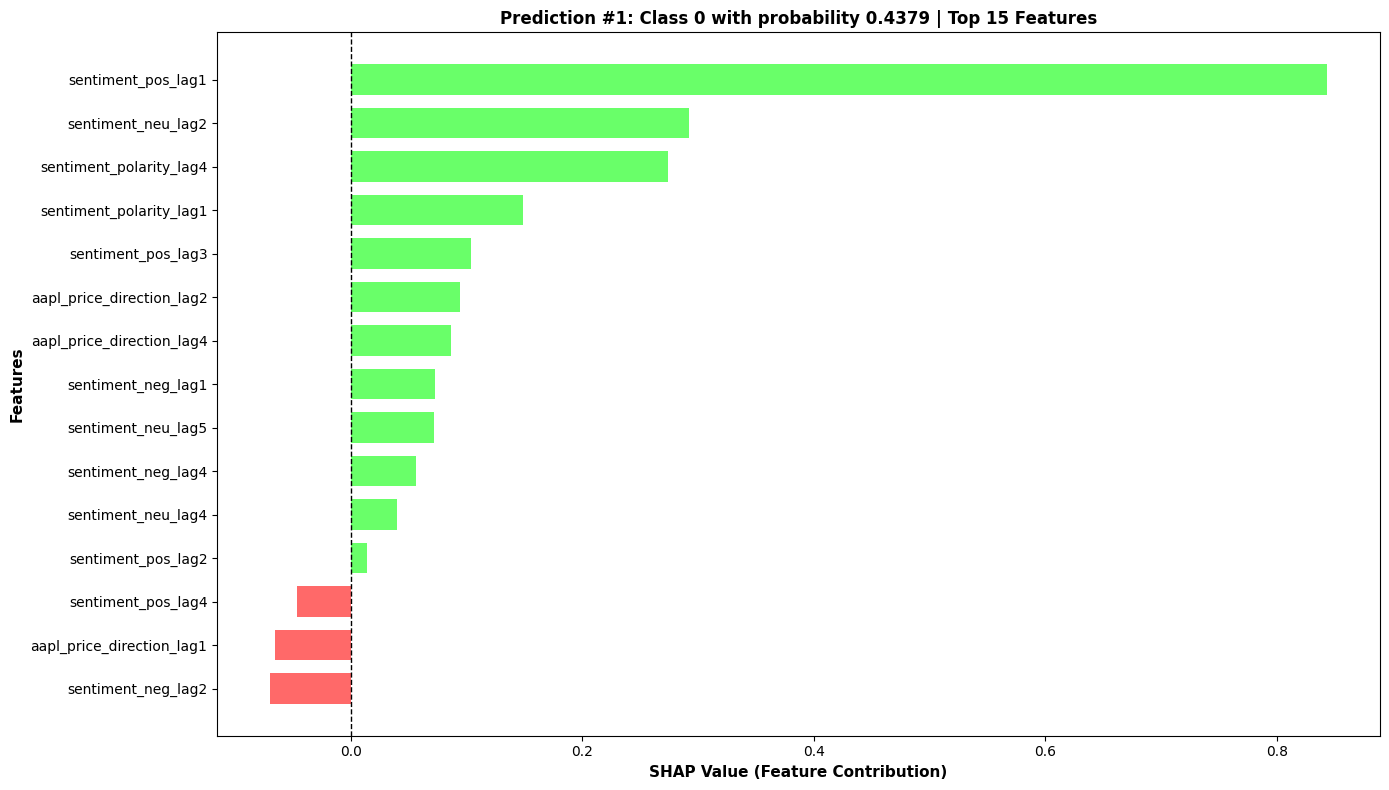


Generating SHAP Force Plot for Prediction #2 (Index 6)


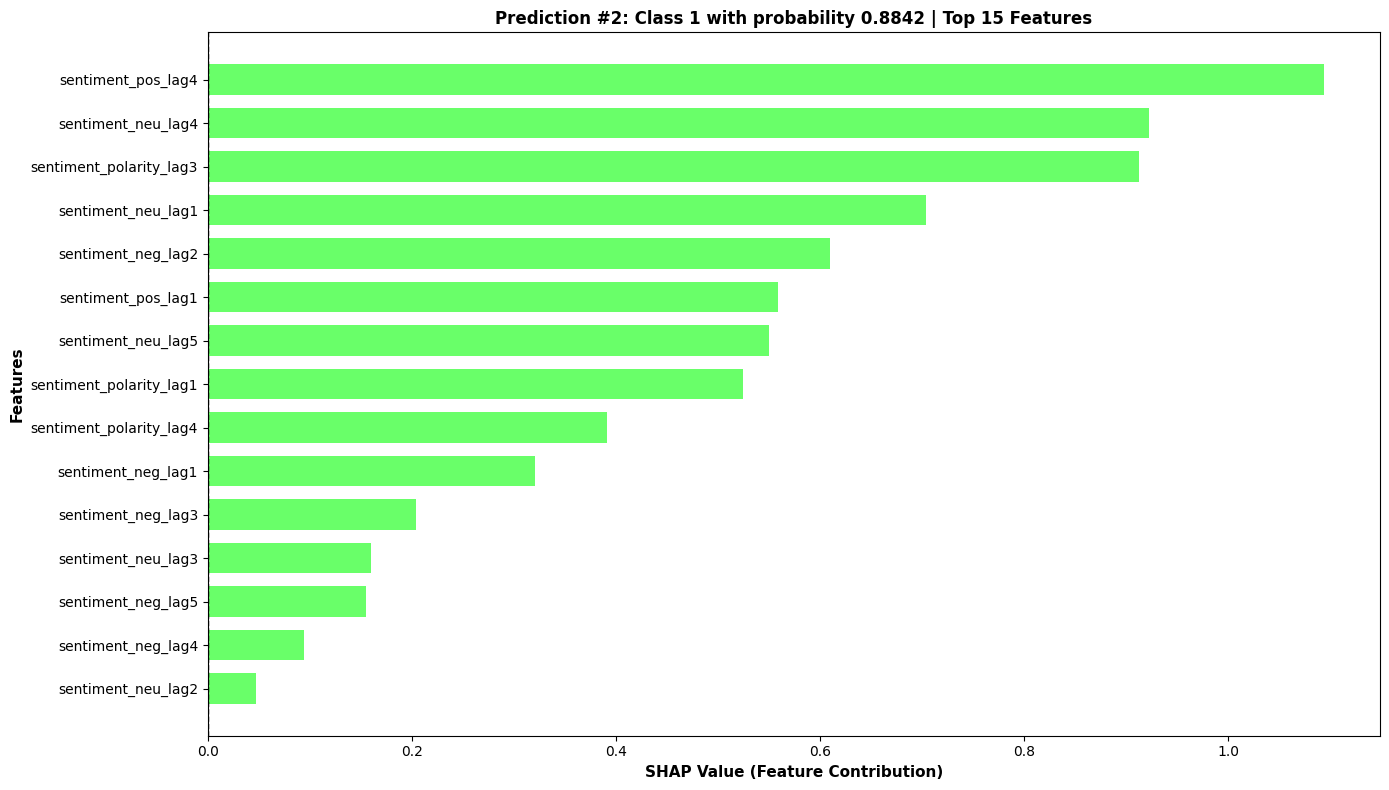


Generating SHAP Force Plot for Prediction #3 (Index 152)


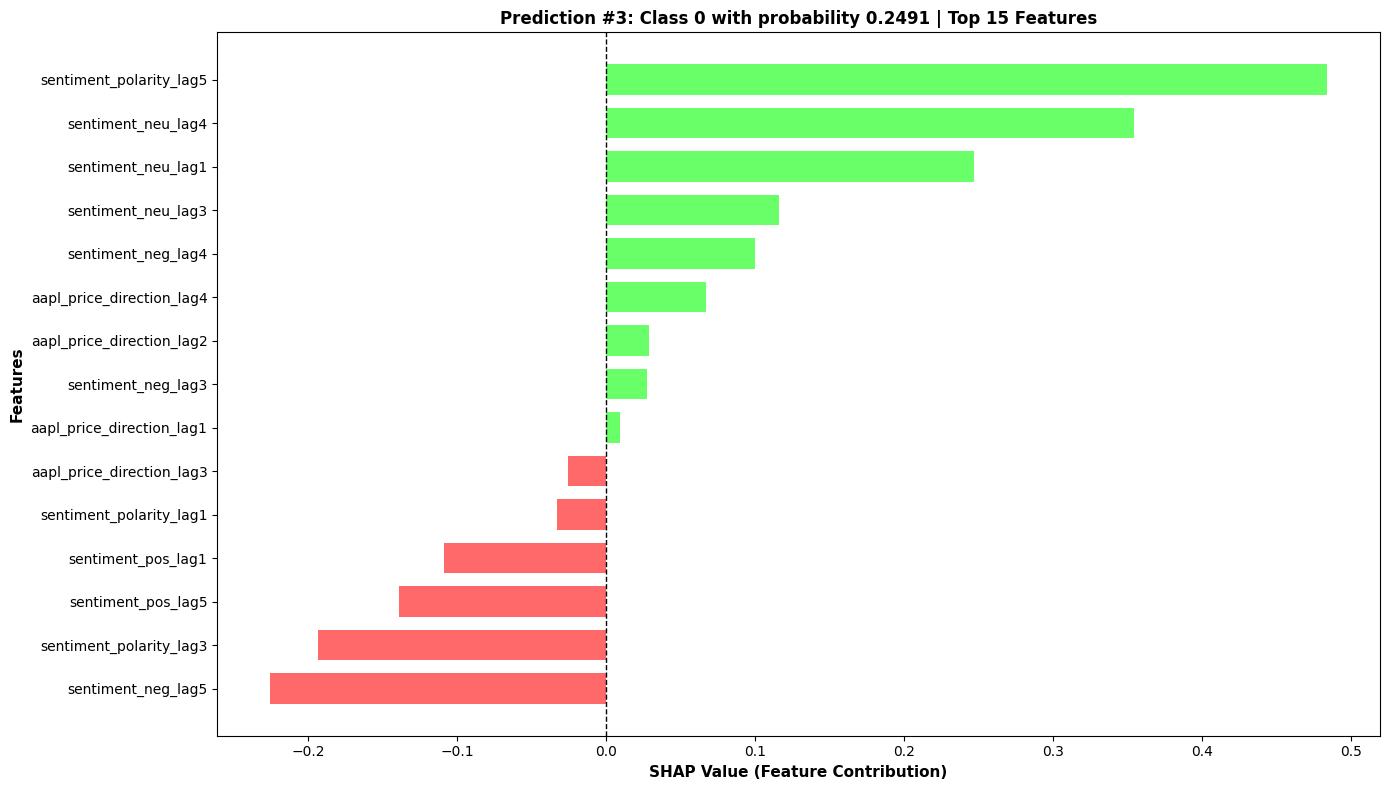


Generating SHAP Force Plot for Prediction #4 (Index 232)


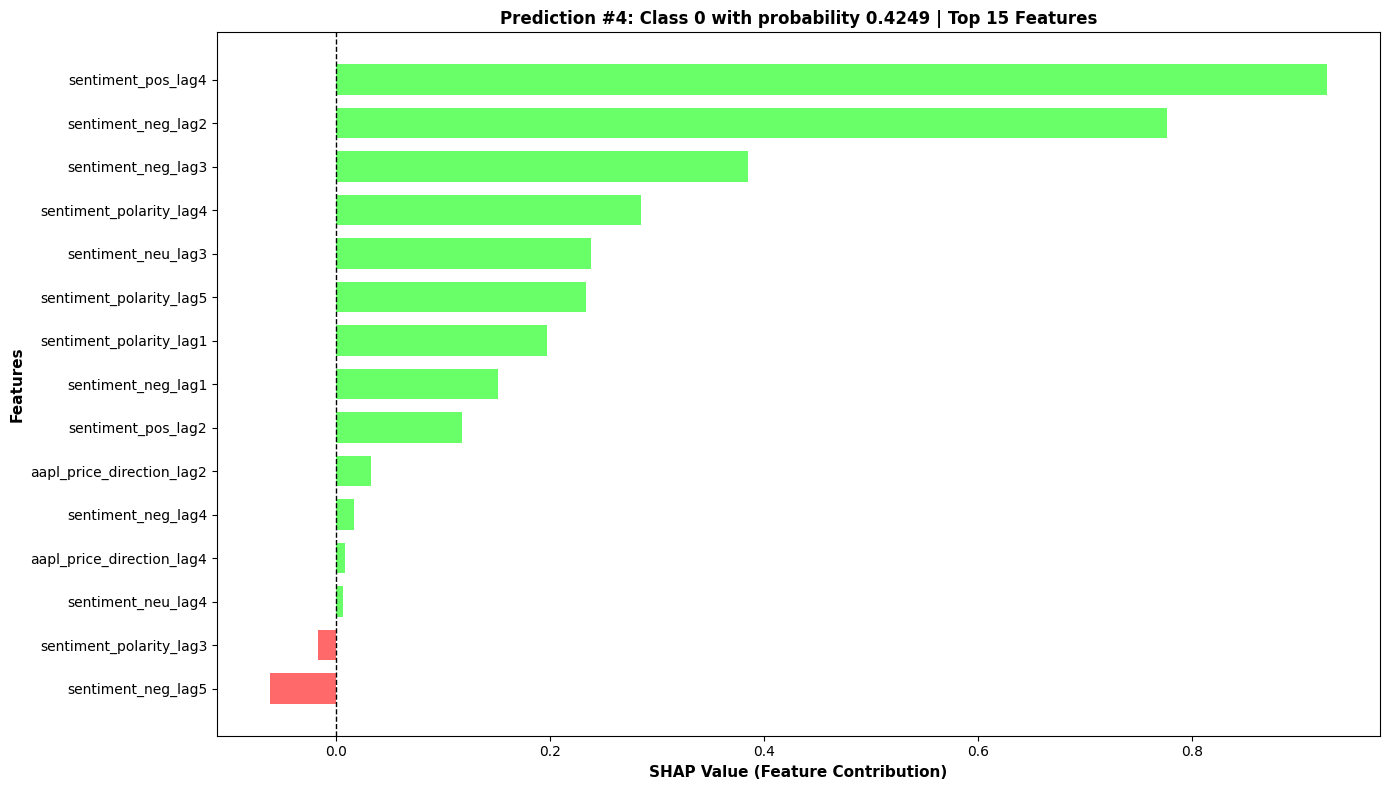


Generating SHAP Force Plot for Prediction #5 (Index 238)


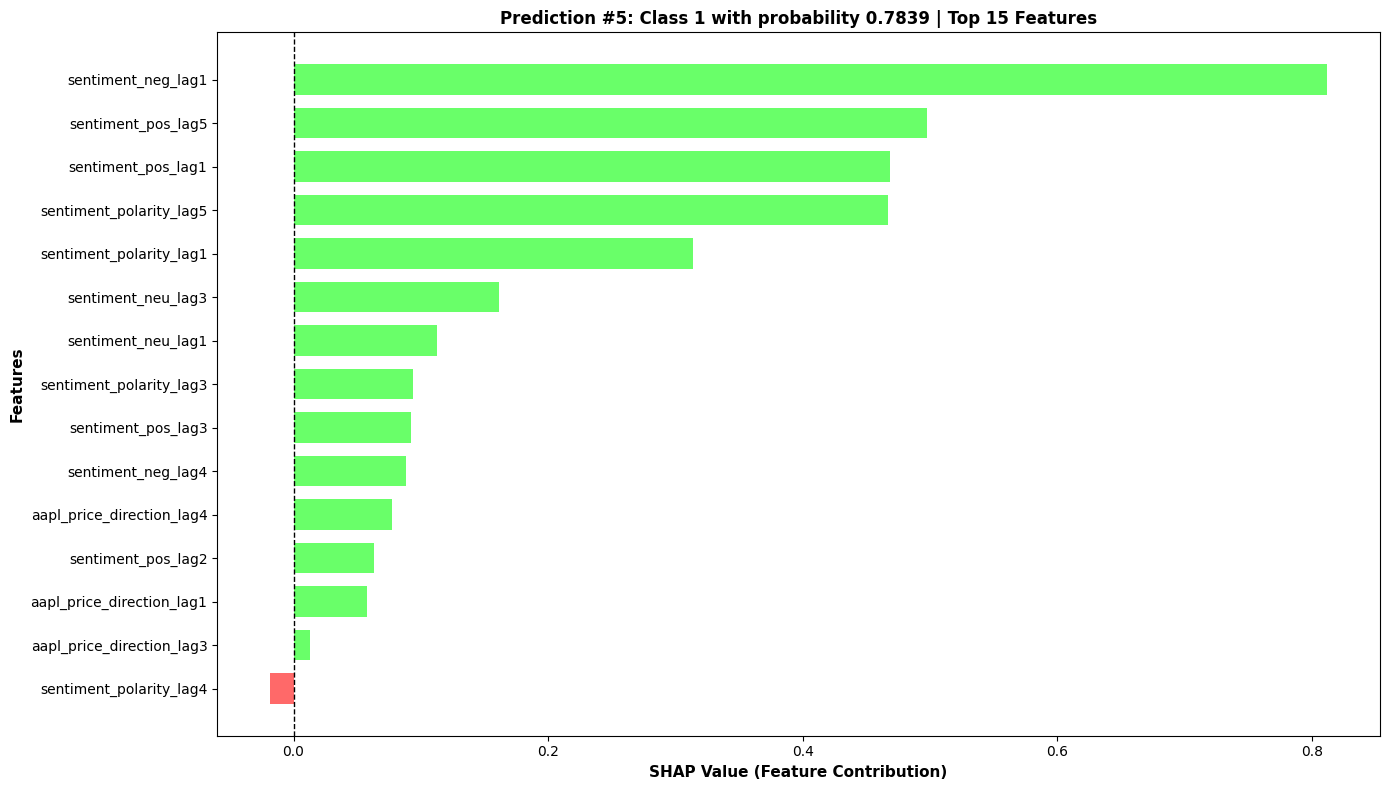

In [131]:
# Visualize SHAP explanations for each prediction
print("SHAP FORCE PLOTS: VISUAL EXPLANATION OF EACH PREDICTION")

fig_count = 0
for sample_num, idx in enumerate(selected_indices, 1):
    print(f"\nGenerating SHAP Force Plot for Prediction #{sample_num} (Index {idx})")
    
    sample_shap = shap_values[sample_num - 1]
    feature_values = selected_X.iloc[sample_num - 1]
    
    # Create a force plot for this specific prediction
    # The force plot shows how features push the model's output away from the base value
    try:
        # Create a simple bar plot for interpretability
        feature_contrib = pd.DataFrame({
            'Feature': selected_X.columns,
            'SHAP': sample_shap,
            'Abs_SHAP': np.abs(sample_shap)
        }).sort_values('SHAP')
        
        # Show only top 15 features for clarity
        top_n = 15
        display_contrib = feature_contrib.tail(top_n) if len(feature_contrib) > top_n else feature_contrib
        
        # Increase figure height based on number of features
        fig_height = max(8, len(display_contrib) * 0.35)
        plt.figure(figsize=(14, fig_height))
        
        colors = ['#FF4444' if x < 0 else '#44FF44' for x in display_contrib['SHAP']]
        plt.barh(display_contrib['Feature'], display_contrib['SHAP'], color=colors, alpha=0.8, height=0.7)
        
        pred_class = test_preds[idx]
        prob = test_probas[idx]
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
        plt.xlabel('SHAP Value (Feature Contribution)', fontsize=11, fontweight='bold')
        plt.ylabel('Features', fontsize=11, fontweight='bold')
        plt.title(f'Prediction #{sample_num}: Class {pred_class} with probability {prob:.4f} | '
                  f'Top {min(top_n, len(feature_contrib))} Features', 
                  fontsize=12, fontweight='bold')
        
        # Adjust y-axis label spacing
        plt.yticks(fontsize=10)
        plt.xticks(fontsize=10)
        plt.tight_layout()
        plt.show()
        
        fig_count += 1
        
    except Exception as e:
        print(f"  Could not create plot: {e}")

In [132]:
# Summary Table: All 5 Predictions at a Glance
print("SUMMARY: ALL 5 PREDICTIONS AT A GLANCE")

summary_data = []

for sample_num, idx in enumerate(selected_indices, 1):
    pred = test_preds[idx]
    prob = test_probas[idx]
    actual = y_test_nb.iloc[idx]
    correct = "✓" if pred == actual else "✗"
    
    # Get top 3 contributing features
    sample_shap = shap_values[sample_num - 1]
    feature_values = selected_X.iloc[sample_num - 1]
    
    feature_contrib = pd.DataFrame({
        'Feature': selected_X.columns,
        'SHAP': sample_shap,
        'Abs_SHAP': np.abs(sample_shap)
    }).sort_values('Abs_SHAP', ascending=False)
    
    top_features = ', '.join([f"{row['Feature'][:20]}({row['SHAP']:.3f})" 
                               for _, row in feature_contrib.head(3).iterrows()])
    
    summary_data.append({
        'Prediction #': sample_num,
        'Test Index': idx,
        'Predicted': f"{pred} ({'UP' if pred == 1 else 'DOWN'})",
        'Probability': f"{prob:.4f}",
        'Actual': f"{actual} ({'UP' if actual == 1 else 'DOWN'})",
        'Correct': correct,
        'Top 3 Contributing Features': top_features
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("KEY INSIGHTS FROM PREDICTION ANALYSIS")

# Calculate overall statistics
accuracy_5 = (test_preds[selected_indices] == y_test_nb.iloc[selected_indices]).mean()
print(f"\n• Accuracy on this sample of 5 predictions: {accuracy_5*100:.1f}%")

# Find most important features across all 5 predictions
all_shap_abs = np.abs(shap_values)
mean_importance = all_shap_abs.mean(axis=0)
top_global_features = pd.DataFrame({
    'Feature': selected_X.columns,
    'Avg_Abs_SHAP': mean_importance
}).sort_values('Avg_Abs_SHAP', ascending=False).head(5)

print(f"\n• Most important features across all 5 predictions (by average |SHAP|):")
for idx, row in top_global_features.iterrows():
    print(f"  - {row['Feature']}: {row['Avg_Abs_SHAP']:.4f}")

print(f"\n• Feature change magnitudes (from Q1 to Q3 in training data):")
col_values = X_train_resampled_nb[top_global_features.iloc[0]['Feature']].values
q1_to_q3 = np.percentile(col_values, 75) - np.percentile(col_values, 25)
print(f"  Example: {top_global_features.iloc[0]['Feature']} would need to change by ~{q1_to_q3:.4f} units")
print(f"  (This is the interquartile range, representing typical variation in the data)")

SUMMARY: ALL 5 PREDICTIONS AT A GLANCE
 Prediction #  Test Index Predicted Probability   Actual Correct                                                         Top 3 Contributing Features
            1          24  0 (DOWN)      0.4379   1 (UP)       ✗ sentiment_pos_lag1(0.843), sentiment_polarity_l(-0.533), sentiment_neg_lag5(-0.456)
            2           6    1 (UP)      0.8842   1 (UP)       ✓   sentiment_pos_lag4(1.094), sentiment_neu_lag4(0.922), sentiment_polarity_l(0.912)
            3         152  0 (DOWN)      0.2491 0 (DOWN)       ✓ sentiment_neg_lag2(-0.905), sentiment_neu_lag5(-0.884), sentiment_polarity_l(0.484)
            4         232  0 (DOWN)      0.4249 0 (DOWN)       ✓   sentiment_neu_lag5(-1.044), sentiment_neu_lag1(-1.018), sentiment_pos_lag4(0.926)
            5         238    1 (UP)      0.7839   1 (UP)       ✓    sentiment_neg_lag1(0.812), sentiment_neg_lag5(-0.545), sentiment_pos_lag5(0.498)
KEY INSIGHTS FROM PREDICTION ANALYSIS

• Accuracy on this sample of

## Week 12

In [133]:
# Save your trained model or pipeline
joblib.dump(xgb_boot,"stock_direction_model.pkl")

['stock_direction_model.pkl']